# 0. Contexto del proyecto
- **Objetivo:** Clasificación multiclase de las etapas del sueño (`Sleep_Stage`: W, N1, N2, N3, R) a partir de señales fisiológicas de Polisomnografía (PSG) y del wearable Empatica E4.
- **Frecuencia de muestreo:** 100 Hz (mediciones cada 10 ms). Un epoch estándar equivale a 30 segundos (3000 muestras).
- **Formato de archivos:** Archivos individuales por paciente con nomenclatura `SXXX_PSG_df.csv` (ej. `S005_PSG_df.csv`, donde `005` es el ID del participante).
- **Esquema de columnas (32 variables):**
  - *Temporal:* `TIMESTAMP`
  - *EEG / EOG / EMG / ECG (PSG):* `C4-M1`, `F4-M1`, `O2-M1`, `Fp1-O2`, `T3 - CZ`, `CZ - T4`, `CHIN`, `E1`, `E2`, `ECG`, `LAT`, `RAT`
  - *Respiratorias y Oximetría (PSG):* `SNORE`, `PTAF`, `FLOW`, `THORAX`, `ABDOMEN`, `SAO2`
  - *Wearable (Empatica E4):* `BVP`, `ACC_X`, `ACC_Y`, `ACC_Z`, `TEMP`, `EDA`, `HR`, `IBI`
  - *Eventos Clínicos (Apneas):* `Obstructive_Apnea`, `Central_Apnea`, `Hypopnea`, `Multiple_Events`
  - *Target:* `Sleep_Stage`
- **Fuente:** DREAMT 2.2.0, disponible en PhysioNet. La cantidad de archivos de pacientes depende de los datos disponibles en el entorno de ejecución.
- **Anotaciones:** las etapas de sueño fueron anotadas por especialistas cada 30 segundos. Las anotaciones de apnea se conservan en el origen, pero no se incluyen como predictores.

## 0.1. Librerías y configuración
Todas las importaciones se reúnen aquí para evitar repeticiones en las secciones siguientes.

In [ ]:
import os
import json
import re
import gc
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda x, **kwargs: x

# Configuración inicial de visualización y advertencias
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

## 0.2. Identidad de filas y exportación de CSV

Cada salida declara qué representa una fila y qué columnas la identifican. Repetir el paciente es válido en tablas de epochs, señales o eventos; repetir su clave completa bloquea la exportación. Todos los CSV se reemplazan al reejecutar (`mode="w"`) y la caché se valida con las mismas claves. Las pruebas y el resumen están en 3.9.3.

In [ ]:
# 0.2. Contratos de identidad de filas para todas las salidas CSV
# El paciente puede repetirse; la clave completa depende de qué representa una fila.
esquemas_csv = {
    "auditoria_pacientes.csv": (["archivo"], "un archivo/paciente"),
    "auditoria_senales.csv": (["archivo", "señal"], "una señal de un archivo"),
    "casos_revision.csv": (["archivo", "señal", "motivo", "fila_inicio"], "un caso de revisión"),
    "revision_cambios_etapas.csv": (["archivo", "fila_original"], "un cambio de etapa"),
    "revision_tramos_etiquetas.csv": (["archivo", "fila_inicio"], "un tramo de etiquetas"),
    "revision_estadisticas_sao2.csv": (["archivo"], "un resumen de SAO2 por archivo"),
    "revision_puntos_sao2.csv": (["archivo", "motivo"], "un punto de SAO2 por motivo"),
    "revision_constantes_completas.csv": (["archivo", "señal"], "una señal constante de un archivo"),
    "revision_estadisticas_eda.csv": (["archivo"], "un resumen de EDA por archivo"),
    "revision_puntos_eda.csv": (["archivo", "motivo"], "un punto de EDA por motivo"),
    "dataset_epochs_v1.csv": (["patient_id", "epoch"], "un epoch de 30 segundos"),
    "auditoria_epochs.csv": (["patient_id"], "un resumen ETL por paciente"),
    "epochs_descartados.csv": (["patient_id", "epoch"], "un epoch descartado"),
    "dataset_modelado_candidato.csv": (["patient_id", "epoch"], "un epoch con predictores candidatos"),
}
registro_csv = {}


def validar_clave_tabla(datos, claves, nombre):
    """Rechazar identidades faltantes o repetidas; conservar epochs legítimos."""
    faltantes = set(claves).difference(datos.columns)
    if faltantes:
        raise ValueError(f"{nombre}: faltan columnas de la clave {sorted(faltantes)}.")
    if datos[claves].isna().any().any():
        raise ValueError(f"{nombre}: hay valores faltantes en la clave {claves}.")
    repetidas = datos.duplicated(claves, keep=False)
    if repetidas.any():
        ejemplos = datos.loc[repetidas, claves].head(6).to_dict("records")
        raise ValueError(
            f"{nombre}: {int(repetidas.sum())} filas con clave repetida {claves}. "
            f"Ejemplos: {ejemplos}. Revisar el origen o la unión que multiplicó filas."
        )


def validar_tabla_csv(datos, ruta):
    """Verificar el grano declarado sin borrar filas ni cambiar valores."""
    nombre = Path(ruta).name
    if nombre not in esquemas_csv:
        raise ValueError(f"{nombre}: declarar su clave en esquemas_csv antes de exportar.")
    if datos.columns.duplicated().any():
        raise ValueError(f"{nombre}: hay nombres de columnas duplicados.")
    claves, unidad = esquemas_csv[nombre]
    validar_clave_tabla(datos, claves, nombre)
    if nombre in {"dataset_epochs_v1.csv", "dataset_modelado_candidato.csv"}:
        # Detecta el mismo instante incluso si recibió otro número de epoch.
        validar_clave_tabla(datos, ["patient_id", "tiempo_relativo_segundos"], nombre)
    return {
        "csv": nombre, "una_fila_representa": unidad, "clave": " + ".join(claves),
        "filas": len(datos), "columnas": len(datos.columns),
        "claves_repetidas": int(datos.duplicated(claves).sum()),
        "filas_identicas": 0,  # La clave única validada ya impide filas idénticas, incluso con listas.
    }


def registrar_csv_validado(datos, ruta, origen="caché validada"):
    resumen = validar_tabla_csv(datos, ruta)
    resumen["origen"] = origen
    registro_csv[str(Path(ruta).resolve())] = resumen
    return resumen


def exportar_csv_validado(datos, ruta):
    """Validar y reemplazar la salida; reejecutar no agrega copias al archivo."""
    resumen = validar_tabla_csv(datos, ruta)
    datos.to_csv(ruta, index=False, mode="w")
    resumen["origen"] = "exportado (reemplazo)"
    registro_csv[str(Path(ruta).resolve())] = resumen
    return resumen


# 1. Carga de datos
Se localizan los CSV y se carga un paciente completo para el análisis exploratorio. El procesamiento de varios pacientes se configura por separado en la sección 3.1.

In [37]:
# 1.1. Detección automática de entorno y listado de archivos
def get_dataset_files(data_dir: str = "./data") -> list[Path]:
    """
    Detecta la carpeta de entrada y busca recursivamente
    todos los archivos que coincidan con 'S*_PSG_df.csv'.
    """
    is_kaggle = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ or Path('/kaggle/input').exists()
    
    if is_kaggle:
        print("[Entorno detectado] Kaggle Kernel")
        search_root = Path('/kaggle/input')
        files = sorted(list(search_root.rglob('S*_PSG_df.csv')), key=lambda p: p.name)
    else:
        print("[Fuente de datos] Directorio configurado")
        data_path = Path(data_dir)
        if not data_path.exists():
            data_path = Path(".")
        files = sorted(list(data_path.rglob('S*_PSG_df.csv')), key=lambda p: p.name)
    
    print(f"Total archivos PSG encontrados: {len(files)}")
    return files

def extract_patient_id(file_path: Path | str) -> int:
    """
    Extrae el identificador numérico de paciente desde el nombre de archivo (ej. 'S005_PSG_df.csv' -> 5).
    """
    filename = Path(file_path).name
    match = re.search(r'S(\d+)_PSG_df\.csv', filename, re.IGNORECASE)
    if match:
        return int(match.group(1))
    digits = re.search(r'\d+', filename)
    return int(digits.group(0)) if digits else -1

data_files = get_dataset_files()
if data_files:
    print("Ejemplo de archivos detectados:", [f.name for f in data_files[:5]])

# Función temporal compartida por el EDA y el ETL.
def definir_epochs(df):
    """
    Identifica la alineación a partir de cambios entre etapas válidas.
    Conserva los fragmentos incompletos, marcándolos por separado.
    No modifica el DataFrame recibido.
    """
    columnas_requeridas = {"TIMESTAMP", "Sleep_Stage"}
    faltantes = columnas_requeridas.difference(df.columns)

    if faltantes:
        raise ValueError(f"Faltan columnas: {sorted(faltantes)}")

    if len(df) < 3000:
        raise ValueError("El registro contiene menos de 30 segundos.")

    tiempos = pd.to_numeric(df["TIMESTAMP"], errors="coerce")

    if not np.isfinite(tiempos).all():
        raise ValueError("Hay timestamps faltantes o inválidos.")

    diferencias = tiempos.diff().iloc[1:]
    if not np.isclose(
        diferencias, 0.01, atol=1e-6, rtol=0
    ).all():
        raise ValueError("El registro no es continuo a 100 Hz.")

    etapas = df["Sleep_Stage"]
    anterior = etapas.shift()
    validas = {"W", "N1", "N2", "N3", "R"}

    cambios = (
        etapas.isin(validas)
        & anterior.isin(validas)
        & etapas.ne(anterior)
    )

    posiciones = np.flatnonzero(cambios.to_numpy())
    restos = np.unique(posiciones % 3000)

    if len(restos) == 0:
        raise ValueError(
            "Sin cambios entre etapas válidas: alineación no determinada."
        )

    if len(restos) > 1:
        raise ValueError(
            f"Alineación inconsistente: desplazamientos {restos.tolist()}."
        )

    desplazamiento = int(restos[0])
    cantidad_completos = (len(df) - desplazamiento) // 3000

    epoch = (np.arange(len(df)) - desplazamiento) // 3000
    completo = (epoch >= 0) & (epoch < cantidad_completos)

    resumen = {
        "filas_originales": len(df),
        "desplazamiento": desplazamiento,
        "epochs_completos": cantidad_completos,
        "filas_fragmento_inicial": desplazamiento,
        "filas_fragmento_final":
            (len(df) - desplazamiento) % 3000
    }

    return epoch, completo, resumen

[Entorno detectado] Kaggle Kernel
Total archivos PSG encontrados: 74
Ejemplo de archivos detectados: ['S002_PSG_df.csv', 'S003_PSG_df.csv', 'S004_PSG_df.csv', 'S005_PSG_df.csv', 'S006_PSG_df.csv']


In [38]:
# 1.2. Carga de muestra a 100 Hz (sin reducción) para EDA
if len(data_files) > 0:
    sample_file = data_files[0]
    
    # Extraer el ID entero del archivo (ej. 'S005_PSG_df.csv' -> 5)
    patient_id_int = extract_patient_id(sample_file)
    
    print(f"Cargando archivo de muestra: {sample_file.name} (Patient ID: {patient_id_int})")
    
    # Cargar archivo completo a 100 Hz
    df_sample_eda = pd.read_csv(sample_file)
    
    # Agregar el patient_id como primera columna
    if 'patient_id' not in df_sample_eda.columns:
        df_sample_eda.insert(0, 'patient_id', patient_id_int)
    
    print(f"Muestra cargada exitosamente: {df_sample_eda.shape[0]} filas, {df_sample_eda.shape[1]} columnas.")
else:
    print("No se encontraron archivos .csv para cargar.")

Cargando archivo de muestra: S002_PSG_df.csv (Patient ID: 2)
Muestra cargada exitosamente: 1958400 filas, 33 columnas.


# 2. Análisis de datos Exploratorio
En esta sección realizaremos el EDA sobre el DataFrame de muestra de un único paciente (`df_sample_eda`, muestreado a 100 Hz).

### Guía rápida de variables originales

Esta tabla identifica qué mide cada columna del CSV antes de interpretar sus distribuciones. **Señal medida** no equivale a **predictor aprobado**: `Sleep_Stage` es el objetivo y las apneas son anotaciones clínicas, no magnitudes continuas.

| Origen | Variable | Significado |
| :--- | :--- | :--- |
| Registro | `TIMESTAMP` | Tiempo transcurrido desde el inicio del registro, en segundos; fue desplazado para preservar privacidad. |
| PSG: EEG | `C4-M1`, `F4-M1`, `O2-M1`, `Fp1-O2`, `T3 - CZ`, `CZ - T4` | Actividad eléctrica cerebral entre los electrodos indicados. F: frontal; C: central; O: occipital; Fp: frontopolar; T: temporal. El guion identifica una derivación, no una operación del ETL. |
| PSG: ojos | `E1`, `E2` | Movimientos oculares (EOG); útiles para reconocer REM. |
| PSG: músculos | `CHIN` | Actividad muscular del mentón (EMG); informa sobre el tono muscular. |
| PSG: corazón | `ECG` | Actividad eléctrica cardíaca; es distinta de la frecuencia cardíaca `HR`. |
| PSG: piernas | `LAT`, `RAT` | Actividad muscular de las piernas izquierda y derecha, respectivamente. |
| PSG: respiración | `SNORE` | Señal de ronquido. |
| PSG: respiración | `PTAF`, `FLOW` | Flujo de aire estimado con sensores de presión y temperatura, respectivamente. |
| PSG: respiración | `THORAX`, `ABDOMEN` | Esfuerzo respiratorio medido en tórax y abdomen; no son los acelerómetros de muñeca. |
| PSG: oximetría | `SAO2` | Saturación de oxígeno. **Confirmar escala del CSV** antes de convertir o fijar rangos: los gráficos muestran valores cercanos a 0,9, mientras la documentación la expresa como porcentaje. |
| Wearable: pulso | `BVP` | Onda óptica de pulso sanguíneo (PPG); no es `HR`. |
| Wearable: movimiento | `ACC_X`, `ACC_Y`, `ACC_Z` | Aceleración de la muñeca en tres ejes. |
| Wearable: piel | `TEMP` | Temperatura de la piel; no temperatura corporal central. |
| Wearable: piel | `EDA` | Actividad electrodérmica o conductancia de la piel. |
| Wearable: derivada | `HR` | Frecuencia cardíaca estimada a partir de `BVP`. |
| Wearable: derivada | `IBI` | Intervalo entre latidos estimado a partir de `BVP`. Confirmar la unidad efectiva antes de aplicar umbrales. |
| Etiqueta | `Sleep_Stage` | Etapa anotada mediante PSG cada 30 segundos: `W`, `N1`, `N2`, `N3` o `R`. **Variable objetivo**. |
| Evento clínico | `Obstructive_Apnea` | Indicador de apnea obstructiva; anotación de evento, no intensidad de apnea. |
| Evento clínico | `Central_Apnea` | Indicador de apnea central; anotación de evento, no intensidad de apnea. |
| Evento clínico | `Hypopnea` | Indicador de reducción parcial de la respiración. |
| Evento clínico | `Multiple_Events` | Indicador de eventos respiratorios múltiples; confirmar la combinación exacta en `Metadata.txt`. No interpretarlo como conteo. |

Fuente para las familias de señales, las etiquetas y el muestreo: [DREAMT 2.2.0, PhysioNet](https://physionet.org/content/dreamt/2.2.0/). Los nombres de electrodos se interpretan según la nomenclatura EEG; la documentación resumida no detalla `Fp1-O2`, por lo que conviene contrastarlo con los metadatos del archivo utilizado.


## 2.1 Dimensiones y Tipos de Datos

In [39]:
# 2.1. Dimensiones y tipos de datos de hasta tres pacientes

sns.set_theme(style="whitegrid")

# Conservar variables utilizadas en las siguientes secciones.
patient_id = df_sample_eda["patient_id"].iloc[0]
total_filas = len(df_sample_eda)
total_columnas = df_sample_eda.shape[1]

pacientes_preferidos = [
    "S002_PSG_df.csv",
    "S004_PSG_df.csv",
    "S006_PSG_df.csv",
]
nombres_disponibles = {p.name for p in data_files}
nombres_eda = [
    nombre for nombre in pacientes_preferidos
    if nombre in nombres_disponibles
]
nombres_eda += [
    p.name for p in data_files if p.name not in nombres_eda
][:max(0, 3 - len(nombres_eda))]

print("Pacientes elegidos para la muestra exploratoria:", nombres_eda)

resumen_estructura = []
tipos_por_archivo = {}
columnas_por_archivo = {}

for nombre in nombres_eda:
    coincidencias = [p for p in data_files if p.name == nombre]

    if len(coincidencias) != 1:
        raise ValueError(
            f"{nombre}: se esperaba un archivo; "
            f"se encontraron {len(coincidencias)}."
        )

    ruta = coincidencias[0]
    print(f"Revisando estructura: {nombre}")

    # Columnas originales del CSV; no incluye patient_id agregado.
    columnas = pd.read_csv(ruta, nrows=0).columns.tolist()
    columnas_por_archivo[nombre] = columnas

    tipos_observados = {col: set() for col in columnas}
    filas = 0

    # Reutilizar el paciente ya cargado cuando corresponda.
    if ruta == sample_file:
        filas = len(df_sample_eda)

        for col in columnas:
            tipos_observados[col].add(str(df_sample_eda[col].dtype))

    else:
        # Recorrer el registro completo sin conservar todos los bloques.
        with pd.read_csv(
            ruta, chunksize=200_000, low_memory=False
        ) as lector:
            for bloque in lector:
                filas += len(bloque)

                for col in columnas:
                    tipos_observados[col].add(str(bloque[col].dtype))

    tipos_por_archivo[nombre] = {
        col: " / ".join(sorted(tipos))
        for col, tipos in tipos_observados.items()
    }

    resumen_estructura.append({
        "archivo": nombre,
        "patient_id": extract_patient_id(ruta),
        "filas": filas,
        "columnas_csv": len(columnas),
        # Duración equivalente suponiendo continuidad a 100 Hz.
        "duracion_equivalente_horas": filas / (100 * 3600),
    })

# Comparación de dimensiones.
resumen_estructura = pd.DataFrame(resumen_estructura)

print("\nDIMENSIONES DE LOS REGISTROS COMPLETOS")
display(resumen_estructura.round({"duracion_equivalente_horas": 3}))

# Comparación de tipos inferidos por pandas.
comparacion_tipos = pd.DataFrame(tipos_por_archivo)
comparacion_tipos.index.name = "columna"

print("\nTIPOS OBSERVADOS POR COLUMNA")
display(comparacion_tipos)

# Comparación de nombres de columnas contra el primer archivo.
referencia = nombres_eda[0]
columnas_referencia = set(columnas_por_archivo[referencia])

print(f"\nCOMPARACIÓN DE COLUMNAS CONTRA {referencia}")

for nombre in nombres_eda[1:]:
    columnas_actuales = set(columnas_por_archivo[nombre])

    faltantes = sorted(columnas_referencia - columnas_actuales)
    adicionales = sorted(columnas_actuales - columnas_referencia)

    print(f"\n{nombre}")
    print("Columnas faltantes:", faltantes or "Ninguna")
    print("Columnas adicionales:", adicionales or "Ninguna")

# Señalar diferencias de tipos para revisión, sin corregirlas.
diferencias_tipos = comparacion_tipos.loc[
    comparacion_tipos.nunique(axis=1, dropna=False) > 1
]

print("\nDIFERENCIAS DE TIPOS ENTRE PACIENTES")

if diferencias_tipos.empty:
    print("No se observaron diferencias.")
else:
    display(diferencias_tipos)

print(
    "\nNota: diferencias como int64/float64 u object/float64 "
    "requieren interpretación; no demuestran por sí solas un error. "
    "Una columna de anotaciones completamente nula puede inferirse "
    "como float64, mientras otra con texto se infiere como object."
)

Pacientes elegidos para la muestra exploratoria: ['S002_PSG_df.csv', 'S004_PSG_df.csv', 'S006_PSG_df.csv']
Revisando estructura: S002_PSG_df.csv
Revisando estructura: S004_PSG_df.csv
Revisando estructura: S006_PSG_df.csv

DIMENSIONES DE LOS REGISTROS COMPLETOS


,archivo,patient_id,filas,columnas_csv,duracion_equivalente_horas
0,S002_PSG_df.csv,2,1958400,32,5.440
1,S004_PSG_df.csv,4,2413100,32,6.703
2,S006_PSG_df.csv,6,2403000,32,6.675



TIPOS OBSERVADOS POR COLUMNA


,S002_PSG_df.csv,S004_PSG_df.csv,S006_PSG_df.csv
columna,,,
TIMESTAMP,float64,float64,float64
C4-M1,float64,float64,float64
F4-M1,float64,float64,float64
O2-M1,float64,float64,float64
Fp1-O2,float64,float64,float64
T3 - CZ,float64,float64,float64
CZ - T4,float64,float64,float64
CHIN,float64,float64,float64
E1,float64,float64,float64



COMPARACIÓN DE COLUMNAS CONTRA S002_PSG_df.csv

S004_PSG_df.csv
Columnas faltantes: Ninguna
Columnas adicionales: Ninguna

S006_PSG_df.csv
Columnas faltantes: Ninguna
Columnas adicionales: Ninguna

DIFERENCIAS DE TIPOS ENTRE PACIENTES
No se observaron diferencias.

Nota: diferencias como int64/float64 u object/float64 requieren interpretación; no demuestran por sí solas un error. Una columna de anotaciones completamente nula puede inferirse como float64, mientras otra con texto se infiere como object.


## 2.2 Análisis de Variables Categóricas

In [40]:
# 2.2. Revisión de etiquetas de sueño en la muestra exploratoria

etapas_validas = ["W", "N1", "N2", "N3", "R"]

conteos_por_paciente = {}
resumen_etiquetas = []

for nombre in nombres_eda:
    ruta = next(p for p in data_files if p.name == nombre)
    print(f"Revisando etiquetas: {nombre}")

    conteos = pd.Series(dtype="int64")
    total = 0
    nulas = 0
    invalidas = 0
    valores_invalidos = set()

    # Reutilizar el paciente muestra; para los demás, leer solo el target.
    if ruta == sample_file:
        bloques = [df_sample_eda[["Sleep_Stage"]]]
    else:
        bloques = pd.read_csv(
            ruta,
            usecols=["Sleep_Stage"],
            chunksize=200_000
        )

    for bloque in bloques:
        etiquetas = bloque["Sleep_Stage"]
        total += len(etiquetas)
        nulas += int(etiquetas.isna().sum())

        mascara_invalida = (
            etiquetas.notna()
            & ~etiquetas.isin(etapas_validas)
        )
        invalidas += int(mascara_invalida.sum())
        valores_invalidos.update(
            etiquetas.loc[mascara_invalida].astype(str).unique()
        )

        conteos = conteos.add(
            etiquetas.value_counts(dropna=True),
            fill_value=0
        ).astype("int64")

    conteos_por_paciente[nombre] = (
        conteos.reindex(etapas_validas, fill_value=0)
    )

    resumen_etiquetas.append({
        "archivo": nombre,
        "muestras": total,
        "etiquetas_nulas": nulas,
        "etiquetas_invalidas": invalidas,
        "valores_invalidos": sorted(valores_invalidos),
    })

# Frecuencias de las cinco etapas válidas.
frecuencias_etapas = pd.DataFrame(conteos_por_paciente)
frecuencias_etapas.index.name = "Sleep_Stage"

# Porcentaje respecto a todas las muestras de cada paciente.
resumen_etiquetas = pd.DataFrame(resumen_etiquetas)
totales = resumen_etiquetas.set_index("archivo")["muestras"]

porcentajes_etapas = (
    frecuencias_etapas.div(totales, axis="columns") * 100
)

print("\nCANTIDAD DE MUESTRAS POR ETAPA")
display(frecuencias_etapas)

print("\nPORCENTAJE DE MUESTRAS POR ETAPA")
display(porcentajes_etapas.round(2))

print("\nCONTROL DE ETIQUETAS")
display(resumen_etiquetas)

print(
    "\nNo se modificaron etiquetas. "
    "Los porcentajes pueden sumar menos de 100 % "
    "si existen etiquetas nulas o inválidas."
)

Revisando etiquetas: S002_PSG_df.csv
Revisando etiquetas: S004_PSG_df.csv
Revisando etiquetas: S006_PSG_df.csv

CANTIDAD DE MUESTRAS POR ETAPA


,S002_PSG_df.csv,S004_PSG_df.csv,S006_PSG_df.csv
Sleep_Stage,,,
W,524400,649100,630000
N1,192000,489000,369000
N2,1002000,1272000,870000
N3,0,3000,534000
R,240000,0,0



PORCENTAJE DE MUESTRAS POR ETAPA


,S002_PSG_df.csv,S004_PSG_df.csv,S006_PSG_df.csv
Sleep_Stage,,,
W,26.78,26.90,26.22
N1,9.80,20.26,15.36
N2,51.16,52.71,36.20
N3,0.00,0.12,22.22
R,12.25,0.00,0.00



CONTROL DE ETIQUETAS


,archivo,muestras,etiquetas_nulas,etiquetas_invalidas,valores_invalidos
0,S002_PSG_df.csv,1958400,0,0,[]
1,S004_PSG_df.csv,2413100,0,0,[]
2,S006_PSG_df.csv,2403000,0,0,[]



No se modificaron etiquetas. Los porcentajes pueden sumar menos de 100 % si existen etiquetas nulas o inválidas.


### 2.2.1. Frecuencia de las etapas

`Sleep_Stage` es categórica. Su distribución se describe con **frecuencias y porcentajes**, no con formas normal, uniforme o exponencial; esas formas corresponden a variables numéricas. Se comparan los tres pacientes de la muestra exploratoria y luego su conjunto. El gráfico conjunto pondera más a quien tiene más muestras. Las etiquetas nulas o inválidas ya se informan arriba y no aparecen como una etapa válida.


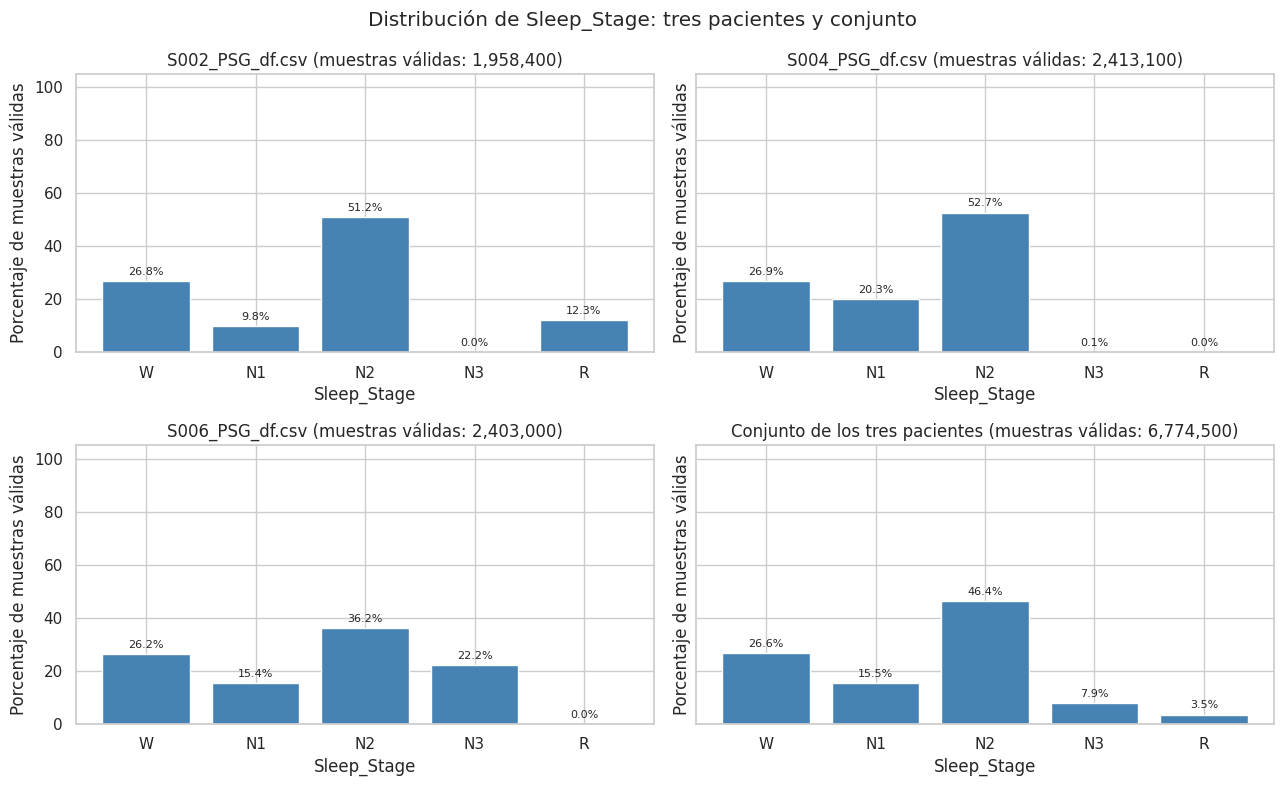

In [41]:
# Proporción de etapas válidas por paciente y en los tres registros juntos.
series_distribucion = [
    (nombre, frecuencias_etapas[nombre]) for nombre in nombres_eda
]
series_distribucion.append((
    "Conjunto de los tres pacientes",
    frecuencias_etapas.sum(axis=1),
))

fig, ejes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)
for eje, (titulo, conteos) in zip(ejes.flat, series_distribucion):
    conteos = conteos.reindex(etapas_validas, fill_value=0)
    total_validas = int(conteos.sum())
    porcentajes = (
        conteos / total_validas * 100
        if total_validas else conteos.astype(float)
    )
    barras = eje.bar(etapas_validas, porcentajes, color="steelblue")
    eje.bar_label(barras, fmt="%.1f%%", padding=3, fontsize=8)
    eje.set_title(f"{titulo} (muestras válidas: {total_validas:,})")
    eje.set_xlabel("Sleep_Stage")
    eje.set_ylabel("Porcentaje de muestras válidas")
    eje.set_ylim(0, 105)

for eje in list(ejes.flat)[len(series_distribucion):]:
    eje.axis("off")

fig.suptitle("Distribución de Sleep_Stage: tres pacientes y conjunto")
plt.tight_layout()
plt.show()


### 2.2.2. Señales frente a Sleep_Stage

Cada observación resume un epoch completo de 30 segundos con una sola etapa válida. Se muestra **una figura por señal y un panel por paciente**, con la misma escala vertical dentro de cada figura; así no se superponen cajas de personas diferentes. Los puntos atípicos se ocultan solo en estos gráficos para leer mejor el centro: la tabla inferior conserva mínimo, máximo y recuento de atípicos por paciente y etapa. No se eliminan datos.

- BVP_std: dispersión de amplitud de la señal óptica del pulso; también puede subir por movimiento o contacto del sensor. No equivale a variabilidad de frecuencia cardíaca.
- E1_std y E2_std: dispersión de los canales de movimientos oculares del PSG; la diferencia entre etapas es una hipótesis descriptiva, no una prueba de REM.
- SNORE_std: variación de la señal de ronquido; también puede reflejar ruido o escala del canal.
- TEMP_mean: temperatura media del wearable en el epoch, una señal más lenta; las diferencias entre personas o momentos de la noche pueden dominar la comparación por etapa.

La línea de cada caja es la mediana, la caja abarca el 50 % central y los bigotes llegan hasta observaciones dentro de 1,5 × IQR. No representan necesariamente el mínimo y el máximo. Las cajas son exploratorias: se requiere controlar cantidad de epochs, pacientes y calidad de señal antes de atribuirles utilidad predictiva.


S002_PSG_df.csv: 652 epochs completos con etapa válida
S004_PSG_df.csv: 804 epochs completos con etapa válida
S006_PSG_df.csv: 801 epochs completos con etapa válida


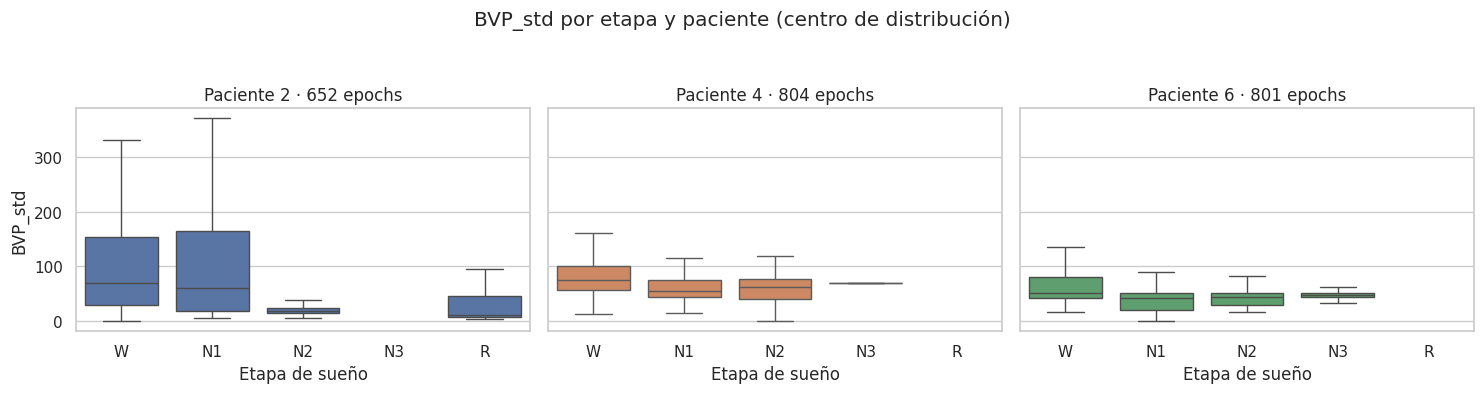

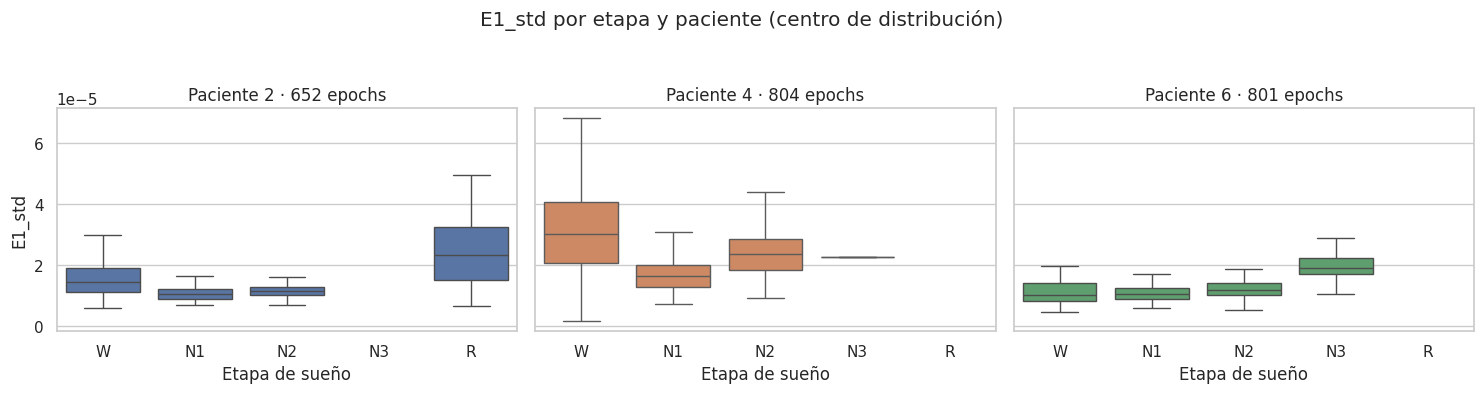

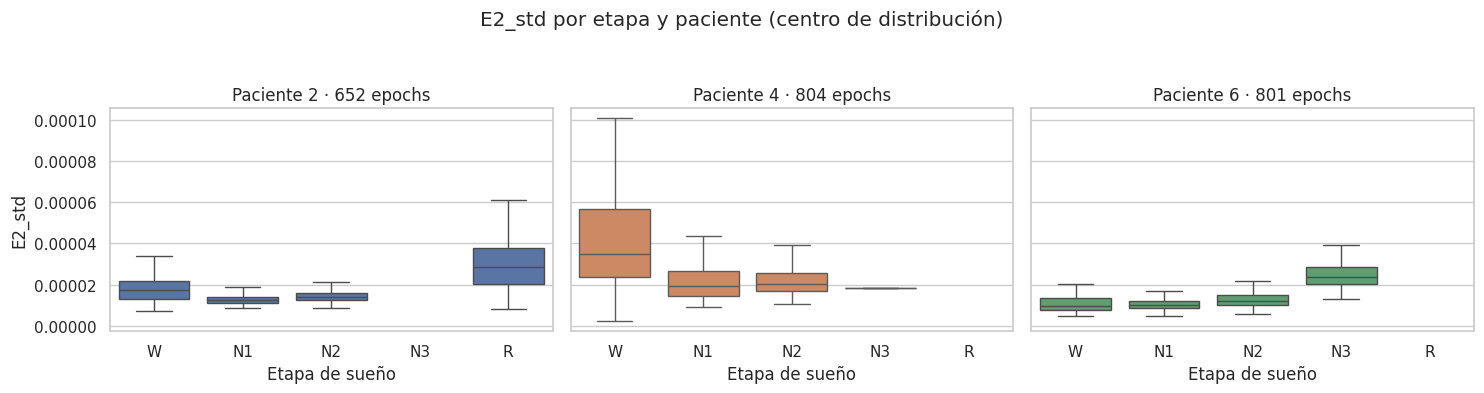

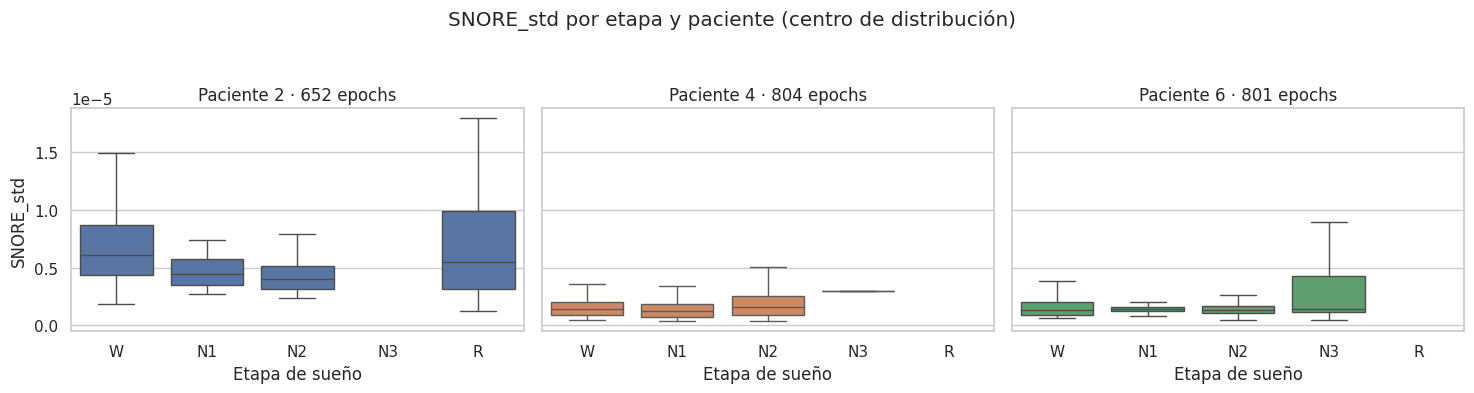

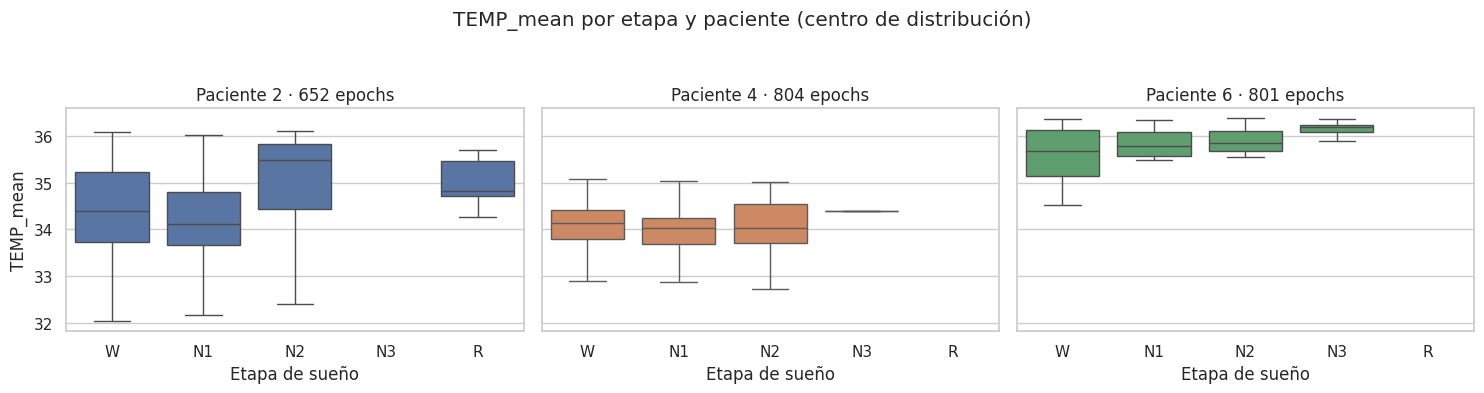

Los atípicos no aparecen como puntos en las figuras, pero permanecen en los datos y se resumen abajo por paciente y etapa.
MÍNIMOS, MÁXIMOS Y ATÍPICOS POR PACIENTE Y ETAPA


,patient_id,Sleep_Stage,caracteristica,epochs,mínimo,máximo,atípicos_IQR
0,2,N1,BVP_std,64,4.936,369.812,0
1,2,N1,E1_std,64,0.000,0.000,6
2,2,N1,E2_std,64,0.000,0.000,5
3,2,N1,SNORE_std,64,0.000,0.000,6
4,2,N1,TEMP_mean,64,32.162,36.020,0
5,2,N2,BVP_std,334,5.585,281.246,62
6,2,N2,E1_std,334,0.000,0.000,10
7,2,N2,E2_std,334,0.000,0.000,4
8,2,N2,SNORE_std,334,0.000,0.000,13
9,2,N2,TEMP_mean,334,32.077,36.105,4


In [42]:
# Resúmenes por epoch, alineados con las etiquetas del estudio.
senales_boxplot = ["BVP", "E1", "E2", "SNORE", "TEMP"]
columnas_necesarias = ["TIMESTAMP", "Sleep_Stage", *senales_boxplot]
caracteristicas_por_paciente = []

for nombre in nombres_eda:
    ruta = next(p for p in data_files if p.name == nombre)
    faltantes = set(columnas_necesarias) - set(columnas_por_archivo[nombre])
    if faltantes:
        raise ValueError(f"{nombre}: faltan columnas {sorted(faltantes)}")

    # Reutilizar la muestra cargada; leer solo siete columnas en los demás casos.
    datos = (
        df_sample_eda[columnas_necesarias]
        if ruta == sample_file
        else pd.read_csv(ruta, usecols=columnas_necesarias)
    )
    epoch_ids, completos, _ = definir_epochs(datos)
    datos_epoch = datos.loc[completos].copy()
    datos_epoch["epoch"] = epoch_ids[completos]

    grupos = datos_epoch.groupby("epoch", sort=True)
    etapas = grupos["Sleep_Stage"].first()
    puras = grupos["Sleep_Stage"].nunique(dropna=False).eq(1)
    tamano_valido = grupos.size().eq(3000)
    epochs_validos = puras & tamano_valido & etapas.isin(etapas_validas)

    resumen = pd.DataFrame({
        "Sleep_Stage": etapas.loc[epochs_validos],
    })
    for senal in senales_boxplot:
        valores = pd.to_numeric(datos_epoch[senal], errors="coerce")
        valores = valores.where(np.isfinite(valores))
        if senal == "TEMP":
            agregado = valores.groupby(datos_epoch["epoch"]).mean()
        else:
            agregado = valores.groupby(datos_epoch["epoch"]).std()
        resumen[f"{senal}_{'mean' if senal == 'TEMP' else 'std'}"] = (
            agregado.reindex(resumen.index)
        )

    resumen["patient_id"] = extract_patient_id(ruta)
    caracteristicas_por_paciente.append(resumen.reset_index())
    print(f"{nombre}: {len(resumen)} epochs completos con etapa válida")
    del datos_epoch, datos

if not caracteristicas_por_paciente:
    raise ValueError("No hay pacientes para comparar señales.")

caracteristicas_eda_22 = pd.concat(
    caracteristicas_por_paciente, ignore_index=True
)
columnas_boxplot = [
    "BVP_std", "E1_std", "E2_std", "SNORE_std", "TEMP_mean"
]

pacientes_grafico = sorted(caracteristicas_eda_22["patient_id"].unique())
colores_pacientes = sns.color_palette(n_colors=len(pacientes_grafico))

for columna in columnas_boxplot:
    fig, ejes = plt.subplots(
        1, len(pacientes_grafico),
        figsize=(5 * len(pacientes_grafico), 4),
        sharey=True, squeeze=False,
    )
    for eje, paciente, color in zip(
        ejes[0], pacientes_grafico, colores_pacientes
    ):
        datos_paciente = caracteristicas_eda_22.loc[
            caracteristicas_eda_22["patient_id"].eq(paciente)
        ]
        datos_validos = datos_paciente.loc[
            datos_paciente[columna].notna()
        ]
        if datos_validos.empty:
            eje.text(0.5, 0.5, "Sin epochs válidos",
                     ha="center", va="center", transform=eje.transAxes)
        else:
            sns.boxplot(
                data=datos_validos,
                x="Sleep_Stage", y=columna,
                order=etapas_validas, showfliers=False,
                whis=1.5, color=color, ax=eje,
            )
        eje.set_title(f"Paciente {paciente} · {len(datos_validos)} epochs")
        eje.set_xlabel("Etapa de sueño")
        eje.set_ylabel(columna if eje is ejes[0, 0] else "")

    fig.suptitle(f"{columna} por etapa y paciente (centro de distribución)")
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    plt.show()

print(
    "Los atípicos no aparecen como puntos en las figuras, pero permanecen "
    "en los datos y se resumen abajo por paciente y etapa."
)

# Mínimos y máximos reales; atípicos calculados dentro de cada paciente y etapa.
filas_extremos = []
for (paciente, etapa), grupo in caracteristicas_eda_22.groupby(
    ["patient_id", "Sleep_Stage"], observed=True
):
    for columna in columnas_boxplot:
        valores = grupo[columna].dropna()
        if valores.empty:
            continue
        q1, q3 = valores.quantile([0.25, 0.75])
        rango = q3 - q1
        atipicos = (valores.lt(q1 - 1.5 * rango)
                    | valores.gt(q3 + 1.5 * rango))
        filas_extremos.append({
            "patient_id": paciente,
            "Sleep_Stage": etapa,
            "caracteristica": columna,
            "epochs": len(valores),
            "mínimo": valores.min(),
            "máximo": valores.max(),
            "atípicos_IQR": int(atipicos.sum()),
        })

resumen_extremos_22 = pd.DataFrame(filas_extremos)
print("MÍNIMOS, MÁXIMOS Y ATÍPICOS POR PACIENTE Y ETAPA")
display(resumen_extremos_22.round(3))


## 2.3 Auditoría de Valores Nulos

In [43]:
# 2.3. Auditoría de faltantes y valores numéricos inválidos

# Columnas originales, excluyendo tiempo, objetivo y anotaciones.
columnas_excluidas = {
    "TIMESTAMP",
    "Sleep_Stage",
    "Obstructive_Apnea",
    "Central_Apnea",
    "Hypopnea",
    "Multiple_Events",
}

resultados_calidad = []
resumen_calidad = []

for nombre in nombres_eda:
    ruta = next(p for p in data_files if p.name == nombre)
    print(f"Auditando señales: {nombre}")

    columnas_csv = pd.read_csv(ruta, nrows=0).columns.tolist()
    señales = [
        col for col in columnas_csv
        if col not in columnas_excluidas
    ]

    conteos = {
        col: {"nulos": 0, "infinitos": 0, "no_numericos": 0}
        for col in señales
    }
    filas = 0

    # Reutilizar el paciente muestra ya cargado.
    if ruta == sample_file:
        bloques = [df_sample_eda[señales]]
    else:
        bloques = pd.read_csv(
            ruta,
            usecols=señales,
            chunksize=200_000,
            low_memory=False,
        )

    for bloque in bloques:
        filas += len(bloque)

        for col in señales:
            original = bloque[col]
            numerico = pd.to_numeric(original, errors="coerce")

            conteos[col]["nulos"] += int(original.isna().sum())

            # Valores presentes que no pueden convertirse a números.
            conteos[col]["no_numericos"] += int(
                (original.notna() & numerico.isna()).sum()
            )

            conteos[col]["infinitos"] += int(
                numerico.isin([np.inf, -np.inf]).sum()
            )

    for col, conteo in conteos.items():
        resultados_calidad.append({
            "archivo": nombre,
            "señal": col,
            "muestras": filas,
            **conteo,
            "nulos_pct": (
                100 * conteo["nulos"] / filas if filas else np.nan
            ),
        })

    resumen_calidad.append({
        "archivo": nombre,
        "muestras": filas,
        "señales_revisadas": len(señales),
        # Son celdas afectadas; no filas distintas.
        "celdas_nulas": sum(c["nulos"] for c in conteos.values()),
        "celdas_infinitas": sum(
            c["infinitos"] for c in conteos.values()
        ),
        "celdas_no_numericas": sum(
            c["no_numericos"] for c in conteos.values()
        ),
    })

auditoria_señales = pd.DataFrame(resultados_calidad)
resumen_calidad = pd.DataFrame(resumen_calidad)

print("\nRESUMEN DE CALIDAD POR PACIENTE")
display(resumen_calidad)

problemas_calidad = auditoria_señales.loc[
    auditoria_señales[
        ["nulos", "infinitos", "no_numericos"]
    ].sum(axis=1) > 0
]

print("\nSEÑALES CON FALTANTES O VALORES INVÁLIDOS")

if problemas_calidad.empty:
    print(
        "No se encontraron nulos, infinitos ni valores "
        "no numéricos en las señales revisadas."
    )
else:
    display(problemas_calidad.round({"nulos_pct": 4}))

print(
    "\nNo se modificaron valores. "
    "Esta auditoría no detecta extremos, señales congeladas "
    "ni todos los posibles artefactos."
)

Auditando señales: S002_PSG_df.csv
Auditando señales: S004_PSG_df.csv
Auditando señales: S006_PSG_df.csv

RESUMEN DE CALIDAD POR PACIENTE


,archivo,muestras,señales_revisadas,celdas_nulas,celdas_infinitas,celdas_no_numericas
0,S002_PSG_df.csv,1958400,26,0,0,0
1,S004_PSG_df.csv,2413100,26,0,0,0
2,S006_PSG_df.csv,2403000,26,0,0,0



SEÑALES CON FALTANTES O VALORES INVÁLIDOS
No se encontraron nulos, infinitos ni valores no numéricos en las señales revisadas.

No se modificaron valores. Esta auditoría no detecta extremos, señales congeladas ni todos los posibles artefactos.


### 2.3.1. Distribución e inspección de extremos

Se calculan estadísticas descriptivas de HR, TEMP, EDA y SAO2 y se grafica su evolución hasta 30 segundos antes y después de sus mínimos y máximos.

El objetivo es identificar valores que requieran revisión antes de definir reglas de limpieza. Un extremo no implica necesariamente un error.

Este análisis utiliza únicamente el paciente muestra y no modifica los datos. Cada gráfico puede corresponder a un momento distinto y tiene su propia escala vertical.

Paciente revisado: 2

DISTRIBUCIÓN DE LAS SEÑALES


,count,mean,std,min,1%,25%,50%,75%,99%,max
HR,1958400.0,67.190774,7.728017,54.520000,57.920000,62.920000,65.180000,68.720000,101.520000,132.480000
TEMP,1958400.0,34.786420,0.971332,32.000000,32.150000,34.090000,34.840000,35.660000,36.070000,36.150000
EDA,1958400.0,0.231192,0.267470,0.036129,0.051498,0.109197,0.139606,0.167784,1.360635,1.698764
SAO2,1958400.0,0.911538,0.028327,0.808540,0.839901,0.889745,0.919749,0.929654,0.959701,0.971339


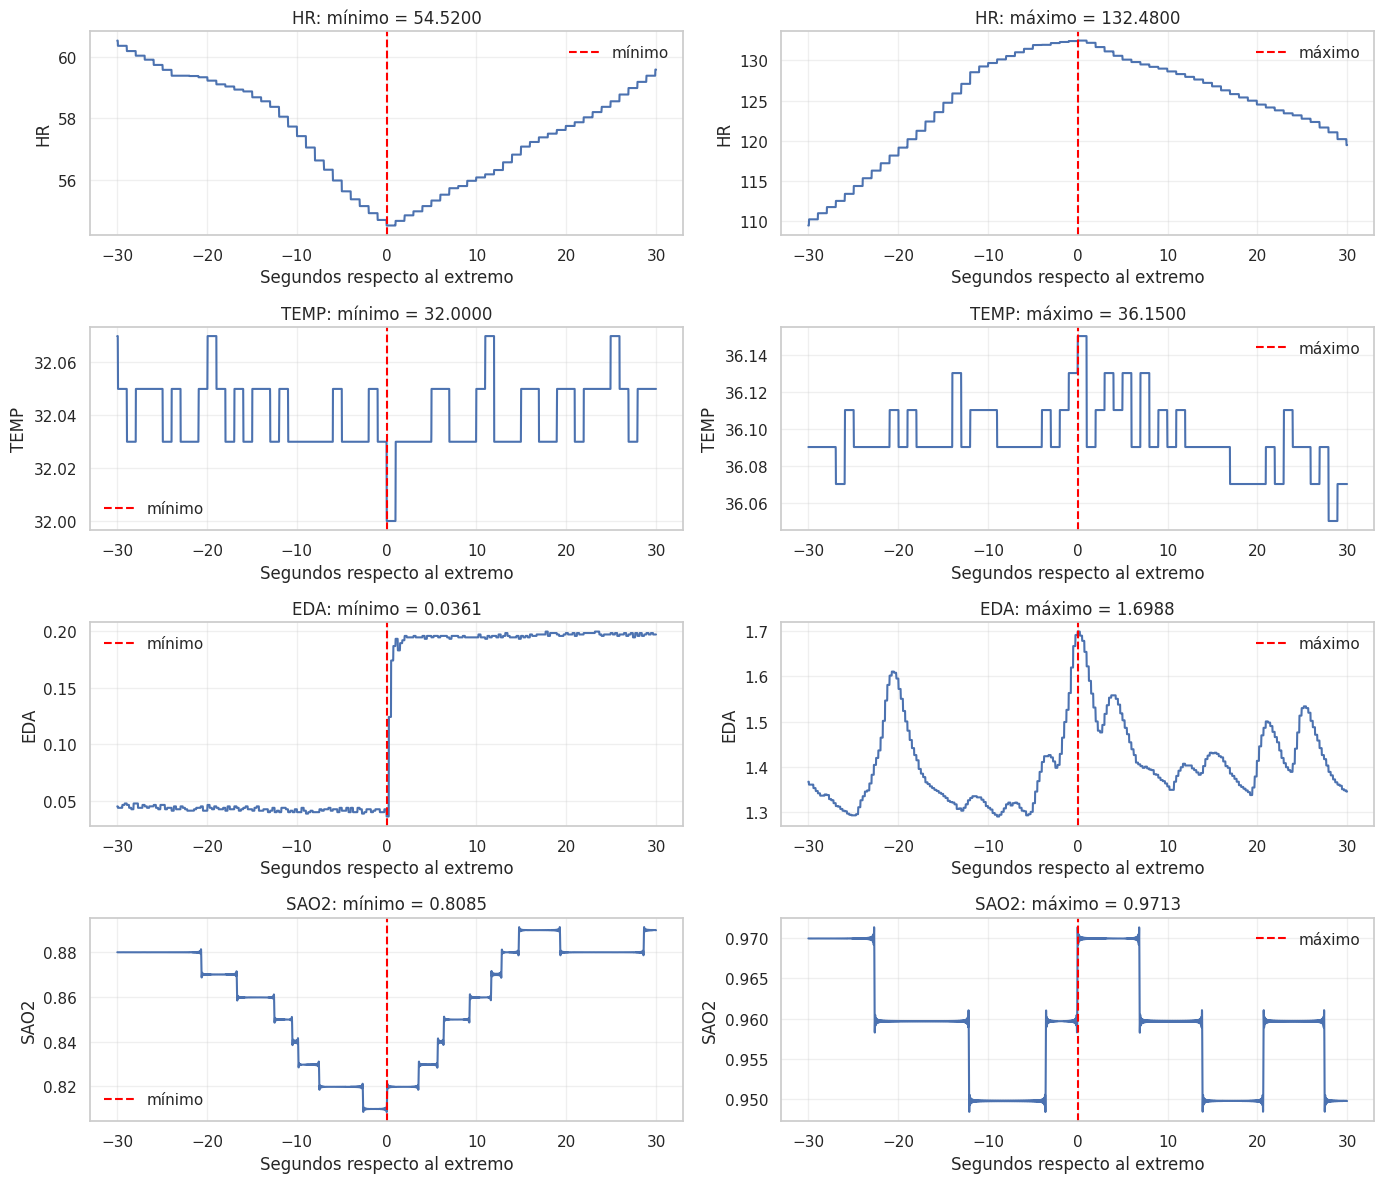


Los extremos y percentiles son descriptivos. No determinan automáticamente qué valores son errores. Cada gráfico tiene su propia escala vertical.


In [44]:
# 2.3.1. Distribución e inspección temporal de extremos

columnas_revision = ["HR", "TEMP", "EDA", "SAO2"]

# Serie numérica auxiliar; los datos originales se conservan.
valores_revision = (
    df_sample_eda[columnas_revision]
    .apply(pd.to_numeric, errors="coerce")
)

print("Paciente revisado:", extract_patient_id(sample_file))

print("\nDISTRIBUCIÓN DE LAS SEÑALES")
display(
    valores_revision
    .describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99])
    .T
)

# Inspeccionar el mínimo y el máximo de cada señal.
# Cada gráfico puede corresponder a un momento distinto.
fig, axes = plt.subplots(
    len(columnas_revision), 2,
    figsize=(14, 3 * len(columnas_revision)),
    squeeze=False,
)

timestamps = pd.to_numeric(
    df_sample_eda["TIMESTAMP"], errors="coerce"
).reset_index(drop=True)

for fila, columna in enumerate(columnas_revision):
    valores = valores_revision[columna].reset_index(drop=True)
    finitos = valores.where(np.isfinite(valores))

    for j, extremo in enumerate(["mínimo", "máximo"]):
        ax = axes[fila, j]

        if finitos.notna().sum() == 0:
            ax.set_title(f"{columna}: sin valores finitos")
            ax.axis("off")
            continue

        # Si el extremo se repite, seleccionar su primera aparición.
        posicion = (
            finitos.idxmin()
            if extremo == "mínimo"
            else finitos.idxmax()
        )

        # Hasta 30 segundos antes y después, a 100 Hz.
        inicio = max(0, posicion - 3000)
        fin = min(len(valores), posicion + 3001)

        tiempo_relativo = (
            timestamps.iloc[inicio:fin] - timestamps.iloc[posicion]
        )

        ax.plot(
            tiempo_relativo,
            valores.iloc[inicio:fin].to_numpy(),
        )
        ax.axvline(
            0, color="red", linestyle="--", label=extremo
        )

        ax.set_title(
            f"{columna}: {extremo} = {valores.iloc[posicion]:.4f}"
        )
        ax.set_xlabel("Segundos respecto al extremo")
        ax.set_ylabel(columna)
        ax.grid(alpha=0.3)
        ax.legend()

plt.tight_layout()
plt.show()

print(
    "\nLos extremos y percentiles son descriptivos. "
    "No determinan automáticamente qué valores son errores. "
    "Cada gráfico tiene su propia escala vertical."
)

## 2.4 Preparación de epochs alineados del paciente muestra

In [45]:
# 2.4. Preparación de epochs alineados del paciente muestra

# Trabajar sobre una copia; conservar el registro original.
temp_df = df_sample_eda.reset_index(drop=True).copy()

# Validar continuidad e inferir alineación.
epoch_ids, completos, auditoria_muestra = definir_epochs(temp_df)

temp_df["epoch"] = epoch_ids

# Seleccionar únicamente ventanas completas de 3000 muestras.
temp_df = temp_df.loc[completos].copy()

# Verificar el tamaño de todas las ventanas seleccionadas.
muestras_por_epoch = temp_df.groupby("epoch").size()

if not muestras_por_epoch.eq(3000).all():
    raise ValueError("Hay epochs que no contienen 3000 muestras.")

# Comprobar que todas las filas originales estén contabilizadas.
filas_contabilizadas = (
    auditoria_muestra["filas_fragmento_inicial"]
    + auditoria_muestra["epochs_completos"] * 3000
    + auditoria_muestra["filas_fragmento_final"]
)

if filas_contabilizadas != len(df_sample_eda):
    raise ValueError("La auditoría no contabiliza todas las filas.")

print("Paciente:", extract_patient_id(sample_file))
print("\nAUDITORÍA TEMPORAL")
display(pd.DataFrame([auditoria_muestra]))

print("Filas seleccionadas:", len(temp_df))
print("Muestras por epoch: 3000")
print("Duración por epoch: 30 segundos")
print("Registro original conservado:", len(df_sample_eda), "filas")

# Preparar estadísticas exploratorias para la sección 2.5.
# En esta sección todavía no se calculan.
sensores_cols = ["HR", "TEMP", "EDA", "BVP", "SAO2"]

agg_dict = {
    col: ("std" if col == "BVP" else "mean")
    for col in sensores_cols
    if col in temp_df.columns
}

Paciente: 2

AUDITORÍA TEMPORAL


,filas_originales,desplazamiento,epochs_completos,filas_fragmento_inicial,filas_fragmento_final
0,1958400,2400,652,2400,0


Filas seleccionadas: 1956000
Muestras por epoch: 3000
Duración por epoch: 30 segundos
Registro original conservado: 1958400 filas


## 2.5 Variación y Evolución del Estado del Sueño a través de los Epochs

El hipnograma relaciona **tiempo desde el inicio del CSV** (eje horizontal) y **etapa anotada** (eje vertical) del paciente muestra. Cada bloque ocupa un epoch completo de 30 segundos. Los epochs con etiquetas mezcladas, faltantes o inválidas se muestran en «Revisar»; no se les asigna automáticamente la etapa más frecuente. La separación entre bloques no demuestra una transición fisiológica instantánea: representa la resolución de las anotaciones. La matriz anterior cuenta cambios entre epochs consecutivos y puros.

Orden visual solicitado, de arriba hacia abajo: W, N1, N2, N3 y R. REM se ubica al final para facilitar la lectura, pero **no es un nivel de profundidad mayor que N3**; las etapas son categorías.


Paciente: 2
Epochs completos: 652
Epochs puros: 652
Epochs con varias etapas válidas: 0
Epochs con empate de moda: 0
Pureza mínima: 1.0

EPOCHS PARA REVISIÓN
Todas las ventanas contienen una única etapa válida.

TRANSICIONES ENTRE EPOCHS CONSECUTIVOS Y PUROS


Etapa actual,W,N1,N2,N3,R
Etapa anterior,,,,,
W,102,31,26,0,14
N1,26,14,23,0,1
N2,29,19,284,0,2
N3,0,0,0,0,0
R,17,0,0,0,63


Pares contabilizados: 651


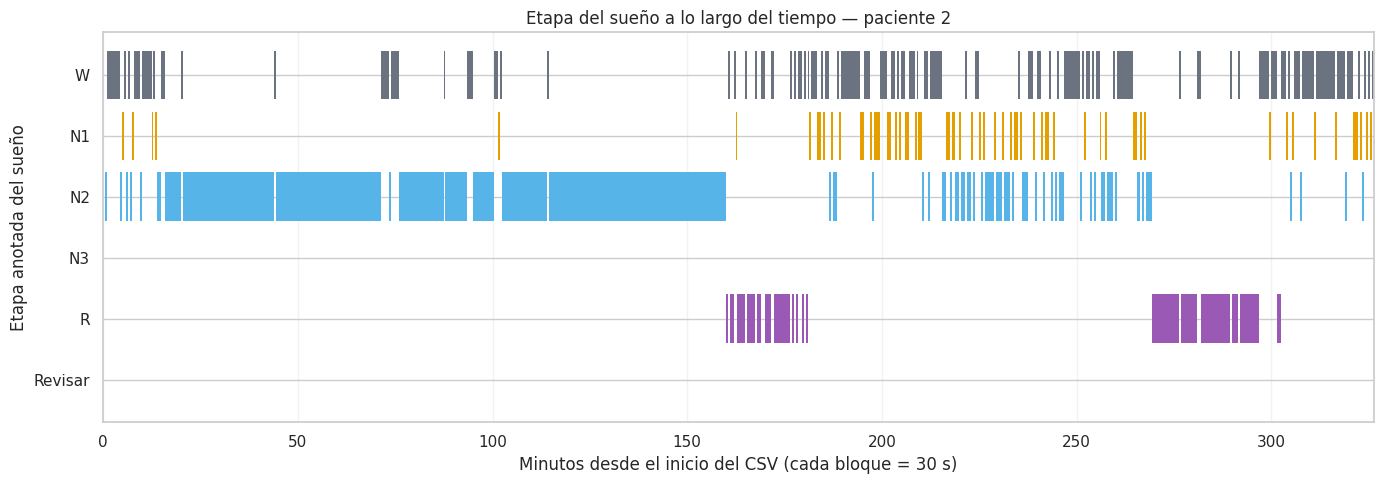

In [46]:
# 2.5. Evolución y transiciones del sueño

etapas_validas = ["W", "N1", "N2", "N3", "R"]


def process_epoch(group):
    res = {}

    res["tiempo_min"] = (
        group["TIMESTAMP"].iloc[0]
        - df_sample_eda["TIMESTAMP"].iloc[0]
    ) / 60

    etapas = group["Sleep_Stage"]
    etiquetas = etapas.where(etapas.isin(etapas_validas))
    modas = etiquetas.mode()

    res["stage_inicio"] = etapas.iloc[0]
    res["stage_fin"] = etapas.iloc[-1]

    # No elegir arbitrariamente una etapa cuando hay empate.
    res["empate_moda"] = len(modas) > 1
    res["stage_moda"] = (
        modas.iloc[0] if len(modas) == 1 else np.nan
    )

    res["etiquetas_nulas"] = int(etapas.isna().sum())
    res["etiquetas_invalidas"] = int(
        (etapas.notna() & ~etapas.isin(etapas_validas)).sum()
    )

    res["hubo_transicion_interna"] = (
        etiquetas.nunique(dropna=True) > 1
    )

    conteos = etiquetas.value_counts()
    res["porcentaje_pureza"] = (
        conteos.max() / len(group) if not conteos.empty else 0.0
    )

    # Estadísticas exploratorias configuradas en 2.4.
    for col, operacion in agg_dict.items():
        if operacion == "mean":
            res[f"{col}_mean"] = group[col].mean()
        elif operacion == "std":
            res[f"{col}_std"] = group[col].std()

    return pd.Series(res)


# Resumir cada ventana completa.
# La iteración explícita conserva la columna epoch en el grupo.
resultados = []

for epoch_id, group in temp_df.groupby("epoch", sort=True):
    resultado = process_epoch(group)
    resultado["epoch"] = epoch_id
    resultados.append(resultado)

df_sample_epochs = (
    pd.DataFrame(resultados)
    .sort_values("epoch")
    .reset_index(drop=True)
)

# Un epoch puro debe tener todas sus muestras en una etapa válida.
mascara_puros = df_sample_epochs["porcentaje_pureza"].eq(1.0)

print("Paciente:", extract_patient_id(sample_file))
print("Epochs completos:", len(df_sample_epochs))
print("Epochs puros:", int(mascara_puros.sum()))
print(
    "Epochs con varias etapas válidas:",
    int(df_sample_epochs["hubo_transicion_interna"].sum()),
)
print(
    "Epochs con empate de moda:",
    int(df_sample_epochs["empate_moda"].sum()),
)
print(
    "Pureza mínima:",
    df_sample_epochs["porcentaje_pureza"].min(),
)

# Mostrar cualquier ventana que necesite revisión.
epochs_revision = df_sample_epochs.loc[
    ~mascara_puros,
    [
        "epoch", "tiempo_min", "stage_inicio", "stage_fin",
        "stage_moda", "porcentaje_pureza", "empate_moda",
        "etiquetas_nulas", "etiquetas_invalidas",
    ],
]

print("\nEPOCHS PARA REVISIÓN")
if epochs_revision.empty:
    print("Todas las ventanas contienen una única etapa válida.")
else:
    display(epochs_revision)

# Relacionar cada epoch con el anterior, sin saltar ventanas.
df_sample_epochs["stage_moda_prev"] = (
    df_sample_epochs["stage_moda"].shift(1)
)

consecutivos = df_sample_epochs["epoch"].diff().eq(1)

# Usar únicamente pares de epochs consecutivos y puros.
pares_validos = (
    consecutivos
    & mascara_puros
    & mascara_puros.shift(1, fill_value=False)
)

transition_matrix = pd.crosstab(
    df_sample_epochs.loc[pares_validos, "stage_moda_prev"],
    df_sample_epochs.loc[pares_validos, "stage_moda"],
    rownames=["Etapa anterior"],
    colnames=["Etapa actual"],
).reindex(
    index=etapas_validas,
    columns=etapas_validas,
    fill_value=0,
)

print("\nTRANSICIONES ENTRE EPOCHS CONSECUTIVOS Y PUROS")
display(transition_matrix)
print("Pares contabilizados:", int(pares_validos.sum()))

# Cada rectángulo representa el intervalo completo de un epoch (0,5 min).
stage_mapping = {"W": 4, "N1": 3, "N2": 2, "N3": 1, "R": 0}
colores_etapas = {
    "W": "#6b7280", "R": "#9b59b6", "N1": "#e69f00",
    "N2": "#56b4e9", "N3": "#0072b2",
}
duracion_epoch_min = 0.5
validos_grafico = (
    mascara_puros & df_sample_epochs["stage_moda"].isin(etapas_validas)
)

fig, ax = plt.subplots(figsize=(14, 5))
for etapa, nivel in stage_mapping.items():
    seleccion = validos_grafico & df_sample_epochs["stage_moda"].eq(etapa)
    ax.barh(
        nivel, duracion_epoch_min,
        left=df_sample_epochs.loc[seleccion, "tiempo_min"],
        height=0.8, color=colores_etapas[etapa], linewidth=0,
    )

# Mostrar ventanas no puras sin convertir la moda en una etiqueta definitiva.
revisables = ~validos_grafico
if revisables.any():
    ax.barh(
        -1, duracion_epoch_min,
        left=df_sample_epochs.loc[revisables, "tiempo_min"],
        height=0.8, color="#bdbdbd", linewidth=0,
    )

ax.set_yticks(
    [-1, 0, 1, 2, 3, 4],
    labels=["Revisar", "R", "N3", "N2", "N1", "W"],
)
ax.set_xlim(
    0, df_sample_epochs["tiempo_min"].max() + duracion_epoch_min
)
ax.set_ylim(-1.7, 4.7)
ax.set_xlabel("Minutos desde el inicio del CSV (cada bloque = 30 s)")
ax.set_ylabel("Etapa anotada del sueño")
ax.set_title(
    f"Etapa del sueño a lo largo del tiempo — paciente "
    f"{extract_patient_id(sample_file)}"
)
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# 2.6. Auditoría general de los pacientes disponibles

Se revisan todos los registros para detectar diferencias de estructura, problemas temporales, etiquetas inválidas y valores faltantes o no numéricos en las señales.

También se registran rangos, ceros en SAO2 y tramos exactamente constantes. Estos casos requieren interpretación: no se consideran errores automáticamente.

Los archivos se procesan por bloques y los resultados se guardan en CSV. En ejecuciones posteriores se reutilizan si coinciden las fuentes, los parámetros y la versión de las reglas; para repetir la lectura completa, activar `FORZAR_RECALCULO_AUDITORIA`. No se modifican los datos originales.

In [47]:
# 2.6. Auditoría general por bloques

TAMANO_BLOQUE = 200_000

# Criterio exploratorio para listar tramos constantes.
# No es un umbral de limpieza ni demuestra un fallo del sensor.
SEGUNDOS_CONSTANTES_REVISION = 30

archivos_auditar = list(data_files)

if not archivos_auditar:
    raise ValueError("No hay archivos para auditar.")

nombres = [p.name for p in archivos_auditar]
if len(nombres) != len(set(nombres)):
    raise ValueError(
        "Hay nombres de archivo duplicados. Revisar data_files."
    )

print("Archivos encontrados:", len(archivos_auditar))

# S002 se utiliza únicamente como referencia de columnas.
referencia = next(
    (p for p in archivos_auditar if p.name == "S002_PSG_df.csv"),
    archivos_auditar[0],
)
columnas_referencia = pd.read_csv(referencia, nrows=0).columns.tolist()

excluidas = {
    "TIMESTAMP", "Sleep_Stage", "patient_id",
    "Obstructive_Apnea", "Central_Apnea",
    "Hypopnea", "Multiple_Events",
}
senales_referencia = [
    c for c in columnas_referencia if c not in excluidas
]
etapas_validas = ["W", "N1", "N2", "N3", "R"]

# Evitar releer todos los CSV de 100 Hz si la auditoría sigue vigente.
FORZAR_RECALCULO_AUDITORIA = False
AUDITORIA_CACHE_VERSION = 1  # Incrementar si cambia la lógica de auditoría.
carpeta_salida = Path("/kaggle/working/auditoria")
rutas_auditoria = {
    "pacientes": carpeta_salida / "auditoria_pacientes.csv",
    "senales": carpeta_salida / "auditoria_senales.csv",
    "casos": carpeta_salida / "casos_revision.csv",
}
ruta_manifiesto_auditoria = carpeta_salida / "manifest_auditoria_v1.json"
firma_auditoria = {
    "version": AUDITORIA_CACHE_VERSION,
    "tamano_bloque": TAMANO_BLOQUE,
    "segundos_constantes_revision": SEGUNDOS_CONSTANTES_REVISION,
    "columnas_referencia": columnas_referencia,
    "senales_referencia": senales_referencia,
    "etapas_validas": etapas_validas,
    "fuentes": [
        {
            "archivo": ruta.name, "ruta": str(ruta.resolve()),
            "bytes": ruta.stat().st_size,
            "mtime_ns": ruta.stat().st_mtime_ns,
        }
        for ruta in sorted(archivos_auditar, key=lambda p: p.name)
    ],
}
cache_auditoria_valida = False
if (not FORZAR_RECALCULO_AUDITORIA
        and ruta_manifiesto_auditoria.exists()
        and all(ruta.exists() for ruta in rutas_auditoria.values())):
    try:
        with ruta_manifiesto_auditoria.open(encoding="utf-8") as archivo:
            manifiesto_auditoria = json.load(archivo)
        if manifiesto_auditoria.get("firma") != firma_auditoria:
            raise ValueError("Las fuentes o reglas de auditoría cambiaron")
        pacientes_cache = pd.read_csv(rutas_auditoria["pacientes"], low_memory=False)
        senales_cache = pd.read_csv(rutas_auditoria["senales"], low_memory=False)
        casos_cache = pd.read_csv(rutas_auditoria["casos"], low_memory=False)
        if manifiesto_auditoria.get("filas") != {
            "pacientes": len(pacientes_cache),
            "senales": len(senales_cache),
            "casos": len(casos_cache),
        }:
            raise ValueError("Las tablas no coinciden con el manifiesto")
        if (len(pacientes_cache) != len(archivos_auditar)
            or pacientes_cache["archivo"].duplicated().any()
            or set(pacientes_cache["archivo"]) != set(nombres)
            or not pacientes_cache["estado_lectura"].eq("Completa").all()):
            raise ValueError("La auditoría de pacientes está incompleta")
        if not {"archivo", "señal", "nulos", "no_numericos", "infinitos"}.issubset(senales_cache.columns):
            raise ValueError("Faltan columnas en la auditoría de señales")
        if not {"archivo", "señal", "motivo"}.issubset(casos_cache.columns):
            raise ValueError("Faltan columnas en los casos de revisión")
        if (not set(senales_cache["archivo"]).issubset(nombres)
            or not set(casos_cache["archivo"]).issubset(nombres)):
            raise ValueError("Las tablas contienen archivos ajenos a las fuentes")
        for nombre_tabla, tabla in [
            ("pacientes", pacientes_cache), ("senales", senales_cache), ("casos", casos_cache)
        ]:
            registrar_csv_validado(tabla, rutas_auditoria[nombre_tabla])
        cache_auditoria_valida = True
        print("Auditoría cargada desde CSV existente:", carpeta_salida)
    except (OSError, ValueError, KeyError, pd.errors.ParserError) as error:
        print(f"Caché de auditoría no utilizable ({error}); se recalculará.")

if not cache_auditoria_valida:
    carpeta_salida.mkdir(parents=True, exist_ok=True)
    ruta_manifiesto_auditoria.unlink(missing_ok=True)
    print("Se auditarán los CSV originales por bloques.")


def nuevo_tramo():
    return {
        "cola": 0,
        "mayor": 0,
        "inicio": None,
    }


def actualizar_tramo(mascara, estado, fila_inicio):
    """Mayor tramo True, incluyendo continuidad entre bloques."""
    mascara = np.asarray(mascara, dtype=bool)

    if len(mascara) == 0:
        return

    cambios = np.diff(
        np.r_[False, mascara, False].astype(np.int8)
    )
    inicios = np.flatnonzero(cambios == 1)
    finales = np.flatnonzero(cambios == -1)

    if len(inicios) == 0:
        estado["cola"] = 0
        return

    largos = finales - inicios
    posiciones = fila_inicio + inicios

    if inicios[0] == 0:
        largos[0] += estado["cola"]
        posiciones[0] -= estado["cola"]

    mayor = int(np.argmax(largos))

    if largos[mayor] > estado["mayor"]:
        estado["mayor"] = int(largos[mayor])
        estado["inicio"] = int(posiciones[mayor])

    estado["cola"] = (
        int(largos[-1]) if mascara[-1] else 0
    )


resultados_pacientes = []
resultados_senales = []
casos_revision = []

for numero, ruta in enumerate(archivos_auditar if not cache_auditoria_valida else [], start=1):
    print(
        f"[{numero}/{len(archivos_auditar)}] {ruta.name}",
        flush=True,
    )

    try:
        columnas = pd.read_csv(ruta, nrows=0).columns.tolist()
        columnas_faltantes = sorted(
            set(columnas_referencia) - set(columnas)
        )
        columnas_adicionales = sorted(
            set(columnas) - set(columnas_referencia)
        )

        requeridas = {"TIMESTAMP", "Sleep_Stage"}
        if not requeridas.issubset(columnas):
            raise ValueError("Falta TIMESTAMP o Sleep_Stage.")

        senales = [
            c for c in senales_referencia if c in columnas
        ]

        controles = {
            c: {
                "nulos": 0,
                "no_numericos": 0,
                "infinitos": 0,
                "minimo": np.inf,
                "maximo": -np.inf,
                "tipos": set(),
                "anterior": np.nan,
                "constante": nuevo_tramo(),
            }
            for c in senales
        }

        filas = 0
        timestamp_anterior = None
        etapa_anterior = None
        timestamp_inicio = None
        timestamp_final = None

        timestamps_invalidos = 0
        intervalos_irregulares = 0
        intervalos_no_crecientes = 0

        etiquetas_nulas = 0
        etiquetas_invalidas = 0
        valores_invalidos = set()
        conteos_etapas = {e: 0 for e in etapas_validas}

        restos = set()
        cambios_etapa = 0
        ceros_sao2 = 0
        sao2_fuera_0_1 = 0
        tramo_ceros = nuevo_tramo()

        columnas_leer = ["TIMESTAMP", "Sleep_Stage"] + senales

        with pd.read_csv(
            ruta,
            usecols=columnas_leer,
            chunksize=TAMANO_BLOQUE,
            low_memory=False,
        ) as lector:

            for bloque in lector:
                fila_inicio = filas
                cantidad = len(bloque)

                # 1. Tiempo: incluir el límite entre bloques.
                t = pd.to_numeric(
                    bloque["TIMESTAMP"], errors="coerce"
                ).to_numpy(dtype=float)

                if timestamp_inicio is None:
                    timestamp_inicio = t[0]
                timestamp_final = t[-1]

                timestamps_invalidos += int(
                    (~np.isfinite(t)).sum()
                )

                tiempos_comparar = (
                    np.r_[timestamp_anterior, t]
                    if timestamp_anterior is not None
                    else t
                )

                diferencias = np.diff(tiempos_comparar)
                pares_finitos = (
                    np.isfinite(tiempos_comparar[:-1])
                    & np.isfinite(tiempos_comparar[1:])
                )

                intervalos_irregulares += int(
                    (
                        pares_finitos
                        & ~np.isclose(
                            diferencias, 0.01,
                            atol=1e-6, rtol=0,
                        )
                    ).sum()
                )
                intervalos_no_crecientes += int(
                    (pares_finitos & (diferencias <= 0)).sum()
                )
                timestamp_anterior = t[-1]

                # 2. Etiquetas y alineación.
                etapas = bloque["Sleep_Stage"].reset_index(drop=True)
                anteriores = etapas.shift()
                if fila_inicio > 0:
                    anteriores.iloc[0] = etapa_anterior

                invalidas = (
                    etapas.notna()
                    & ~etapas.isin(etapas_validas)
                )

                etiquetas_nulas += int(etapas.isna().sum())
                etiquetas_invalidas += int(invalidas.sum())
                valores_invalidos.update(
                    etapas.loc[invalidas].astype(str).unique()
                )

                conteos = etapas.value_counts()
                for etapa in etapas_validas:
                    conteos_etapas[etapa] += int(
                        conteos.get(etapa, 0)
                    )

                cambios = (
                    etapas.isin(etapas_validas)
                    & anteriores.isin(etapas_validas)
                    & etapas.ne(anteriores)
                )

                posiciones = (
                    np.flatnonzero(cambios.to_numpy())
                    + fila_inicio
                )

                cambios_etapa += len(posiciones)
                restos.update((posiciones % 3000).tolist())
                etapa_anterior = etapas.iloc[-1]

                # 3. Calidad y rangos de cada señal.
                for col in senales:
                    control = controles[col]
                    original = bloque[col]
                    control["tipos"].add(str(original.dtype))

                    numerico = pd.to_numeric(
                        original, errors="coerce"
                    )
                    valores = numerico.to_numpy(dtype=float)
                    finitos = np.isfinite(valores)

                    control["nulos"] += int(original.isna().sum())
                    control["no_numericos"] += int(
                        (original.notna() & numerico.isna()).sum()
                    )
                    control["infinitos"] += int(
                        np.isinf(valores).sum()
                    )

                    if finitos.any():
                        control["minimo"] = min(
                            control["minimo"],
                            float(valores[finitos].min()),
                        )
                        control["maximo"] = max(
                            control["maximo"],
                            float(valores[finitos].max()),
                        )

                    # Igualdad exacta con la muestra anterior.
                    anteriores_valores = np.r_[
                        control["anterior"], valores[:-1]
                    ]
                    iguales = (
                        finitos
                        & np.isfinite(anteriores_valores)
                        & (valores == anteriores_valores)
                    )

                    actualizar_tramo(
                        iguales, control["constante"], fila_inicio
                    )
                    control["anterior"] = valores[-1]

                    if col == "SAO2":
                        ceros = finitos & (valores == 0)
                        ceros_sao2 += int(ceros.sum())

                        sao2_fuera_0_1 += int(
                            (
                                finitos
                                & ((valores < 0) | (valores > 1))
                            ).sum()
                        )

                        actualizar_tramo(
                            ceros, tramo_ceros, fila_inicio
                        )

                filas += cantidad

        # 4. Determinar si puede inferirse una alineación.
        continuo = (
            timestamps_invalidos == 0
            and intervalos_irregulares == 0
            and filas > 0
        )

        desplazamiento = np.nan
        epochs_completos = np.nan
        fragmento_inicial = np.nan
        fragmento_final = np.nan

        if not continuo:
            estado_alineacion = "Revisar tiempo"
        elif len(restos) == 0:
            estado_alineacion = "Sin cambios: no determinada"
        elif len(restos) > 1:
            estado_alineacion = "Desplazamientos inconsistentes"
        else:
            estado_alineacion = "Alineación candidata consistente"
            desplazamiento = int(next(iter(restos)))
            epochs_completos = (filas - desplazamiento) // 3000
            fragmento_inicial = desplazamiento
            fragmento_final = (filas - desplazamiento) % 3000

        resultados_pacientes.append({
            "archivo": ruta.name,
            "patient_id": extract_patient_id(ruta),
            "estado_lectura": "Completa",
            "filas": filas,
            "columnas_csv": len(columnas),
            "columnas_faltantes": columnas_faltantes,
            "columnas_adicionales": columnas_adicionales,
            "timestamp_inicio": timestamp_inicio,
            "timestamp_final": timestamp_final,
            "timestamps_invalidos": timestamps_invalidos,
            "intervalos_irregulares": intervalos_irregulares,
            "intervalos_no_crecientes": intervalos_no_crecientes,
            "etiquetas_nulas": etiquetas_nulas,
            "etiquetas_invalidas": etiquetas_invalidas,
            "valores_invalidos": sorted(valores_invalidos),
            "cambios_etapa": cambios_etapa,
            "restos_3000": sorted(restos),
            "estado_alineacion": estado_alineacion,
            "desplazamiento": desplazamiento,
            "epochs_completos": epochs_completos,
            "fragmento_inicial": fragmento_inicial,
            "fragmento_final": fragmento_final,
            "ceros_sao2": ceros_sao2,
            # Revisar escala antes de considerar estos valores errores.
            "sao2_fuera_escala_0_1": sao2_fuera_0_1,
            **{f"muestras_{e}": conteos_etapas[e]
               for e in etapas_validas},
        })

        for col, control in controles.items():
            tramo = control["constante"]

            # N igualdades consecutivas representan N+1 muestras.
            muestras_constantes = (
                tramo["mayor"] + 1 if tramo["mayor"] else 0
            )
            inicio_constante = (
                tramo["inicio"] - 1
                if tramo["mayor"] else None
            )
            duracion_constante = (
                tramo["mayor"] / 100
            )

            resultados_senales.append({
                "archivo": ruta.name,
                "señal": col,
                "filas": filas,
                "tipos_observados": " / ".join(
                    sorted(control["tipos"])
                ),
                "nulos": control["nulos"],
                "no_numericos": control["no_numericos"],
                "infinitos": control["infinitos"],
                "minimo": (
                    control["minimo"]
                    if np.isfinite(control["minimo"]) else np.nan
                ),
                "maximo": (
                    control["maximo"]
                    if np.isfinite(control["maximo"]) else np.nan
                ),
                "mayor_tramo_constante_muestras": muestras_constantes,
                "inicio_tramo_constante_fila": inicio_constante,
                "duracion_constante_segundos_100hz":
                    duracion_constante,
            })

            if duracion_constante >= SEGUNDOS_CONSTANTES_REVISION:
                casos_revision.append({
                    "archivo": ruta.name,
                    "señal": col,
                    "motivo": "Mayor tramo exactamente constante",
                    "fila_inicio": inicio_constante,
                    "muestras": muestras_constantes,
                    "duracion_equivalente_segundos":
                        muestras_constantes / 100,
                })

        if tramo_ceros["mayor"] > 0:
            casos_revision.append({
                "archivo": ruta.name,
                "señal": "SAO2",
                "motivo": "Mayor tramo de ceros",
                "fila_inicio": tramo_ceros["inicio"],
                "muestras": tramo_ceros["mayor"],
                "duracion_equivalente_segundos":
                    tramo_ceros["mayor"] / 100,
            })

    except Exception as error:
        resultados_pacientes.append({
            "archivo": ruta.name,
            "patient_id": extract_patient_id(ruta),
            "estado_lectura": "Error",
            "error": str(error),
        })
        print("Error registrado:", error, flush=True)

    # Guardar avance después de cada paciente.
    exportar_csv_validado(
        pd.DataFrame(resultados_pacientes), rutas_auditoria["pacientes"]
    )
    exportar_csv_validado(
        pd.DataFrame(resultados_senales), rutas_auditoria["senales"]
    )
    exportar_csv_validado(
        pd.DataFrame(casos_revision, columns=[
            "archivo", "señal", "motivo", "fila_inicio",
            "muestras", "duracion_equivalente_segundos",
        ]), rutas_auditoria["casos"]
    )

# Tablas disponibles para el análisis posterior.
if cache_auditoria_valida:
    auditoria_pacientes = pacientes_cache
    auditoria_senales = senales_cache
    casos_revision = casos_cache
else:
    auditoria_pacientes = pd.DataFrame(resultados_pacientes)
    auditoria_senales = pd.DataFrame(resultados_senales)
    casos_revision = pd.DataFrame(casos_revision)
    if auditoria_pacientes["estado_lectura"].eq("Completa").all():
        with ruta_manifiesto_auditoria.open("w", encoding="utf-8") as archivo:
            json.dump({
                "firma": firma_auditoria,
                "filas": {
                    "pacientes": len(auditoria_pacientes),
                    "senales": len(auditoria_senales),
                    "casos": len(casos_revision),
                },
            }, archivo, ensure_ascii=False, indent=2)
        print("Caché de auditoría guardada:", ruta_manifiesto_auditoria)
    else:
        print("Auditoría con errores de lectura; no se guardó manifiesto de caché.")

print("\nAUDITORÍA FINALIZADA")
print("Archivos registrados:", len(auditoria_pacientes))
print(
    "Lecturas completas:",
    auditoria_pacientes["estado_lectura"].eq("Completa").sum(),
)
print(
    "Errores de lectura:",
    auditoria_pacientes["estado_lectura"].eq("Error").sum(),
)

if "estado_alineacion" in auditoria_pacientes:
    print("\nESTADOS DE ALINEACIÓN")
    print(
        auditoria_pacientes["estado_alineacion"]
        .value_counts()
        .to_string()
    )

if not auditoria_senales.empty:
    print("\nCELDAS AFECTADAS EN SEÑALES")
    print(
        auditoria_senales[
            ["nulos", "no_numericos", "infinitos"]
        ].sum().to_string()
    )

print("\nCasos registrados para revisión:", len(casos_revision))
print("Resultados disponibles en:", carpeta_salida)

Archivos encontrados: 74
Se auditarán los CSV originales por bloques.
[1/74] S002_PSG_df.csv
[2/74] S003_PSG_df.csv
[3/74] S004_PSG_df.csv
[4/74] S005_PSG_df.csv
[5/74] S006_PSG_df.csv
[6/74] S007_PSG_df.csv
[7/74] S008_PSG_df.csv
[8/74] S009_PSG_df.csv
[9/74] S010_PSG_df.csv
[10/74] S011_PSG_df.csv
[11/74] S012_PSG_df.csv
[12/74] S013_PSG_df.csv
[13/74] S014_PSG_df.csv
[14/74] S015_PSG_df.csv
[15/74] S016_PSG_df.csv
[16/74] S017_PSG_df.csv
[17/74] S018_PSG_df.csv
[18/74] S019_PSG_df.csv
[19/74] S020_PSG_df.csv
[20/74] S021_PSG_df.csv
[21/74] S022_PSG_df.csv
[22/74] S023_PSG_df.csv
[23/74] S024_PSG_df.csv
[24/74] S025_PSG_df.csv
[25/74] S026_PSG_df.csv
[26/74] S027_PSG_df.csv
[27/74] S028_PSG_df.csv
[28/74] S029_PSG_df.csv
[29/74] S030_PSG_df.csv
[30/74] S031_PSG_df.csv
[31/74] S032_PSG_df.csv
[32/74] S033_PSG_df.csv
[33/74] S034_PSG_df.csv
[34/74] S035_PSG_df.csv
[35/74] S036_PSG_df.csv
[36/74] S037_PSG_df.csv
[37/74] S038_PSG_df.csv
[38/74] S039_PSG_df.csv
[39/74] S040_PSG_df.csv
[40

### 2.6.1. Revisión de alineación y etiquetas faltantes

Se localizan los cambios de etapa de S027 y S048 para investigar
sus desplazamientos inconsistentes.

También se identifican los tramos con etiquetas inválidas en
S027, S089, S095 y S096. La etiqueta `Missing` representa un
valor presente en el archivo, pero no una etapa válida del modelo.

No se eliminan filas ni se asignan desplazamientos automáticamente.
El objetivo es reunir evidencia antes de definir el tratamiento.

In [48]:
# 2.6.1. Inspección de alineación y etiquetas

pacientes_revision_preferidos = [
    "S027_PSG_df.csv",
    "S048_PSG_df.csv",
    "S089_PSG_df.csv",
    "S095_PSG_df.csv",
    "S096_PSG_df.csv",
]
nombres_disponibles = {p.name for p in data_files}
nombres_revision_etiquetas = [
    nombre for nombre in pacientes_revision_preferidos
    if nombre in nombres_disponibles
]
if not nombres_revision_etiquetas:
    nombres_revision_etiquetas = [p.name for p in data_files[:2]]
    print("Casos históricos ausentes; se inspeccionan ejemplos disponibles.")

etapas_validas = ["W", "N1", "N2", "N3", "R"]
cambios_revision = []
tramos_etiquetas_revision = []


def registrar_tramos_invalidos(
    mascara, tiempos, fila_inicio, archivo, resultados
):
    """Registrar tramos contiguos, uniendo límites entre bloques."""
    cambios = np.diff(
        np.r_[False, mascara, False].astype(np.int8)
    )
    inicios = np.flatnonzero(cambios == 1)
    finales = np.flatnonzero(cambios == -1)

    for inicio, fin in zip(inicios, finales):
        fila_desde = int(fila_inicio + inicio)
        fila_hasta = int(fila_inicio + fin - 1)

        if (
            resultados
            and resultados[-1]["archivo"] == archivo
            and resultados[-1]["fila_final"] + 1 == fila_desde
        ):
            resultados[-1]["fila_final"] = fila_hasta
            resultados[-1]["timestamp_final"] = float(tiempos[fin - 1])
        else:
            resultados.append({
                "archivo": archivo,
                "fila_inicio": fila_desde,
                "fila_final": fila_hasta,
                "timestamp_inicio": float(tiempos[inicio]),
                "timestamp_final": float(tiempos[fin - 1]),
            })


for nombre in nombres_revision_etiquetas:
    ruta = next(p for p in data_files if p.name == nombre)
    print(f"Revisando: {nombre}", flush=True)

    fila_inicio = 0
    ultima_etapa = None

    with pd.read_csv(
        ruta,
        usecols=["TIMESTAMP", "Sleep_Stage"],
        chunksize=200_000,
    ) as lector:
        for bloque in lector:
            etapas = bloque["Sleep_Stage"].reset_index(drop=True)
            tiempos = pd.to_numeric(
                bloque["TIMESTAMP"], errors="coerce"
            ).to_numpy()

            anteriores = etapas.shift()
            if fila_inicio > 0:
                anteriores.iloc[0] = ultima_etapa

            # Registrar todo cambio, incluyendo entrada/salida de Missing.
            cambios = etapas.ne(anteriores).fillna(False)
            if fila_inicio == 0:
                cambios.iloc[0] = False

            posiciones = np.flatnonzero(cambios.to_numpy())

            for posicion in posiciones:
                anterior = anteriores.iloc[posicion]
                actual = etapas.iloc[posicion]
                fila_original = fila_inicio + int(posicion)

                entre_validas = (
                    anterior in etapas_validas
                    and actual in etapas_validas
                )

                cambios_revision.append({
                    "archivo": nombre,
                    "fila_original": fila_original,
                    "TIMESTAMP": tiempos[posicion],
                    "etapa_anterior": anterior,
                    "etapa_actual": actual,
                    "entre_etapas_validas": entre_validas,
                    "resto_3000": fila_original % 3000,
                })

            invalidas = ~etapas.isin(etapas_validas)
            registrar_tramos_invalidos(
                invalidas.to_numpy(),
                tiempos,
                fila_inicio,
                nombre,
                tramos_etiquetas_revision,
            )

            ultima_etapa = etapas.iloc[-1]
            fila_inicio += len(bloque)

cambios_revision = pd.DataFrame(
    cambios_revision,
    columns=[
        "archivo", "fila_original", "TIMESTAMP", "etapa_anterior",
        "etapa_actual", "entre_etapas_validas", "resto_3000",
    ],
)
tramos_etiquetas_revision = pd.DataFrame(
    tramos_etiquetas_revision,
    columns=[
        "archivo", "fila_inicio", "fila_final",
        "timestamp_inicio", "timestamp_final",
    ],
)

if not tramos_etiquetas_revision.empty:
    tramos_etiquetas_revision["muestras"] = (
        tramos_etiquetas_revision["fila_final"]
        - tramos_etiquetas_revision["fila_inicio"]
        + 1
    )
    tramos_etiquetas_revision["duracion_segundos_100hz"] = (
        tramos_etiquetas_revision["muestras"] / 100
    )

print("\nCAMBIOS ENTRE ETAPAS VÁLIDAS POR DESPLAZAMIENTO")
resumen_desplazamientos = (
    cambios_revision.loc[
        cambios_revision["entre_etapas_validas"]
    ]
    .groupby(["archivo", "resto_3000"])
    .agg(
        cambios=("fila_original", "size"),
        primera_fila=("fila_original", "min"),
        ultima_fila=("fila_original", "max"),
    )
    .reset_index()
)
display(resumen_desplazamientos)

print("\nTRAMOS CON ETIQUETAS NO VÁLIDAS")
if tramos_etiquetas_revision.empty:
    print("No se encontraron.")
else:
    display(tramos_etiquetas_revision)

# Mostrar evidencia de S027/S048 sin imprimir todos sus cambios.
for nombre in ["S027_PSG_df.csv", "S048_PSG_df.csv"]:
    if nombre not in nombres_revision_etiquetas:
        continue

    tabla = cambios_revision.loc[
        cambios_revision["archivo"].eq(nombre)
    ].copy()

    tabla["resto_anterior"] = tabla["resto_3000"].shift(1)

    # Cambios de resto y entradas/salidas de etiquetas inválidas.
    relevantes = (
        tabla["resto_3000"].ne(tabla["resto_anterior"])
        | ~tabla["entre_etapas_validas"]
    )

    # Incluir un cambio anterior y posterior como contexto.
    contexto = (
        relevantes
        | relevantes.shift(1, fill_value=False)
        | relevantes.shift(-1, fill_value=False)
    )

    print(f"\nCAMBIOS PARA INSPECCIÓN: {nombre}")
    display(tabla.loc[contexto].drop(columns="resto_anterior"))

carpeta_revision = Path("/kaggle/working/auditoria")
carpeta_revision.mkdir(parents=True, exist_ok=True)

exportar_csv_validado(
    cambios_revision, carpeta_revision / "revision_cambios_etapas.csv"
)
exportar_csv_validado(
    tramos_etiquetas_revision, carpeta_revision / "revision_tramos_etiquetas.csv"
)

print("\nNo se modificaron etiquetas ni posiciones.")

Revisando: S027_PSG_df.csv
Revisando: S048_PSG_df.csv
Revisando: S089_PSG_df.csv
Revisando: S095_PSG_df.csv
Revisando: S096_PSG_df.csv

CAMBIOS ENTRE ETAPAS VÁLIDAS POR DESPLAZAMIENTO


,archivo,resto_3000,cambios,primera_fila,ultima_fila
0,S027_PSG_df.csv,1900,4,1900,76900
1,S027_PSG_df.csv,2900,119,758900,2273900
2,S048_PSG_df.csv,0,3,12000,45000
3,S048_PSG_df.csv,2900,53,374900,2366900
4,S089_PSG_df.csv,0,121,6000,1878000
5,S095_PSG_df.csv,1900,99,1900,1738900
6,S096_PSG_df.csv,2500,72,2500,2267500



TRAMOS CON ETIQUETAS NO VÁLIDAS


,archivo,fila_inicio,fila_final,timestamp_inicio,timestamp_final,muestras,duracion_segundos_100hz
0,S027_PSG_df.csv,544900,629899,13759.0,14608.99,85000,850.0
1,S089_PSG_df.csv,1656000,1658999,29160.0,29189.99,3000,30.0
2,S095_PSG_df.csv,688900,691899,20929.0,20958.99,3000,30.0
3,S096_PSG_df.csv,1754500,1757499,26725.0,26754.99,3000,30.0



CAMBIOS PARA INSPECCIÓN: S027_PSG_df.csv


,archivo,fila_original,TIMESTAMP,etapa_anterior,etapa_actual,entre_etapas_validas,resto_3000
0,S027_PSG_df.csv,1900,8329.0,W,N2,True,1900
1,S027_PSG_df.csv,46900,8779.0,N2,W,True,1900
3,S027_PSG_df.csv,76900,9079.0,N2,W,True,1900
4,S027_PSG_df.csv,544900,13759.0,W,Missing,False,1900
5,S027_PSG_df.csv,629900,14609.0,Missing,W,False,2900
6,S027_PSG_df.csv,758900,15899.0,W,N2,True,2900



CAMBIOS PARA INSPECCIÓN: S048_PSG_df.csv


,archivo,fila_original,TIMESTAMP,etapa_anterior,etapa_actual,entre_etapas_validas,resto_3000
125,S048_PSG_df.csv,12000,8040.0,N1,N2,True,0
126,S048_PSG_df.csv,33000,8250.0,N2,N1,True,0
127,S048_PSG_df.csv,45000,8370.0,N1,N2,True,0
128,S048_PSG_df.csv,374900,11669.0,N2,R,True,2900
129,S048_PSG_df.csv,491900,12839.0,R,W,True,2900



No se modificaron etiquetas ni posiciones.


### 2.6.2. Revisión de rangos y comportamiento de SAO2

SAO2 es la saturación registrada por oximetría. Esta sección cuenta ceros y valores fuera de 0–1, muestra rangos por paciente y grafica ±30 segundos alrededor del mínimo, máximo y mayor cambio entre muestras. El número de pacientes afectados se calcula en la ejecución actual; una cifra de una cohorte anterior no se debe extrapolar a una muestra reducida.

**Interpretación:** el intervalo 0–1 solo es válido si la columna usa fracción; si usa porcentaje, la escala sería 0–100. Un valor alrededor de 12, una serie de ceros o un salto brusco pueden indicar escala distinta, ausencia codificada, pérdida de sensor o error, pero estos gráficos no identifican la causa por sí solos. Tampoco indican que deba corregirse Sleep_Stage.

**Decisión pendiente:** comprobar documentación y CSV original para cada paciente afectado, comparar la escala durante todo el registro y localizar tramos de ceros/saltos. Si se confirma una conversión uniforme de porcentaje a fracción, aplicarla de manera documentada; si un tramo es medición inválida, marcar solo SAO2 como faltante y recalcular su resumen por epoch. Si la causa sigue incierta, conservar el crudo y excluir provisionalmente SAO2 del conjunto de predictores, no eliminar el paciente. No dividir valores aislados por 100, no reemplazar ceros automáticamente y no imponer límites clínicos sin validar unidades e instrumento.


RESUMEN GENERAL DE SAO2
Pacientes con muestras fuera de 0–1: 61
Pacientes con ceros exactos: 0

DIEZ PACIENTES CON MAYOR PORCENTAJE FUERA DE 0–1


,archivo,filas,ceros_sao2,sao2_fuera_escala_0_1,minimo,maximo,fuera_0_1_pct
25,S027_PSG_df.csv,2276900,0,2276900,11.99470,12.00530,100.00000
43,S046_PSG_df.csv,2150300,0,10995,-0.13493,1.12496,0.51132
52,S055_PSG_df.csv,2307300,0,9815,-0.13149,1.09078,0.42539
56,S059_PSG_df.csv,2260100,0,7793,-0.13233,1.10250,0.34481
15,S017_PSG_df.csv,2311500,0,6265,-0.13635,1.13613,0.27104
21,S023_PSG_df.csv,2418900,0,6472,-0.14120,1.10502,0.26756
22,S024_PSG_df.csv,2424000,0,6309,-0.13638,1.13610,0.26027
8,S010_PSG_df.csv,2385100,0,6027,-0.14662,1.12484,0.25269
57,S066_PSG_df.csv,1920000,0,4647,-0.13402,1.10264,0.24203
59,S072_PSG_df.csv,1781700,0,4136,-0.13501,1.12491,0.23214



Inspeccionando SAO2: S004_PSG_df.csv


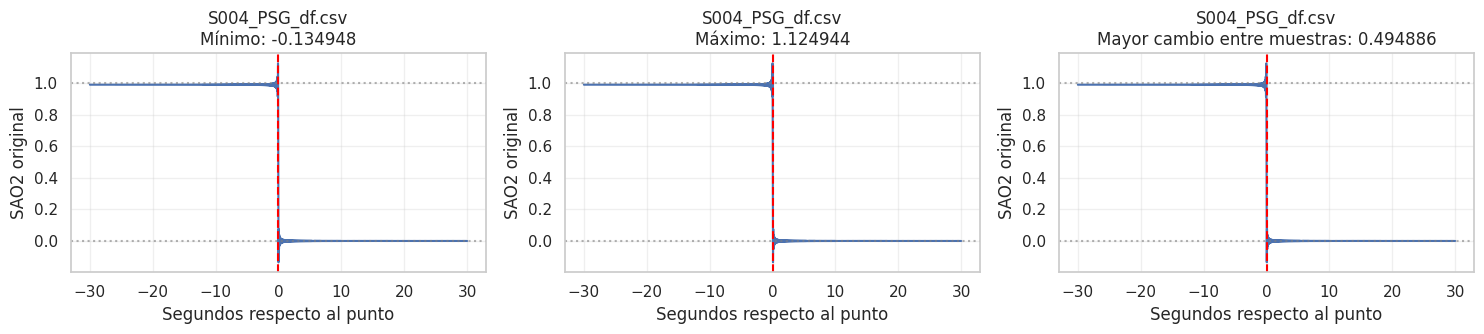


Inspeccionando SAO2: S006_PSG_df.csv


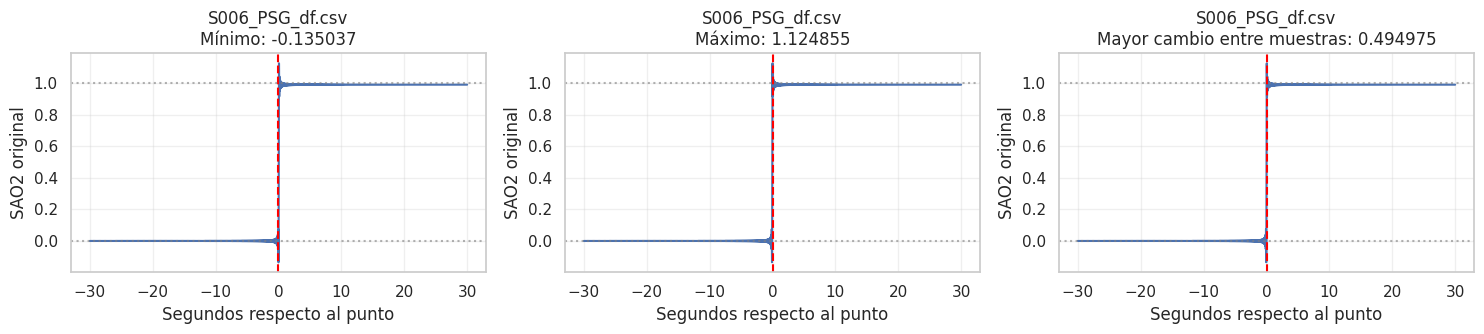


Inspeccionando SAO2: S027_PSG_df.csv


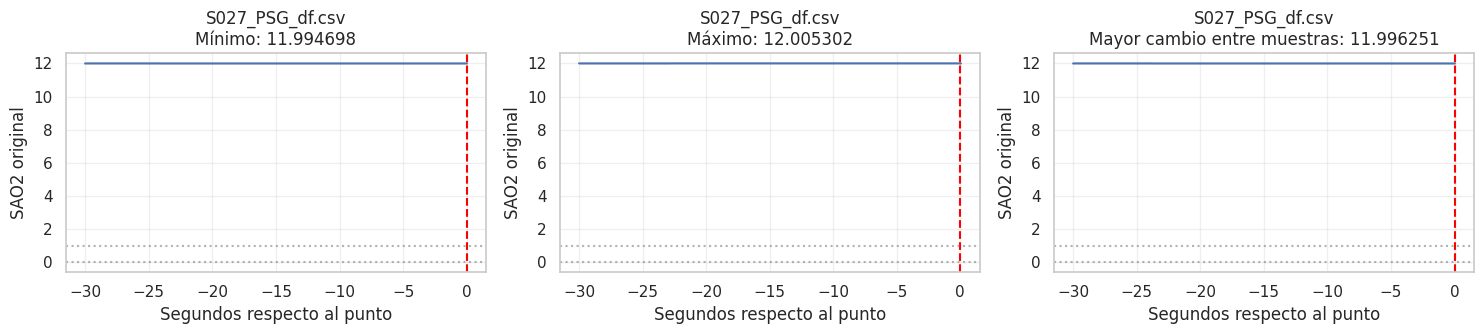


ESTADÍSTICAS DE LOS REGISTROS INSPECCIONADOS


,count,mean,std,min,1%,50%,99%,max,archivo,negativos,mayores_1,ceros_exactos
0,2413100.0,0.893009,0.079369,-0.134948,0.740000,0.899768,0.980061,1.124944,S004_PSG_df.csv,1458,19,0
1,2403000.0,0.961867,0.094311,-0.135037,0.919763,0.969924,0.989707,1.124855,S006_PSG_df.csv,2470,36,0
2,2276900.0,12.000000,0.001338,11.994698,11.996332,12.000000,12.003668,12.005302,S027_PSG_df.csv,0,2276900,0



UBICACIÓN DE LOS PUNTOS INSPECCIONADOS


,archivo,motivo,fila_original,TIMESTAMP,SAO2,SAO2_anterior
0,S004_PSG_df.csv,Mínimo,238270,9222.70,-0.134948,-0.118288
1,S004_PSG_df.csv,Máximo,238262,9222.62,1.124944,1.069550
2,S004_PSG_df.csv,Mayor cambio entre muestras,238266,9222.66,0.494886,0.772511
3,S006_PSG_df.csv,Mínimo,2006222,27262.22,-0.135037,-0.079650
4,S006_PSG_df.csv,Máximo,2006230,27262.30,1.124855,1.108188
5,S006_PSG_df.csv,Mayor cambio entre muestras,2006226,27262.26,0.494975,0.217356
6,S027_PSG_df.csv,Mínimo,2276898,31078.98,11.994698,11.996251
7,S027_PSG_df.csv,Máximo,2276894,31078.94,12.005302,12.003749
8,S027_PSG_df.csv,Mayor cambio entre muestras,2276897,31078.97,11.996251,12.000000



No se modificaron valores. Los gráficos tienen escalas verticales independientes. Falta contrastar los casos con el procesamiento de origen.


In [49]:
# 2.6.2. Inspección de SAO2

carpeta_revision = Path("/kaggle/working/auditoria")

# Utilizar la auditoría guardada; no recorrer nuevamente todos los CSV.
auditoria_p = pd.read_csv(
    carpeta_revision / "auditoria_pacientes.csv"
)
auditoria_s = pd.read_csv(
    carpeta_revision / "auditoria_senales.csv"
)

rangos_sao2 = auditoria_s.loc[
    auditoria_s["señal"].eq("SAO2"),
    ["archivo", "minimo", "maximo"],
]

resumen_sao2 = auditoria_p[
    ["archivo", "filas", "ceros_sao2", "sao2_fuera_escala_0_1"]
].merge(rangos_sao2, on="archivo", how="left")

resumen_sao2["fuera_0_1_pct"] = (
    100 * resumen_sao2["sao2_fuera_escala_0_1"]
    / resumen_sao2["filas"]
)

print("RESUMEN GENERAL DE SAO2")
print(
    "Pacientes con muestras fuera de 0–1:",
    int(resumen_sao2["sao2_fuera_escala_0_1"].gt(0).sum()),
)
print(
    "Pacientes con ceros exactos:",
    int(resumen_sao2["ceros_sao2"].gt(0).sum()),
)

# Mostrar los rangos más alejados del intervalo supuesto.
print("\nDIEZ PACIENTES CON MAYOR PORCENTAJE FUERA DE 0–1")
display(
    resumen_sao2.sort_values(
        "fuera_0_1_pct", ascending=False
    ).head(10).round(5)
)

pacientes_sao2_preferidos = [
    "S004_PSG_df.csv",
    "S006_PSG_df.csv",
    "S027_PSG_df.csv",
]
nombres_disponibles = {p.name for p in data_files}
nombres_revision_sao2 = [
    nombre for nombre in pacientes_sao2_preferidos
    if nombre in nombres_disponibles
]
if not nombres_revision_sao2:
    nombres_revision_sao2 = [p.name for p in data_files[:3]]

estadisticas_sao2 = []
puntos_revision_sao2 = []

for nombre in nombres_revision_sao2:
    ruta = next(p for p in data_files if p.name == nombre)
    print(f"\nInspeccionando SAO2: {nombre}", flush=True)

    # Solo dos columnas; un paciente por vez.
    datos = pd.read_csv(
        ruta,
        usecols=["TIMESTAMP", "SAO2"],
    )

    valores = pd.to_numeric(datos["SAO2"], errors="coerce")
    tiempos = pd.to_numeric(datos["TIMESTAMP"], errors="coerce")
    finitos = valores.where(np.isfinite(valores))

    if finitos.notna().sum() == 0:
        print("No hay valores finitos para inspeccionar.")
        continue

    estadisticas = finitos.describe(
        percentiles=[0.01, 0.50, 0.99]
    ).to_dict()
    estadisticas["archivo"] = nombre
    estadisticas["negativos"] = int(finitos.lt(0).sum())
    estadisticas["mayores_1"] = int(finitos.gt(1).sum())
    estadisticas["ceros_exactos"] = int(finitos.eq(0).sum())
    estadisticas_sao2.append(estadisticas)

    # Diferencia absoluta entre muestras consecutivas.
    diferencias = finitos.diff().abs()

    posiciones = {
        "Mínimo": int(finitos.idxmin()),
        "Máximo": int(finitos.idxmax()),
    }

    if diferencias.notna().any():
        posiciones["Mayor cambio entre muestras"] = int(
            diferencias.idxmax()
        )

    fig, axes = plt.subplots(
        1, len(posiciones),
        figsize=(5 * len(posiciones), 3.5),
        squeeze=False,
    )

    for ax, (motivo, posicion) in zip(
        axes[0], posiciones.items()
    ):
        inicio = max(0, posicion - 3000)
        fin = min(len(datos), posicion + 3001)

        ax.plot(
            tiempos.iloc[inicio:fin] - tiempos.iloc[posicion],
            valores.iloc[inicio:fin],
        )
        ax.axvline(0, color="red", linestyle="--")

        # Referencias de escala; no son reglas de limpieza.
        ax.axhline(0, color="gray", linestyle=":", alpha=0.6)
        ax.axhline(1, color="gray", linestyle=":", alpha=0.6)

        ax.set_title(
            f"{nombre}\n{motivo}: {valores.iloc[posicion]:.6f}"
        )
        ax.set_xlabel("Segundos respecto al punto")
        ax.set_ylabel("SAO2 original")
        ax.grid(alpha=0.3)

        puntos_revision_sao2.append({
            "archivo": nombre,
            "motivo": motivo,
            "fila_original": posicion,
            "TIMESTAMP": tiempos.iloc[posicion],
            "SAO2": valores.iloc[posicion],
            "SAO2_anterior": (
                valores.iloc[posicion - 1]
                if posicion > 0 else np.nan
            ),
        })

    plt.tight_layout()
    plt.show()

    del datos, valores, tiempos, finitos, diferencias

estadisticas_sao2 = pd.DataFrame(estadisticas_sao2)
puntos_revision_sao2 = pd.DataFrame(puntos_revision_sao2)

print("\nESTADÍSTICAS DE LOS REGISTROS INSPECCIONADOS")
display(estadisticas_sao2.round(6))

print("\nUBICACIÓN DE LOS PUNTOS INSPECCIONADOS")
display(puntos_revision_sao2)

exportar_csv_validado(
    estadisticas_sao2, carpeta_revision / "revision_estadisticas_sao2.csv"
)
exportar_csv_validado(
    puntos_revision_sao2, carpeta_revision / "revision_puntos_sao2.csv"
)

print(
    "\nNo se modificaron valores. "
    "Los gráficos tienen escalas verticales independientes. "
    "Falta contrastar los casos con el procesamiento de origen."
)

### 2.6.3. Revisión de señales constantes

Se identifican señales constantes durante todo el registro y tramos
prolongados sin cambios, utilizando los resultados de la auditoría general.

Se priorizan S097 y los pacientes con IBI constante. Una señal
numérica y sin nulos puede igualmente carecer de variación útil.

Los tramos constantes no se consideran errores automáticamente:
pueden relacionarse con el registro, el relleno o el procesamiento.
No se modifican ni eliminan señales en esta revisión.

In [50]:
# 2.6.3. Revisión de señales constantes

carpeta_revision = Path("/kaggle/working/auditoria")
auditoria_constantes = pd.read_csv(
    carpeta_revision / "auditoria_senales.csv"
)

columnas_detalle = [
    "archivo",
    "señal",
    "filas",
    "minimo",
    "maximo",
    "mayor_tramo_constante_muestras",
    "inicio_tramo_constante_fila",
    "duracion_constante_segundos_100hz",
]

# Porcentaje del registro ocupado por su mayor tramo constante.
auditoria_constantes["mayor_tramo_constante_pct"] = (
    100
    * auditoria_constantes["mayor_tramo_constante_muestras"]
    / auditoria_constantes["filas"]
)

# Constancia en todas las muestras del registro.
constantes_completas = auditoria_constantes.loc[
    auditoria_constantes["mayor_tramo_constante_muestras"].eq(
        auditoria_constantes["filas"]
    )
    & auditoria_constantes["filas"].gt(0)
].copy()

print("SEÑALES CONSTANTES DURANTE TODO EL REGISTRO")
display(
    constantes_completas[
        columnas_detalle + ["mayor_tramo_constante_pct"]
    ].sort_values(["archivo", "señal"])
)

print("\nCANTIDAD DE SEÑALES COMPLETAMENTE CONSTANTES POR PACIENTE")
display(
    constantes_completas.groupby("archivo")
    .size()
    .rename("señales_constantes")
    .reset_index()
)

print("\nDETALLE DE S097")
display(
    auditoria_constantes.loc[
        auditoria_constantes["archivo"].eq("S097_PSG_df.csv"),
        columnas_detalle + ["mayor_tramo_constante_pct"],
    ].sort_values("señal")
)

print("\nIBI: DIEZ MAYORES TRAMOS CONSTANTES")
display(
    auditoria_constantes.loc[
        auditoria_constantes["señal"].eq("IBI"),
        columnas_detalle + ["mayor_tramo_constante_pct"],
    ]
    .sort_values("mayor_tramo_constante_pct", ascending=False)
    .head(10)
)

# Umbral exploratorio, no una regla de eliminación.
tramos_prolongados = auditoria_constantes.loc[
    auditoria_constantes[
        "duracion_constante_segundos_100hz"
    ].ge(30)
].copy()

print("\nTRAMOS CONSTANTES DE AL MENOS 30 SEGUNDOS")
display(
    tramos_prolongados.groupby("señal")
    .agg(
        pacientes=("archivo", "nunique"),
        mayor_duracion_segundos=(
            "duracion_constante_segundos_100hz", "max"
        ),
    )
    .reset_index()
    .sort_values("pacientes", ascending=False)
)

exportar_csv_validado(
    constantes_completas, carpeta_revision / "revision_constantes_completas.csv"
)

print(
    "\nNo se modificaron señales. "
    "Una señal completamente constante tendrá desviación estándar "
    "cero en sus epochs, pero eso no explica la causa. "
    "La duración supone continuidad a 100 Hz, "
    "comprobada en la auditoría general."
)

SEÑALES CONSTANTES DURANTE TODO EL REGISTRO


,archivo,señal,filas,minimo,maximo,mayor_tramo_constante_muestras,inicio_tramo_constante_fila,duracion_constante_segundos_100hz,mayor_tramo_constante_pct
649,S026_PSG_df.csv,IBI,2186900,7.500000e-01,7.500000e-01,2186900,0.0,21868.99,100.0
753,S030_PSG_df.csv,IBI,2193000,9.843750e-01,9.843750e-01,2193000,0.0,21929.99,100.0
909,S036_PSG_df.csv,IBI,2715700,5.625000e-01,5.625000e-01,2715700,0.0,27156.99,100.0
1143,S046_PSG_df.csv,IBI,2150300,3.906250e-01,3.906250e-01,2150300,0.0,21502.99,100.0
1888,S097_PSG_df.csv,ABDOMEN,2126000,4.882887e-08,4.882887e-08,2126000,0.0,21259.99,100.0
1872,S097_PSG_df.csv,C4-M1,2126000,4.882887e-08,4.882887e-08,2126000,0.0,21259.99,100.0
1878,S097_PSG_df.csv,CHIN,2126000,4.882887e-08,4.882887e-08,2126000,0.0,21259.99,100.0
1877,S097_PSG_df.csv,CZ - T4,2126000,4.882887e-08,4.882887e-08,2126000,0.0,21259.99,100.0
1879,S097_PSG_df.csv,E1,2126000,4.882887e-08,4.882887e-08,2126000,0.0,21259.99,100.0
1880,S097_PSG_df.csv,E2,2126000,4.882887e-08,4.882887e-08,2126000,0.0,21259.99,100.0



CANTIDAD DE SEÑALES COMPLETAMENTE CONSTANTES POR PACIENTE


,archivo,señales_constantes
0,S026_PSG_df.csv,1
1,S030_PSG_df.csv,1
2,S036_PSG_df.csv,1
3,S046_PSG_df.csv,1
4,S097_PSG_df.csv,18



DETALLE DE S097


...


IBI: DIEZ MAYORES TRAMOS CONSTANTES


,archivo,señal,filas,minimo,maximo,mayor_tramo_constante_muestras,inicio_tramo_constante_fila,duracion_constante_segundos_100hz,mayor_tramo_constante_pct
753,S030_PSG_df.csv,IBI,2193000,0.984375,0.984375,2193000,0.0,21929.99,100.000000
649,S026_PSG_df.csv,IBI,2186900,0.750000,0.750000,2186900,0.0,21868.99,100.000000
1143,S046_PSG_df.csv,IBI,2150300,0.390625,0.390625,2150300,0.0,21502.99,100.000000
909,S036_PSG_df.csv,IBI,2715700,0.562500,0.562500,2715700,0.0,27156.99,100.000000
1897,S097_PSG_df.csv,IBI,2126000,1.031250,1.031250,2126000,0.0,21259.99,100.000000
415,S017_PSG_df.csv,IBI,2311500,1.031250,1.546875,2272963,38537.0,22729.62,98.332814
1455,S058_PSG_df.csv,IBI,2298000,0.375000,1.437500,1902444,395556.0,19024.43,82.786945
1377,S055_PSG_df.csv,IBI,2307300,0.578125,0.937500,1873404,433896.0,18734.03,81.194643
1091,S044_PSG_df.csv,IBI,2229000,0.390625,2.000000,1799225,429775.0,17992.24,80.718932
1533,S067_PSG_df.csv,IBI,2465200,0.734375,1.968750,1620193,845007.0,16201.92,65.722578



TRAMOS CONSTANTES DE AL MENOS 30 SEGUNDOS


,señal,pacientes,mayor_duracion_segundos
1,ACC_X,74,10045.04
2,ACC_Y,74,1946.12
16,IBI,74,27156.99
3,ACC_Z,73,1163.52
11,EDA,70,1479.75
4,BVP,70,74.86
24,TEMP,70,75.84
15,HR,70,103.77
0,ABDOMEN,2,21259.99
5,C4-M1,2,21259.99



No se modificaron señales. Una señal completamente constante tendrá desviación estándar cero en sus epochs, pero eso no explica la causa. La duración supone continuidad a 100 Hz, comprobada en la auditoría general.


### 2.6.4. Revisión de diferencias en EDA

EDA mide conductancia de la piel (µS según la documentación del dataset). La auditoría general permite comparar los máximos de **todos los archivos disponibles**; un máximo no describe el nivel habitual ni la duración de un episodio. Solo en S002, S004 y S057 (si están disponibles) se inspecciona la trayectoria cruda, el entorno del máximo y del mayor cambio, ACC en ambos momentos y HR/TEMP alrededor del máximo. El máximo y el mayor cambio pueden ocurrir en instantes distintos: no deben interpretarse como un único evento. La vista completa toma un punto por segundo **solo para dibujar**; los cálculos y las ventanas alrededor de los eventos utilizan todas las muestras.

Un máximo alto o un salto rápido **no demuestra error**: puede reflejar una respuesta real, diferencias entre personas, movimiento, contacto deficiente, saturación o cambio de escala. Coincidencia con ACC aumenta la sospecha de artefacto, pero tampoco lo confirma. La desviación estándar por epoch de 3.3.1 responde otra pregunta: puede ser alta durante un tramo de variación sin contener el máximo global de EDA.

**Casos pendientes de revisión:** `S004_PSG_df.csv` presenta un máximo elevado y un cambio entre muestras que requieren comprobar continuidad y escala. `S057_PSG_df.csv` muestra una subida pronunciada seguida de un descenso prolongado; la ausencia de un cambio evidente en ACC alrededor del punto inspeccionado no descarta un problema de contacto. Son *marcas de revisión*, no errores confirmados ni motivos de exclusión.

Para S004 se añade una vista de los minutos 190–230, alrededor del inicio aparente de la elevación. EDA, movimiento, HR, TEMP y `Sleep_Stage` comparten el eje temporal. La línea en el minuto 210 es una **referencia visual**, no un cambio detectado automáticamente. Las medianas por segundo y la variabilidad de ACC por cinco segundos solo facilitan la visualización; no modifican las muestras ni los epochs.

**Cómo comprobar el patrón:** (1) comparar varios minutos antes, durante y después de cada episodio en la señal EDA completa; distinguir un pico aislado de un cambio sostenido de nivel; (2) contrastar en los mismos timestamps ACC, TEMP y HR, sin tomar la falta de movimiento como prueba de calidad; (3) buscar episodios semejantes en el mismo paciente y comparar su nivel basal y sus percentiles con otros pacientes, comprobando unidades y cobertura. EDA se midió originalmente a 4 Hz y se remuestreó a 100 Hz en DREAMT: filas consecutivas del CSV no son mediciones originales independientes. [Fuente del dataset](https://physionet.org/content/dreamt/2.2.0/).

**Decisión pendiente:** si se confirma una conversión errónea, corregirla desde la fuente y recalcular; si un tramo es claramente defectuoso, invalidar solo EDA en ese tramo y comprobar cuántas muestras válidas quedan por epoch. Si la variación es sostenida y fiable, conservarla. Si persiste la duda, mantener el dato marcado para análisis posterior. **No se recorta ni normaliza EDA por el solo hecho de ser extrema.**


DIEZ MAYORES MÁXIMOS DE EDA


,archivo,minimo,maximo,nulos,infinitos
1427,S057_PSG_df.csv,0.031015,57.666389,0,0
75,S004_PSG_df.csv,0.102755,53.174881,0,0
673,S027_PSG_df.csv,2.368708,34.935596,0,0
1063,S043_PSG_df.csv,1.656697,21.967810,0,0
1609,S082_PSG_df.csv,0.141162,18.233290,0,0
699,S028_PSG_df.csv,0.648455,17.295322,0,0
1297,S052_PSG_df.csv,0.000000,14.436932,0,0
543,S022_PSG_df.csv,0.543424,11.731063,0,0
465,S019_PSG_df.csv,0.000000,10.431508,0,0
881,S035_PSG_df.csv,0.042535,10.409482,0,0


Máximos EDA graficables: 74/74 archivos


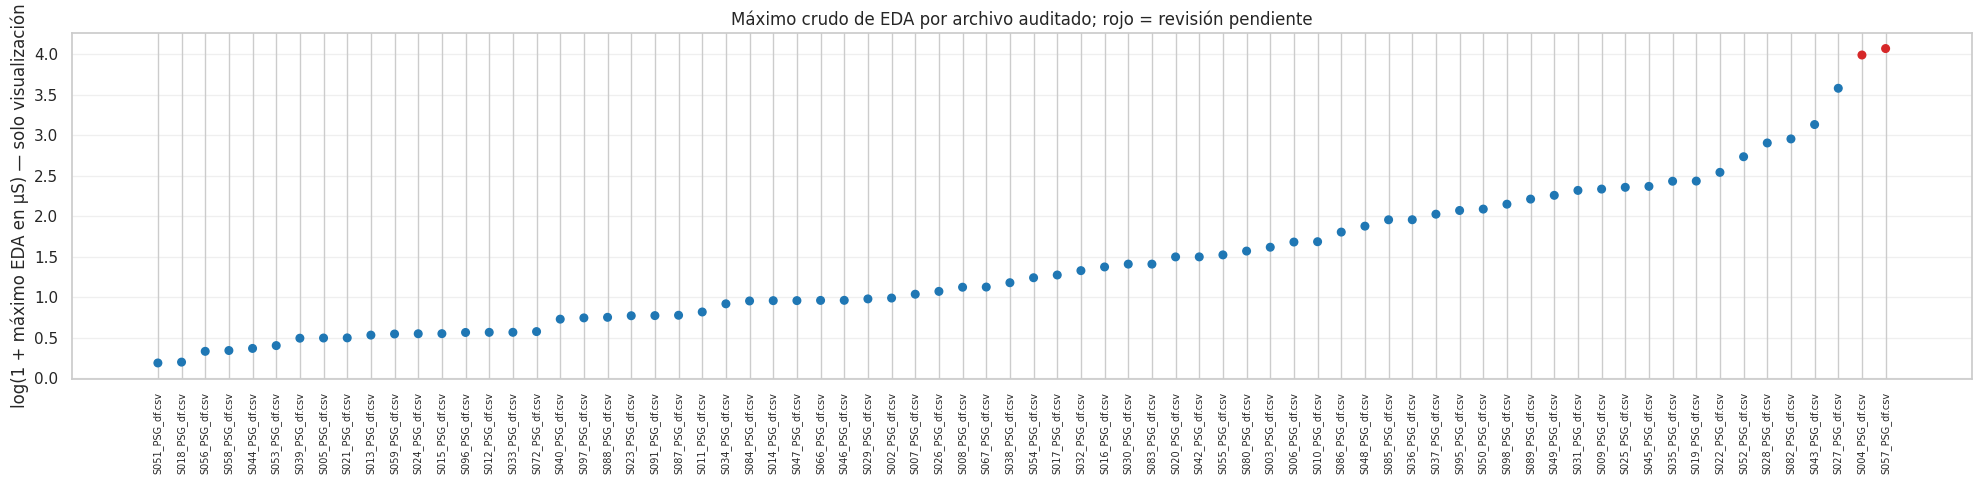


Inspeccionando EDA: S002_PSG_df.csv


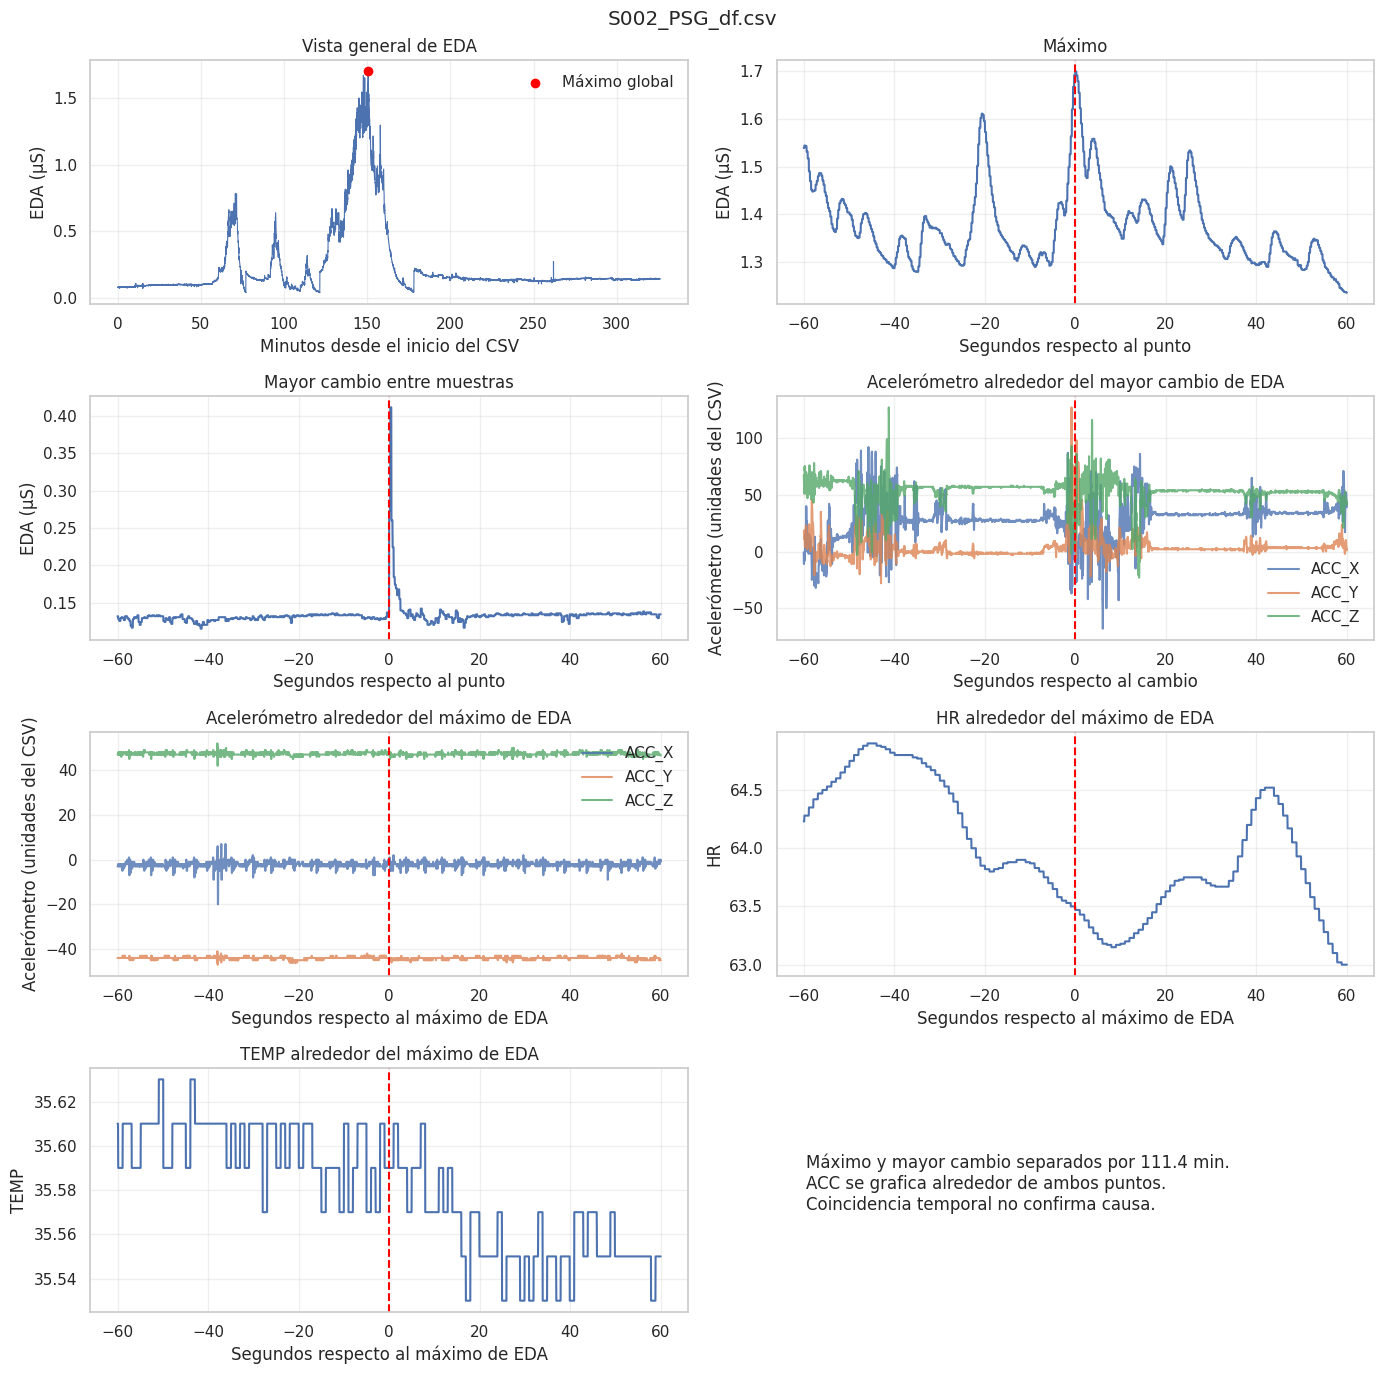


Inspeccionando EDA: S004_PSG_df.csv


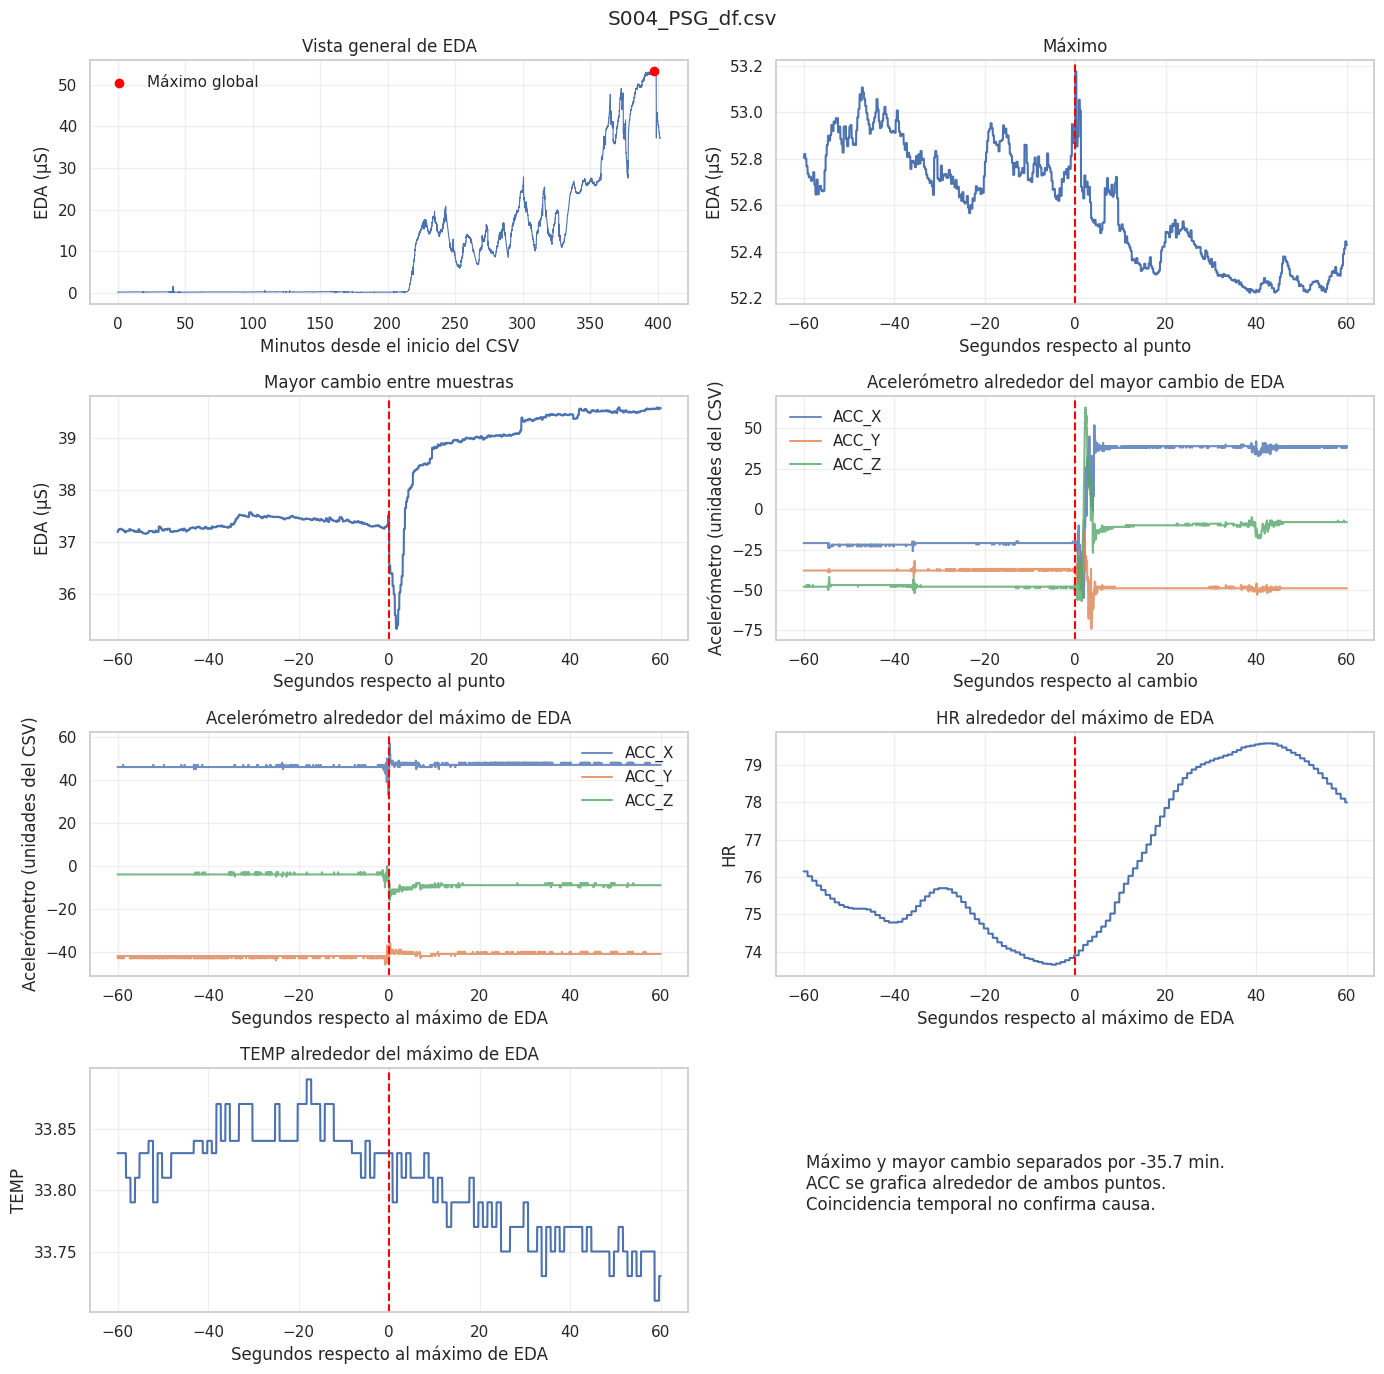

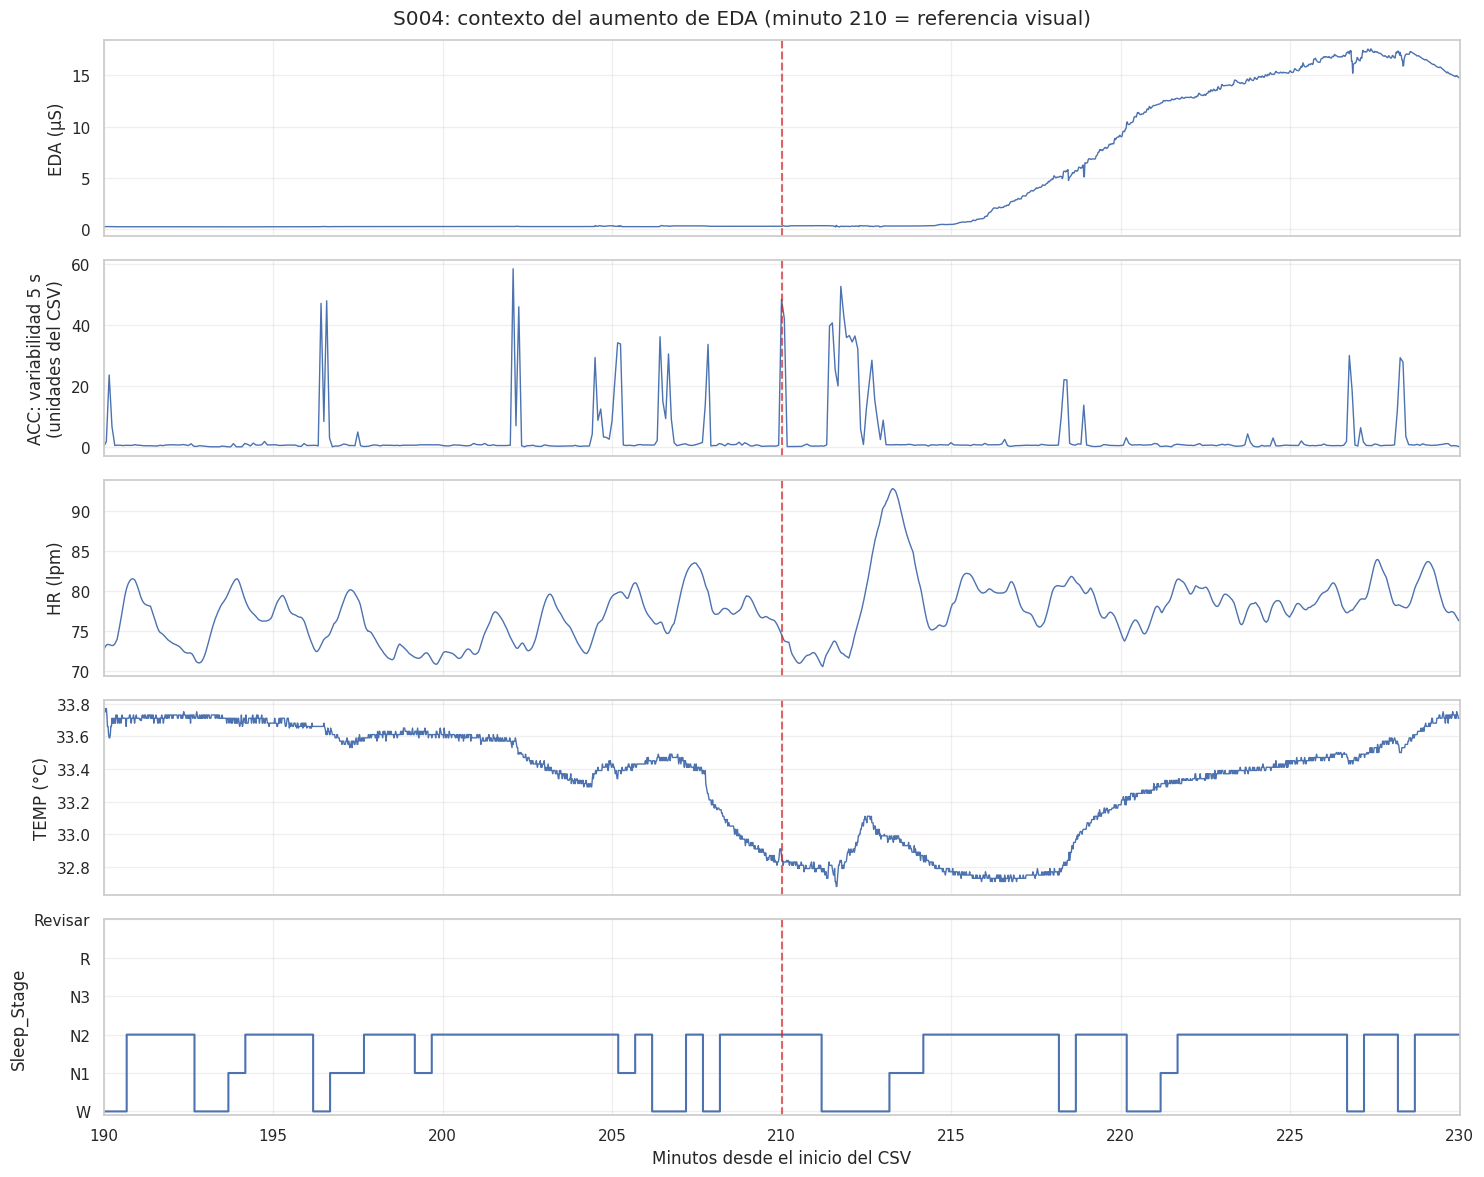


Inspeccionando EDA: S057_PSG_df.csv


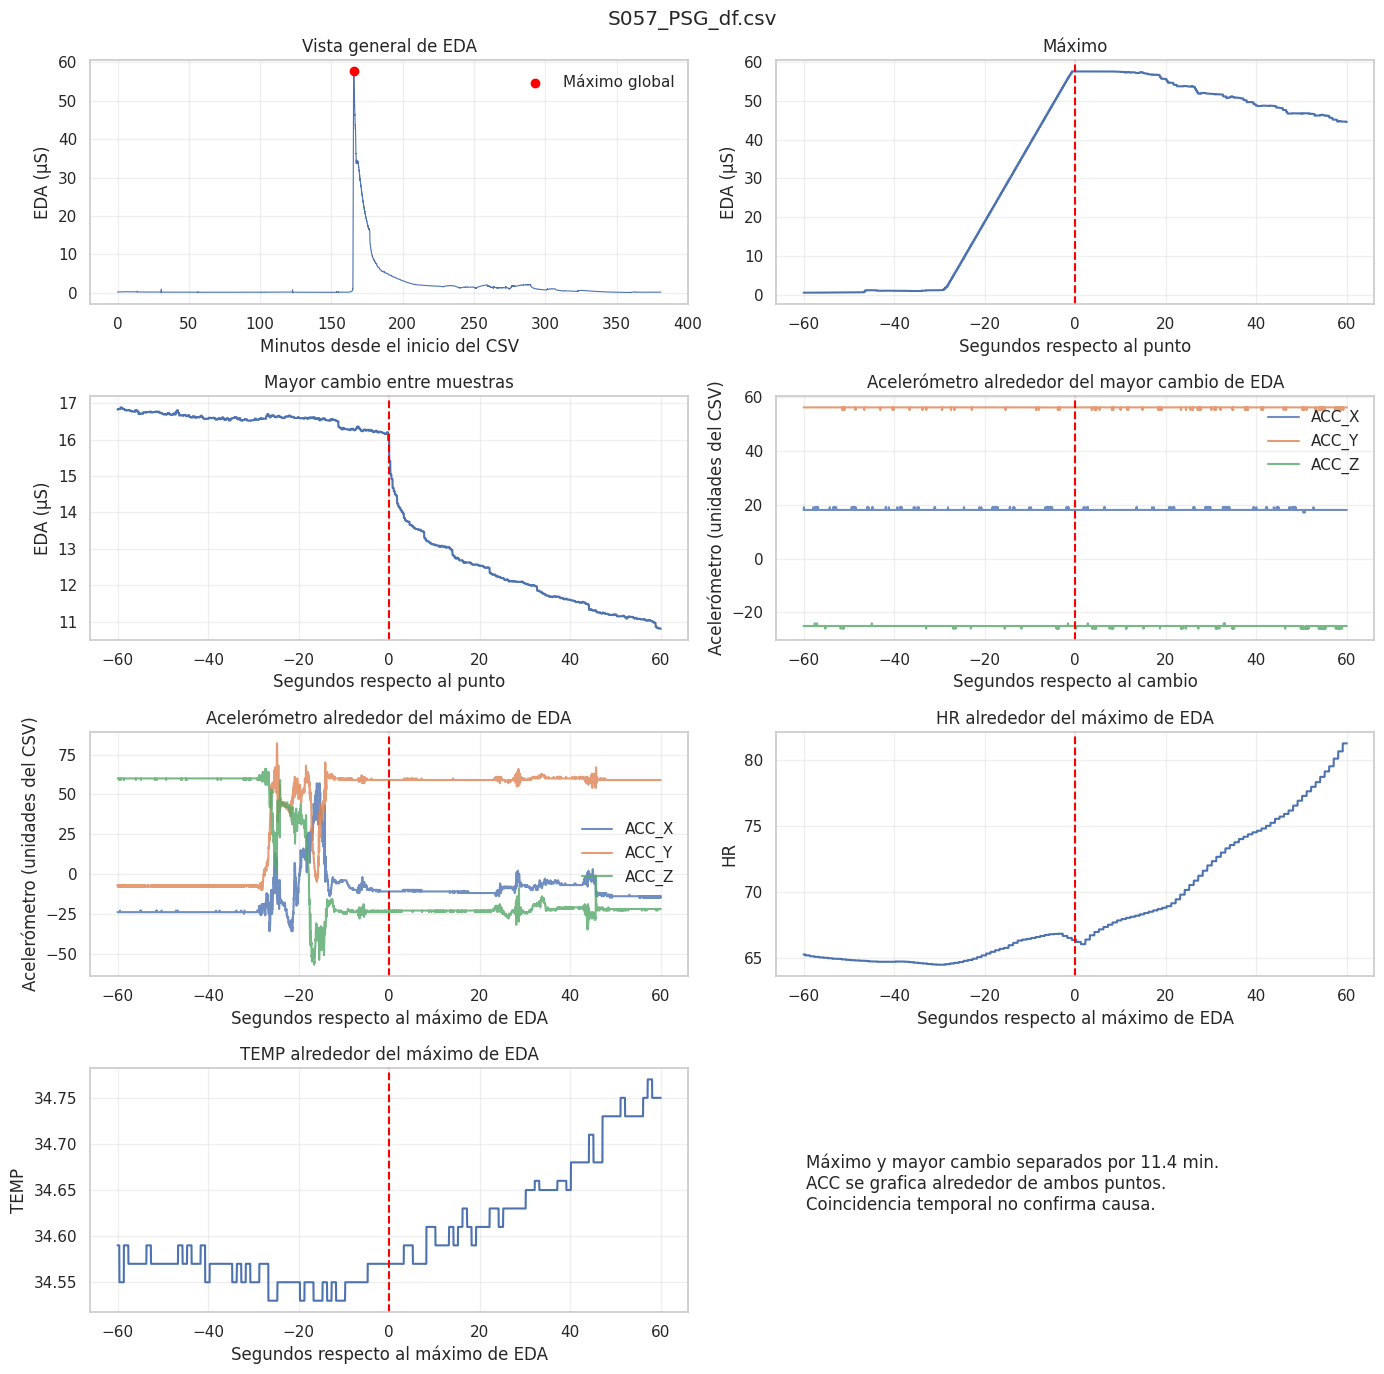


ESTADÍSTICAS DE EDA POR PACIENTE


,count,mean,std,min,1%,25%,50%,75%,99%,max,archivo,valores_negativos,mayor_cambio_absoluto,estado_revision,motivo_revision
0,1958400.0,0.231192,0.267470,0.036129,0.051498,0.109197,0.139606,0.167784,1.360635,1.698764,S002_PSG_df.csv,0,0.130614,Referencia exploratoria,
1,2413100.0,10.635652,14.412380,0.102755,0.207805,0.280828,0.324385,16.530336,52.520241,53.174881,S004_PSG_df.csv,0,0.912041,Pendiente de revisión,Máximo elevado y cambio entre muestras: compro...
2,2286000.0,1.829836,5.321679,0.031015,0.110448,0.167834,0.245986,1.551940,32.728745,57.666389,S057_PSG_df.csv,0,0.558282,Pendiente de revisión,Subida y descenso prolongados: comprobar conti...



CASOS DE EDA PENDIENTES DE REVISIÓN


,archivo,min,50%,99%,max,mayor_cambio_absoluto,estado_revision,motivo_revision
1,S004_PSG_df.csv,0.102755,0.324385,52.520241,53.174881,0.912041,Pendiente de revisión,Máximo elevado y cambio entre muestras: compro...
2,S057_PSG_df.csv,0.031015,0.245986,32.728745,57.666389,0.558282,Pendiente de revisión,Subida y descenso prolongados: comprobar conti...



UBICACIÓN DE LOS PUNTOS INSPECCIONADOS


,archivo,motivo,fila_original,TIMESTAMP,EDA,EDA_anterior,cambio_entre_muestras,estado_revision,motivo_revision
0,S002_PSG_df.csv,Máximo,903539,20915.39,1.698764,1.698090,0.000674,Referencia exploratoria,
1,S002_PSG_df.csv,Mayor cambio entre muestras,1571881,27598.81,0.272808,0.142194,0.130614,Referencia exploratoria,
2,S004_PSG_df.csv,Máximo,2381748,30657.48,53.174881,52.904557,0.270324,Pendiente de revisión,Máximo elevado y cambio entre muestras: compro...
3,S004_PSG_df.csv,Mayor cambio entre muestras,2167659,28516.59,36.541969,37.454010,-0.912041,Pendiente de revisión,Máximo elevado y cambio entre muestras: compro...
4,S057_PSG_df.csv,Máximo,993377,19413.77,57.666389,57.664639,0.001750,Pendiente de revisión,Subida y descenso prolongados: comprobar conti...
5,S057_PSG_df.csv,Mayor cambio entre muestras,1061502,20095.02,15.413518,15.971800,-0.558282,Pendiente de revisión,Subida y descenso prolongados: comprobar conti...



No se modificaron valores. La vista general puede ocultar eventos breves por su muestreo visual; los gráficos de detalle utilizan todas las muestras. Los valores elevados o el movimiento coincidente no confirman por sí solos un error.


In [51]:
# 2.6.4. Inspección de EDA y contexto de movimiento

carpeta_revision = Path("/kaggle/working/auditoria")

auditoria_eda = pd.read_csv(
    carpeta_revision / "auditoria_senales.csv"
)

rangos_eda = auditoria_eda.loc[
    auditoria_eda["señal"].eq("EDA"),
    ["archivo", "minimo", "maximo", "nulos", "infinitos"],
].sort_values("maximo", ascending=False)

print("DIEZ MAYORES MÁXIMOS DE EDA")
display(rangos_eda.head(10))

# Panorama de todos los pacientes auditados, sin releer señales crudas.
maximos_eda = rangos_eda.copy()
maximos_eda["maximo"] = pd.to_numeric(maximos_eda["maximo"], errors="coerce")
validos_max = np.isfinite(maximos_eda["maximo"]) & maximos_eda["maximo"].ge(0)
print(f"Máximos EDA graficables: {int(validos_max.sum())}/{len(maximos_eda)} archivos")
maximos_eda = maximos_eda.loc[validos_max].sort_values("maximo").reset_index(drop=True)
if not maximos_eda.empty:
    destacados = maximos_eda["archivo"].isin(["S004_PSG_df.csv", "S057_PSG_df.csv"])
    fig, ax = plt.subplots(figsize=(max(12, 0.27 * len(maximos_eda)), 5))
    ax.scatter(np.arange(len(maximos_eda)), np.log1p(maximos_eda["maximo"]),
               c=np.where(destacados, "tab:red", "tab:blue"), s=30)
    ax.set_xticks(np.arange(len(maximos_eda)))
    ax.set_xticklabels(maximos_eda["archivo"], rotation=90, fontsize=7)
    ax.set_ylabel("log(1 + máximo EDA en µS) — solo visualización")
    ax.set_title("Máximo crudo de EDA por archivo auditado; rojo = revisión pendiente")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

pacientes_eda_preferidos = [
    "S002_PSG_df.csv",
    "S004_PSG_df.csv",
    "S057_PSG_df.csv",
]
nombres_disponibles = {p.name for p in data_files}
nombres_revision_eda = [
    nombre for nombre in pacientes_eda_preferidos
    if nombre in nombres_disponibles
]
if not nombres_revision_eda:
    nombres_revision_eda = [p.name for p in data_files[:3]]

columnas_leer = [
    "TIMESTAMP", "EDA", "ACC_X", "ACC_Y", "ACC_Z",
    "HR", "TEMP", "Sleep_Stage",
]
estadisticas_eda = []
puntos_revision_eda = []

for nombre in nombres_revision_eda:
    ruta = next(p for p in data_files if p.name == nombre)
    print(f"\nInspeccionando EDA: {nombre}", flush=True)

    if ruta == sample_file:
        datos = df_sample_eda[columnas_leer].copy()
    else:
        datos = pd.read_csv(ruta, usecols=columnas_leer)

    datos = datos.reset_index(drop=True)

    valores = pd.to_numeric(datos["EDA"], errors="coerce")
    tiempos = pd.to_numeric(
        datos["TIMESTAMP"], errors="coerce"
    )
    finitos = valores.where(np.isfinite(valores))

    if finitos.notna().sum() == 0:
        print("No hay valores finitos para inspeccionar.")
        del datos
        continue

    diferencias = finitos.diff()
    diferencias_absolutas = diferencias.abs()

    if not diferencias_absolutas.notna().any():
        print("No hay pares válidos para calcular cambios.")
        del datos
        continue

    posicion_maximo = int(finitos.idxmax())
    posicion_cambio = int(diferencias_absolutas.idxmax())

    resumen = finitos.describe(
        percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
    ).to_dict()
    resumen["archivo"] = nombre
    resumen["valores_negativos"] = int(finitos.lt(0).sum())
    resumen["mayor_cambio_absoluto"] = float(
        diferencias_absolutas.iloc[posicion_cambio]
    )
    estadisticas_eda.append(resumen)

    fig, axes = plt.subplots(4, 2, figsize=(14, 14))

    # 1. Vista general: tomar una muestra por segundo para dibujar.
    # Solo reduce los puntos del gráfico; no cambia los datos analizados.
    posiciones_vista = np.arange(0, len(datos), 100)

    axes[0, 0].plot(
        (tiempos.iloc[posiciones_vista] - tiempos.iloc[0]) / 60,
        valores.iloc[posiciones_vista],
        linewidth=0.8,
    )
    axes[0, 0].scatter(
        (tiempos.iloc[posicion_maximo] - tiempos.iloc[0]) / 60,
        valores.iloc[posicion_maximo],
        color="red",
        label="Máximo global",
        zorder=5,
    )
    axes[0, 0].set_title("Vista general de EDA")
    axes[0, 0].set_xlabel("Minutos desde el inicio del CSV")
    axes[0, 0].set_ylabel("EDA (µS)")
    axes[0, 0].legend()

    # 2 y 3. Hasta 60 segundos alrededor del máximo y mayor cambio.
    for ax, motivo, posicion in [
        (axes[0, 1], "Máximo", posicion_maximo),
        (axes[1, 0], "Mayor cambio entre muestras", posicion_cambio),
    ]:
        inicio = max(0, posicion - 6000)
        fin = min(len(datos), posicion + 6001)

        ax.plot(
            tiempos.iloc[inicio:fin] - tiempos.iloc[posicion],
            valores.iloc[inicio:fin],
        )
        ax.axvline(0, color="red", linestyle="--")
        ax.set_title(motivo)
        ax.set_xlabel("Segundos respecto al punto")
        ax.set_ylabel("EDA (µS)")

        puntos_revision_eda.append({
            "archivo": nombre,
            "motivo": motivo,
            "fila_original": posicion,
            "TIMESTAMP": tiempos.iloc[posicion],
            "EDA": valores.iloc[posicion],
            "EDA_anterior": (
                valores.iloc[posicion - 1]
                if posicion > 0 else np.nan
            ),
            "cambio_entre_muestras": diferencias.iloc[posicion],
        })

    # 4. Acelerómetro en el MISMO intervalo del mayor cambio de EDA.
    inicio = max(0, posicion_cambio - 6000)
    fin = min(len(datos), posicion_cambio + 6001)
    tiempo_relativo = (
        tiempos.iloc[inicio:fin] - tiempos.iloc[posicion_cambio]
    )

    for eje in ["ACC_X", "ACC_Y", "ACC_Z"]:
        axes[1, 1].plot(
            tiempo_relativo,
            pd.to_numeric(
                datos[eje].iloc[inicio:fin], errors="coerce"
            ),
            label=eje,
            alpha=0.8,
        )

    axes[1, 1].axvline(0, color="red", linestyle="--")
    axes[1, 1].set_title(
        "Acelerómetro alrededor del mayor cambio de EDA"
    )
    axes[1, 1].set_xlabel("Segundos respecto al cambio")
    axes[1, 1].set_ylabel("Acelerómetro (unidades del CSV)")
    axes[1, 1].legend()

    # ACC, HR y TEMP en la MISMA ventana temporal del máximo de EDA.
    inicio_max = max(0, posicion_maximo - 6000)
    fin_max = min(len(datos), posicion_maximo + 6001)
    tiempo_max = tiempos.iloc[inicio_max:fin_max] - tiempos.iloc[posicion_maximo]
    for eje in ["ACC_X", "ACC_Y", "ACC_Z"]:
        axes[2, 0].plot(
            tiempo_max, pd.to_numeric(datos[eje].iloc[inicio_max:fin_max], errors="coerce"),
            label=eje, alpha=0.8,
        )
    axes[2, 0].axvline(0, color="red", linestyle="--")
    axes[2, 0].set_title("Acelerómetro alrededor del máximo de EDA")
    axes[2, 0].set_xlabel("Segundos respecto al máximo de EDA")
    axes[2, 0].set_ylabel("Acelerómetro (unidades del CSV)")
    axes[2, 0].legend()
    for ax, senal in [(axes[2, 1], "HR"), (axes[3, 0], "TEMP")]:
        ax.plot(
            tiempo_max,
            pd.to_numeric(datos[senal].iloc[inicio_max:fin_max], errors="coerce"),
        )
        ax.axvline(0, color="red", linestyle="--")
        ax.set_title(f"{senal} alrededor del máximo de EDA")
        ax.set_xlabel("Segundos respecto al máximo de EDA")
        ax.set_ylabel(senal)
    separacion_minutos = (
        tiempos.iloc[posicion_cambio] - tiempos.iloc[posicion_maximo]
    ) / 60
    axes[3, 1].axis("off")
    axes[3, 1].text(
        0.05, 0.65,
        f"Máximo y mayor cambio separados por {separacion_minutos:.1f} min.\n"
        "ACC se grafica alrededor de ambos puntos.\n"
        "Coincidencia temporal no confirma causa.",
        transform=axes[3, 1].transAxes, va="top",
    )

    for ax in axes.flat:
        ax.grid(alpha=0.3)

    fig.suptitle(nombre)
    plt.tight_layout()
    plt.show()

    if nombre == "S004_PSG_df.csv":
        # Zoom exploratorio: reutiliza el CSV ya cargado y no cambia el ETL.
        minuto_inicio, minuto_fin = 190, 230
        minuto_relativo = (tiempos - tiempos.iloc[0]) / 60
        ventana = datos.loc[minuto_relativo.between(minuto_inicio, minuto_fin)].copy()
        if ventana.empty:
            print("S004: no hay muestras en los minutos 190–230.")
        else:
            ventana["segundo"] = np.floor(
                tiempos.loc[ventana.index] - tiempos.iloc[0]
            ).astype(int)
            for senal in ["EDA", "HR", "TEMP", "ACC_X", "ACC_Y", "ACC_Z"]:
                ventana[senal] = pd.to_numeric(ventana[senal], errors="coerce")
            por_segundo = ventana.groupby("segundo")[["EDA", "HR", "TEMP"]].median()
            acc_5s = ventana.groupby(ventana["segundo"] // 5)[
                ["ACC_X", "ACC_Y", "ACC_Z"]
            ].std(ddof=0)
            movimiento = np.sqrt(acc_5s.pow(2).sum(axis=1, min_count=1))
            etapas = ventana.groupby("segundo")["Sleep_Stage"].first()
            orden_etapas = ["W", "N1", "N2", "N3", "R", "Revisar"]
            etapas = etapas.where(etapas.isin(orden_etapas[:-1]), "Revisar")
            etapas_num = etapas.map({etapa: i for i, etapa in enumerate(orden_etapas)})

            fig, ejes = plt.subplots(5, 1, figsize=(15, 12), sharex=True)
            for ax, senal, unidad in [
                (ejes[0], "EDA", "EDA (µS)"),
                (ejes[2], "HR", "HR (lpm)"),
                (ejes[3], "TEMP", "TEMP (°C)"),
            ]:
                ax.plot(por_segundo.index / 60, por_segundo[senal], linewidth=1)
                ax.set_ylabel(unidad)
            ejes[1].plot(movimiento.index * 5 / 60, movimiento, linewidth=1)
            ejes[1].set_ylabel("ACC: variabilidad 5 s\n(unidades del CSV)")
            ejes[4].step(etapas_num.index / 60, etapas_num, where="post")
            ejes[4].set_yticks(range(len(orden_etapas)), orden_etapas)
            ejes[4].set_ylabel("Sleep_Stage")
            ejes[4].set_xlabel("Minutos desde el inicio del CSV")
            for ax in ejes:
                ax.axvline(210, color="tab:red", linestyle="--", alpha=0.7)
                ax.set_xlim(minuto_inicio, minuto_fin)
                ax.grid(alpha=0.3)
            fig.suptitle("S004: contexto del aumento de EDA (minuto 210 = referencia visual)")
            plt.tight_layout()
            plt.show()
            del ventana, por_segundo, acc_5s, movimiento, etapas, etapas_num

    del datos, valores, tiempos, finitos
    del diferencias, diferencias_absolutas

estadisticas_eda = pd.DataFrame(estadisticas_eda)
puntos_revision_eda = pd.DataFrame(puntos_revision_eda)

# Marcas exploratorias: no alteran EDA ni la inclusión de epochs.
motivos_revision_eda = {
    "S004_PSG_df.csv": "Máximo elevado y cambio entre muestras: comprobar continuidad y escala",
    "S057_PSG_df.csv": "Subida y descenso prolongados: comprobar continuidad y contacto",
}
for tabla in (estadisticas_eda, puntos_revision_eda):
    if not tabla.empty:
        tabla["estado_revision"] = np.where(
            tabla["archivo"].isin(motivos_revision_eda),
            "Pendiente de revisión", "Referencia exploratoria",
        )
        tabla["motivo_revision"] = tabla["archivo"].map(
            motivos_revision_eda
        ).fillna("")

print("\nESTADÍSTICAS DE EDA POR PACIENTE")
display(estadisticas_eda.round(6))
print("\nCASOS DE EDA PENDIENTES DE REVISIÓN")
if not estadisticas_eda.empty:
    display(estadisticas_eda.loc[
        estadisticas_eda["estado_revision"].eq("Pendiente de revisión"),
        ["archivo", "min", "50%", "99%", "max",
         "mayor_cambio_absoluto", "estado_revision", "motivo_revision"],
    ])

print("\nUBICACIÓN DE LOS PUNTOS INSPECCIONADOS")
display(puntos_revision_eda)

exportar_csv_validado(
    estadisticas_eda, carpeta_revision / "revision_estadisticas_eda.csv"
)
exportar_csv_validado(
    puntos_revision_eda, carpeta_revision / "revision_puntos_eda.csv"
)

print(
    "\nNo se modificaron valores. "
    "La vista general puede ocultar eventos breves por su muestreo "
    "visual; los gráficos de detalle utilizan todas las muestras. "
    "Los valores elevados o el movimiento coincidente no confirman "
    "por sí solos un error."
)

# 3. Preparación y evaluación del dataset de epochs
Preparamos una tabla con una fila por paciente y epoch completo de 30 segundos.

- Se verifica continuidad a 100 Hz y se infiere la alineación a partir de los cambios entre etapas válidas.
- Se definen los epochs antes de filtrar filas. Se contabilizan los fragmentos incompletos.
- Se conservan las señales originales, incluidos sus posibles nulos. El recorte por percentiles y la interpolación automática están desactivados.
- Las anotaciones respiratorias no se utilizan como predictores; sí se conservan las señales fisiológicas respiratorias.
- Se calculan media, desviación estándar, mediana y cobertura de cada señal por epoch.

La documentación de DREAMT indica que la preparación (`P`) aparece como `W` en los archivos de 100 Hz. Por eso, `W` por sí solo no permite distinguir preparación de vigilia real.

Fuente del dataset: [DREAMT 2.2.0](https://physionet.org/content/dreamt/2.2.0/).

In [52]:
# Funciones Modulares de Limpieza a 100 Hz

def clean_sleep_stages(df):
    """Conserva filas, orden y etiquetas antes del agrupamiento temporal."""
    if "Sleep_Stage" not in df.columns:
        raise ValueError("Falta la columna Sleep_Stage.")

    return df.copy()


def clean_sao2(df):
    """
    Conserva SAO2 original, incluidos sus posibles faltantes.

    No aplica umbrales ni interpolación automática mientras
    esas reglas no estén justificadas.
    """
    return df

def clean_outliers_wearable_psg(df):
    """
    Conserva las señales originales.

    El recorte por percentiles y el relleno de nulos quedan
    desactivados hasta justificar sus reglas con evidencia.
    """
    return df

def run_etl_pipeline(df):
    """Prepara señales para predecir la etapa de sueño."""
    df = clean_sleep_stages(df)
    df = clean_sao2(df)
    df = clean_outliers_wearable_psg(df)
    return df

## 3.1. Generación de la primera versión del dataset de epochs

Se procesan ventanas de 30 segundos alineadas por paciente. Los registros originales no se modifican. Los epochs Missing aislados se completan solo cuando los dos epochs vecinos son puros, contiguos y tienen la misma etapa; la imputación queda marcada. Los demás epochs sin etiqueta válida no entran al dataset supervisado.

S027 y S048 se analizan por tramos: se recuperan solo segmentos con tiempo continuo y al menos dos transiciones válidas de la misma fase de 3000 muestras. Las zonas ambiguas permanecen excluidas. S097 conserva su exclusión provisional por señales PSG constantes. SAO2 e IBI permanecen fuera de las características.

El dataset consolidado, la auditoría y el detalle de epochs rechazados se guardan en la carpeta `carpeta_etl` indicada en la ejecución (`/kaggle/working/etl_v1/` en Kaggle). Si ya existen y coinciden los archivos fuente, la configuración y la versión de estas reglas, se **cargan los tres CSV** sin rehacer el ETL. Un manifiesto pequeño identifica la caché; una salida antigua sin manifiesto se recalcula una vez para establecerla. Para reconstruir deliberadamente, cambiar FORZAR_RECALCULO_ETL a True. En Kaggle, /kaggle/working persiste durante la sesión, pero una sesión nueva necesita recuperar esos archivos como salida o dataset antes de reutilizarlos. La sección 3.2 explica y resume las decisiones.


In [53]:
# 3.1. Dataset de epochs con control de etiquetas y alineación

es_kaggle = os.name != "nt" and (
    "KAGGLE_KERNEL_RUN_TYPE" in os.environ or Path("/kaggle/input").exists()
)
carpeta_etl = Path("/kaggle/working/etl_v1") if es_kaggle else Path.cwd() / "etl_v1"
carpeta_etl.mkdir(parents=True, exist_ok=True)
print("Carpeta de salida ETL:", carpeta_etl.resolve())

if not data_files:
    raise ValueError("No se encontraron archivos de pacientes.")
if len({p.name for p in data_files}) != len(data_files):
    raise ValueError("Hay nombres de archivos duplicados.")

window_size = 3000
etapas_validas = ["W", "N1", "N2", "N3", "R"]
wearable_cols = ["BVP", "HR", "EDA", "TEMP", "ACC_X", "ACC_Y", "ACC_Z"]
psg_cols = [
    "C4-M1", "F4-M1", "O2-M1", "Fp1-O2", "T3 - CZ", "CZ - T4",
    "CHIN", "E1", "E2", "ECG", "LAT", "RAT", "SNORE", "PTAF",
    "FLOW", "THORAX", "ABDOMEN",
]
senales_modelo = wearable_cols + psg_cols
columnas_leer = ["TIMESTAMP", "Sleep_Stage", *senales_modelo]
exclusiones_fijas = {
    "S097_PSG_df.csv": "Señales PSG constantes durante todo el registro",
}
pacientes_alineacion = {"S027_PSG_df.csv", "S048_PSG_df.csv"}


def fragmentos_verificados(df):
    """Recuperar solo tramos continuos con dos cambios válidos de fase estable."""
    tiempos = pd.to_numeric(df["TIMESTAMP"], errors="coerce").to_numpy()
    saltos = ~np.isclose(np.diff(tiempos), 0.01, atol=1e-6, rtol=0)
    cortes = np.r_[0, np.flatnonzero(saltos) + 1, len(df)]
    encontrados = []

    for inicio_cont, fin_cont in zip(cortes[:-1], cortes[1:]):
        if fin_cont - inicio_cont < 2 * window_size:
            continue
        if not np.isfinite(tiempos[inicio_cont:fin_cont]).all():
            continue

        etapas = df["Sleep_Stage"].iloc[inicio_cont:fin_cont].reset_index(drop=True)
        anterior = etapas.shift()
        cambios = (
            etapas.isin(etapas_validas)
            & anterior.isin(etapas_validas)
            & etapas.ne(anterior)
        )
        posiciones = np.flatnonzero(cambios.to_numpy())
        if len(posiciones) < 2:
            continue
        restos = posiciones % window_size
        limites = np.r_[0, np.flatnonzero(np.diff(restos) != 0) + 1, len(posiciones)]

        for indice, (desde, hasta) in enumerate(zip(limites[:-1], limites[1:])):
            if hasta - desde < 2:
                continue
            inicio = inicio_cont + int(posiciones[desde])
            fin = inicio_cont + int(posiciones[hasta - 1]) + window_size
            if indice + 1 < len(limites) - 1:
                fin = min(fin, inicio_cont + int(posiciones[limites[indice + 1]]))
            fin = min(fin, fin_cont)
            if fin - inicio >= window_size:
                encontrados.append((inicio, fin))

    return encontrados


def resumir_fragmento(datos, inicio_epoch, timestamp_inicio):
    """Agregar epochs completos; imputar solo un Missing aislado y flanqueado."""
    epoch_ids, completos, diagnostico = definir_epochs(datos)
    trabajo = datos.loc[completos].copy()
    trabajo["epoch"] = epoch_ids[completos] + inicio_epoch
    grupos = trabajo.groupby("epoch", sort=True)
    etapas_originales = grupos["Sleep_Stage"].first()
    validas_originales = (
        grupos["Sleep_Stage"].nunique(dropna=False).eq(1)
        & etapas_originales.isin(etapas_validas)
    )
    es_missing = trabajo["Sleep_Stage"].eq("Missing") | trabajo["Sleep_Stage"].isna()
    missing_por_epoch = es_missing.groupby(trabajo["epoch"]).sum()
    missing_completo = missing_por_epoch.eq(window_size)
    imputados = set()
    vecinos_distintos = set()

    for epoch in missing_completo.index[missing_completo]:
        anterior, siguiente = epoch - 1, epoch + 1
        if anterior not in etapas_originales.index or siguiente not in etapas_originales.index:
            continue
        if not (validas_originales.loc[anterior] and validas_originales.loc[siguiente]):
            continue
        etapa_anterior = etapas_originales.loc[anterior]
        etapa_siguiente = etapas_originales.loc[siguiente]
        if etapa_anterior == etapa_siguiente:
            trabajo.loc[trabajo["epoch"].eq(epoch), "Sleep_Stage"] = etapa_anterior
            imputados.add(epoch)
        else:
            vecinos_distintos.add(epoch)

    grupos = trabajo.groupby("epoch", sort=True)
    estadisticas = grupos[senales_modelo].agg(["mean", "std", "median", "count"])
    estadisticas.columns = [
        f"{senal}_{'n_valid' if operacion == 'count' else operacion}"
        for senal, operacion in estadisticas.columns
    ]
    for senal in senales_modelo:
        estadisticas[f"{senal}_missing_frac"] = (
            1 - estadisticas[f"{senal}_n_valid"] / window_size
        )

    etiquetas_validas = trabajo["Sleep_Stage"].where(
        trabajo["Sleep_Stage"].isin(etapas_validas)
    )
    conteos = (
        etiquetas_validas.groupby(trabajo["epoch"])
        .value_counts().unstack(fill_value=0)
        .reindex(index=estadisticas.index, columns=etapas_validas, fill_value=0)
        .fillna(0)
    )
    mayor_conteo = conteos.max(axis=1)
    objetivo = conteos.idxmax(axis=1).where(mayor_conteo.gt(0))
    conservar = mayor_conteo.eq(window_size)

    estadisticas["TIMESTAMP"] = grupos["TIMESTAMP"].first()
    estadisticas["tiempo_relativo_segundos"] = (
        estadisticas["TIMESTAMP"] - timestamp_inicio
    )
    estadisticas["Sleep_Stage"] = objetivo
    estadisticas["porcentaje_pureza"] = mayor_conteo / window_size
    estadisticas["porcentaje_pureza_original"] = (
        mayor_conteo - pd.Series(
            {epoch: window_size for epoch in imputados}, dtype="int64"
        ).reindex(mayor_conteo.index, fill_value=0)
    ) / window_size
    estadisticas["etiqueta_imputada"] = estadisticas.index.isin(imputados)

    descartados = pd.DataFrame({
        "epoch": estadisticas.index,
        "porcentaje_pureza": estadisticas["porcentaje_pureza"].to_numpy(),
        "muestras_con_etiqueta_valida": conteos.sum(axis=1).to_numpy(),
    }).loc[~conservar.to_numpy()].copy()
    descartados["motivo"] = "No contiene 3000 muestras de una misma etapa válida"
    descartados.loc[
        descartados["epoch"].isin(vecinos_distintos), "motivo"
    ] = "Missing aislado entre etapas distintas: decisión pendiente"
    descartados.loc[
        descartados["epoch"].isin(missing_completo.index[missing_completo])
        & ~descartados["epoch"].isin(vecinos_distintos), "motivo"
    ] = "Missing sin dos vecinos válidos iguales o tramo prolongado"

    conservados = estadisticas.loc[conservar].reset_index()
    resumen = {
        "desplazamiento_segmento": diagnostico["desplazamiento"],
        "epochs_completos": diagnostico["epochs_completos"],
        "filas_fragmento_inicial": diagnostico["filas_fragmento_inicial"],
        "filas_fragmento_final": diagnostico["filas_fragmento_final"],
        "epochs_descartados_por_pureza": int((~conservar).sum()),
        "epochs_conservados": len(conservados),
        "epochs_etiqueta_imputada": len(imputados),
        "epochs_missing_no_imputados": int(missing_por_epoch.gt(0).sum()) - len(imputados),
        "epochs_missing_vecinos_distintos": len(vecinos_distintos),
    }
    return conservados, descartados, resumen


# Reutilizar una salida validada cuando las fuentes y reglas no cambiaron.
FORZAR_RECALCULO_ETL = False
ETL_CACHE_VERSION = 2  # Incrementar si cambia la lógica de construcción.
rutas_etl = {
    "dataset": carpeta_etl / "dataset_epochs_v1.csv",
    "auditoria": carpeta_etl / "auditoria_epochs.csv",
    "descartados": carpeta_etl / "epochs_descartados.csv",
}
ruta_manifiesto = carpeta_etl / "manifest_etl_v1.json"
firma_etl = {
    "version": ETL_CACHE_VERSION,
    "window_size": window_size,
    "senales_modelo": senales_modelo,
    "exclusiones_fijas": exclusiones_fijas,
    "pacientes_alineacion": sorted(pacientes_alineacion),
    "fuentes": [
        {
            "archivo": ruta.name,
            "ruta": str(ruta.resolve()),
            "bytes": ruta.stat().st_size,
            "mtime_ns": ruta.stat().st_mtime_ns,
        }
        for ruta in sorted(data_files, key=lambda p: p.name)
    ],
}

def validar_resultado_etl(df_epochs_all, auditoria_epochs, epochs_descartados):
    """Comprobar esquema, trazabilidad y orden antes de usar o guardar."""
    columnas_esperadas = {
        "patient_id", "epoch", "TIMESTAMP", "tiempo_relativo_segundos", "Sleep_Stage",
        "porcentaje_pureza", "etiqueta_imputada",
    }
    for senal in senales_modelo:
        columnas_esperadas.update(
            f"{senal}_{sufijo}"
            for sufijo in ("mean", "std", "median", "n_valid", "missing_frac")
        )
    faltantes = columnas_esperadas.difference(df_epochs_all.columns)
    if faltantes:
        raise ValueError(f"Faltan columnas del ETL: {sorted(faltantes)}")
    for nombre_tabla, tabla in [
        ("dataset", df_epochs_all), ("auditoria", auditoria_epochs), ("descartados", epochs_descartados)
    ]:
        validar_tabla_csv(tabla, rutas_etl[nombre_tabla])
    if set(auditoria_epochs["archivo"]) != {ruta.name for ruta in data_files}:
        raise ValueError("Los archivos auditados no coinciden con los detectados.")
    if len(auditoria_epochs) != len(data_files):
        raise ValueError("La auditoría no incluye todos los archivos.")
    if auditoria_epochs["archivo"].duplicated().any():
        raise ValueError("Hay archivos duplicados en la auditoría.")
    if auditoria_epochs["patient_id"].duplicated().any():
        raise ValueError("Hay identificadores de paciente duplicados.")

    procesados = auditoria_epochs.loc[
        auditoria_epochs["estado"].isin(["procesado", "procesado_parcial"])
    ].copy()
    if not (
        procesados["filas_originales"].eq(
            procesados["filas_excluidas_alineacion"]
            + procesados["filas_fragmento_inicial"]
            + procesados["epochs_completos"] * window_size
            + procesados["filas_fragmento_final"]
        )
    ).all():
        raise ValueError("Las filas no cuadran con segmentos, epochs y fragmentos.")
    if not procesados["epochs_completos"].eq(
        procesados["epochs_descartados_por_pureza"]
        + procesados["epochs_conservados"]
    ).all():
        raise ValueError("Los epochs completos no cuadran con conservados y descartados.")
    if int(procesados["epochs_descartados_por_pureza"].sum()) != len(epochs_descartados):
        raise ValueError("La auditoría no coincide con los epochs descartados.")

    conservados_por_paciente = df_epochs_all.groupby("patient_id").size()
    if not procesados["epochs_conservados"].eq(
        procesados["patient_id"].map(conservados_por_paciente).fillna(0)
    ).all():
        raise ValueError("La auditoría no coincide con el dataset consolidado.")
    if df_epochs_all.empty or df_epochs_all.duplicated(["patient_id", "epoch"]).any():
        raise ValueError("Dataset vacío o claves patient_id/epoch duplicadas.")
    if not df_epochs_all["Sleep_Stage"].isin(etapas_validas).all():
        raise ValueError("Hay etiquetas inválidas en el dataset final.")

    df_epochs_all = df_epochs_all.sort_values(
        ["patient_id", "epoch"]
    ).reset_index(drop=True)
    if not pd.MultiIndex.from_frame(
        df_epochs_all[["patient_id", "epoch"]]
    ).is_monotonic_increasing:
        raise ValueError("Los epochs no quedaron ordenados por paciente.")

    return df_epochs_all

cache_valida = False
if not FORZAR_RECALCULO_ETL and ruta_manifiesto.exists() and all(
    ruta.exists() for ruta in rutas_etl.values()
):
    try:
        with ruta_manifiesto.open(encoding="utf-8") as archivo_manifiesto:
            manifiesto = json.load(archivo_manifiesto)
        if manifiesto.get("firma") != firma_etl:
            raise ValueError("Las fuentes o reglas del ETL cambiaron")
        df_epochs_all = pd.read_csv(rutas_etl["dataset"], low_memory=False)
        auditoria_epochs = pd.read_csv(rutas_etl["auditoria"], low_memory=False)
        epochs_descartados = pd.read_csv(rutas_etl["descartados"], low_memory=False)
        if len(df_epochs_all) != manifiesto.get("epochs_conservados"):
            raise ValueError("El tamaño del dataset no coincide con el manifiesto")
        df_epochs_all = validar_resultado_etl(
            df_epochs_all, auditoria_epochs, epochs_descartados
        )
        for nombre_tabla, tabla in [
            ("dataset", df_epochs_all), ("auditoria", auditoria_epochs), ("descartados", epochs_descartados)
        ]:
            registrar_csv_validado(tabla, rutas_etl[nombre_tabla])
        cache_valida = True
        print("ETL cargado desde CSV existente:", rutas_etl["dataset"])
    except (OSError, ValueError, KeyError, pd.errors.ParserError) as error:
        print(f"Caché no utilizable ({error}); se recalculará el ETL.")

if not cache_valida:
    if not FORZAR_RECALCULO_ETL:
        print("Sin caché validada; se generarán los epochs una vez.")
    resultados_epochs = []
    resumen_temporal = []
    exclusiones_epochs = []

    for numero, file_path in enumerate(data_files, start=1):
        patient_id = extract_patient_id(file_path)
        print(f"[{numero}/{len(data_files)}] {file_path.name}", flush=True)

        if file_path.name in exclusiones_fijas:
            resumen_temporal.append({
                "patient_id": patient_id, "archivo": file_path.name,
                "estado": "excluido", "motivo_exclusion": exclusiones_fijas[file_path.name],
                "continuidad_temporal": "no evaluada",
            })
            continue

        df_completo = pd.read_csv(file_path, usecols=columnas_leer, low_memory=False)
        total_filas = len(df_completo)
        timestamp_inicio = df_completo["TIMESTAMP"].iloc[0]
        if file_path.name in pacientes_alineacion:
            fragmentos = fragmentos_verificados(df_completo)
        else:
            fragmentos = [(0, total_filas)]

        if not fragmentos:
            resumen_temporal.append({
                "patient_id": patient_id, "archivo": file_path.name,
                "filas_originales": total_filas, "estado": "excluido",
                "motivo_exclusion": "Sin segmentos de alineación verificable",
                "continuidad_temporal": "no verificable",
                "segmentos_recuperados": 0,
                "filas_excluidas_alineacion": total_filas,
            })
            del df_completo
            continue

        partes = []
        acumulado = {
            clave: 0 for clave in [
                "epochs_completos", "filas_fragmento_inicial", "filas_fragmento_final",
                "epochs_descartados_por_pureza", "epochs_conservados",
                "epochs_etiqueta_imputada", "epochs_missing_no_imputados",
                "epochs_missing_vecinos_distintos",
            ]
        }
        inicio_epoch = 0
        desplazamientos = []
        for inicio, fin in fragmentos:
            fragmento = df_completo.iloc[inicio:fin].copy()
            conservados, descartados, resumen = resumir_fragmento(
                fragmento, inicio_epoch, timestamp_inicio
            )
            inicio_epoch += resumen["epochs_completos"]
            desplazamientos.append(resumen["desplazamiento_segmento"])
            for clave in acumulado:
                acumulado[clave] += resumen[clave]
            partes.append(conservados)
            if not descartados.empty:
                descartados.insert(0, "archivo", file_path.name)
                descartados.insert(0, "patient_id", patient_id)
                exclusiones_epochs.append(descartados)
            del fragmento

        df_epochs = pd.concat(partes, ignore_index=True)
        df_epochs.insert(0, "patient_id", patient_id)
        columnas_float32 = [
            col for col in df_epochs.columns
            if col.endswith(("_mean", "_std", "_median", "_missing_frac"))
        ]
        df_epochs[columnas_float32] = df_epochs[columnas_float32].astype("float32")
        resultados_epochs.append(df_epochs)

        filas_recuperadas = sum(fin - inicio for inicio, fin in fragmentos)
        acumulado.update({
            "patient_id": patient_id, "archivo": file_path.name,
            "filas_originales": total_filas,
            "filas_excluidas_alineacion": total_filas - filas_recuperadas,
            "segmentos_recuperados": len(fragmentos),
            "desplazamientos_segmentos": ";".join(map(str, desplazamientos)),
            "intervalos_filas_recuperados": ";".join(
                f"{inicio}-{fin - 1}" for inicio, fin in fragmentos
            ),
            "estado": "procesado_parcial" if filas_recuperadas < total_filas else "procesado",
            "motivo_exclusion": "",
            "continuidad_temporal": "verificada en segmentos recuperados",
        })
        resumen_temporal.append(acumulado)
        exportar_csv_validado(
            pd.DataFrame(resumen_temporal), rutas_etl["auditoria"]
        )
        print(
            f"  Segmentos: {len(fragmentos)} | Conservados: {len(df_epochs)} | "
            f"Imputados: {acumulado['epochs_etiqueta_imputada']} | "
            f"Descartados: {acumulado['epochs_descartados_por_pureza']}",
            flush=True,
        )
        del df_completo, df_epochs
        gc.collect()

    if not resultados_epochs:
        raise ValueError("No se conservaron pacientes para el dataset final.")

    df_epochs_all = pd.concat(resultados_epochs, ignore_index=True)
    auditoria_epochs = pd.DataFrame(resumen_temporal)
    epochs_descartados = (
        pd.concat(exclusiones_epochs, ignore_index=True)
        if exclusiones_epochs else pd.DataFrame(columns=[
            "patient_id", "archivo", "epoch", "porcentaje_pureza",
            "muestras_con_etiqueta_valida", "motivo",
        ])
    )

    df_epochs_all = validar_resultado_etl(
        df_epochs_all, auditoria_epochs, epochs_descartados
    )
    exportar_csv_validado(df_epochs_all, rutas_etl["dataset"])
    exportar_csv_validado(auditoria_epochs, rutas_etl["auditoria"])
    exportar_csv_validado(epochs_descartados, rutas_etl["descartados"])
    with ruta_manifiesto.open("w", encoding="utf-8") as archivo_manifiesto:
        json.dump(
            {"firma": firma_etl, "epochs_conservados": len(df_epochs_all)},
            archivo_manifiesto, ensure_ascii=False, indent=2,
        )
    print("Caché del ETL guardada:", ruta_manifiesto)

print("\nETL FINALIZADO")
print("Pacientes con epochs conservados:", df_epochs_all["patient_id"].nunique())
print("Dimensiones:", df_epochs_all.shape)
print("Epochs con etiqueta imputada:", int(df_epochs_all["etiqueta_imputada"].sum()))
print("Epochs descartados:", len(epochs_descartados))
print("\nEPOCHS POR ETAPA")
print(df_epochs_all["Sleep_Stage"].value_counts().to_string())
print("\nResultados guardados en:", carpeta_etl)


Carpeta de salida ETL: /kaggle/working/etl_v1
Sin caché validada; se generarán los epochs una vez.
[1/74] S002_PSG_df.csv
  Segmentos: 1 | Conservados: 652 | Imputados: 0 | Descartados: 0
[2/74] S003_PSG_df.csv
  Segmentos: 1 | Conservados: 773 | Imputados: 0 | Descartados: 0
[3/74] S004_PSG_df.csv
  Segmentos: 1 | Conservados: 804 | Imputados: 0 | Descartados: 0
[4/74] S005_PSG_df.csv
  Segmentos: 1 | Conservados: 730 | Imputados: 0 | Descartados: 0
[5/74] S006_PSG_df.csv
  Segmentos: 1 | Conservados: 801 | Imputados: 0 | Descartados: 0
[6/74] S007_PSG_df.csv
  Segmentos: 1 | Conservados: 797 | Imputados: 0 | Descartados: 0
[7/74] S008_PSG_df.csv
  Segmentos: 1 | Conservados: 743 | Imputados: 0 | Descartados: 0
[8/74] S009_PSG_df.csv
  Segmentos: 1 | Conservados: 766 | Imputados: 0 | Descartados: 0
[9/74] S010_PSG_df.csv
  Segmentos: 1 | Conservados: 795 | Imputados: 0 | Descartados: 0
[10/74] S011_PSG_df.csv
  Segmentos: 1 | Conservados: 807 | Imputados: 0 | Descartados: 0
[11/74] S0

## 3.2. Resumen Post-ETL y Consolidación

### Tratamiento de etiquetas incompletas

- **Un único epoch `Missing`, flanqueado por epochs completos, contiguos y de la misma etapa:** se completa **solo la etiqueta de trabajo**, no el CSV original. El epoch entra al dataset con `etiqueta_imputada=True`, `porcentaje_pureza_original=0` y `porcentaje_pureza=1` tras la imputación. Es una inferencia, no una anotación PSG confirmada; debe evaluarse su efecto por separado y no usarse como referencia clínica.
- **Vecinos de etapas distintas:** no se fuerza una etapa. Opciones para conservar ese epoch en un análisis futuro: recuperar la anotación PSG original con un especialista; mantener sus señales como dato sin etiqueta para aprendizaje semisupervisado; o generar una pseudoetiqueta con un modelo entrenado solo en otros pacientes, marcada como inferida y excluida de la evaluación. Una regla por mayoría o escoger un vecino arbitrario introduciría un sesgo sin evidencia. Hasta decidir una opción, el epoch queda trazado en `epochs_descartados.csv` y sus señales permanecen en el CSV crudo.
- **Tramo largo de `Missing`, `Missing` parcial o vecinos no verificables:** se excluyen esos epochs del dataset supervisado, sin rellenar. Algunos tramos documentados en DREAMT se asocian con reconfiguración de la PSG; otros pueden reflejar problemas de medición o anotación, que deben comprobarse caso por caso.

### Tratamiento de desplazamientos de alineación

Para S027 y S048 se separan tramos con `TIMESTAMP` continuo a 100 Hz. Dentro de cada tramo se buscan secuencias con al menos dos cambios entre etapas válidas que compartan una fase estable respecto de 3000 muestras. Solo se generan epochs completos dentro de esos segmentos; ninguna ventana cruza un corte o cambio de fase. Los intervalos recuperados y las filas que permanecen excluidas figuran en `auditoria_epochs.csv`. Si no existe un segmento verificable, el paciente continúa excluido. Esta recuperación automática requiere revisión con los resultados reales de Kaggle antes de considerarla validada científicamente.

Fuente externa para la resolución de 30 segundos y los tramos `Missing` asociados a reconfiguración: [DREAMT 2.2.0, PhysioNet](https://physionet.org/content/dreamt/2.2.0/). Estas reglas son decisiones metodológicas del proyecto, no requisitos de la cátedra.


In [54]:
# Mostrar dimensiones del resultado actual

if 'df_epochs_all' in globals() and not df_epochs_all.empty:
    print("--- Resumen del Resultado Actual del ETL ---")
    num_cols = df_epochs_all.shape[1]
    print(f"Dimensiones de df_epochs_all: {df_epochs_all.shape} (Filas/Epochs x {num_cols} Columnas/Features)")
    
    # Memoria consumida (en MB)
    mem_mb = df_epochs_all.memory_usage(deep=True).sum() / (1024**2)
    print(f"Memoria consumida en RAM: {mem_mb:.2f} MB")
    
    # Verificación de nulos
    total_nulls = df_epochs_all.isnull().sum().sum()
    print(f"Total de valores nulos globales post-ETL: {total_nulls}\n")
    
    if "auditoria_epochs" not in globals():
        raise ValueError("Falta auditoria_epochs. Ejecutar primero la sección 3.1.")

    # Una fila por archivo; mostrar todas, incluidos los excluidos.
    columnas_archivos = [
        "patient_id", "archivo", "estado", "motivo_exclusion",
        "filas_originales", "segmentos_recuperados",
        "filas_excluidas_alineacion", "epochs_conservados",
        "epochs_descartados_por_pureza", "epochs_etiqueta_imputada",
        "epochs_missing_no_imputados", "epochs_missing_vecinos_distintos",
    ]
    tabla_archivos = (
        auditoria_epochs.reindex(columns=columnas_archivos)
        .sort_values(["patient_id", "archivo"], na_position="last")
        .reset_index(drop=True)
    )
    print("\nARCHIVOS INCLUIDOS Y EXCLUIDOS: TODAS LAS FILAS")
    with pd.option_context(
        "display.max_rows", None,
        "display.max_columns", None,
        "display.max_colwidth", None,
    ):
        display(tabla_archivos.fillna("—"))
    print("— indica que ese control no se evaluó o no corresponde.")

    estados = auditoria_epochs["estado"].fillna("")
    incluidos = estados.isin(["procesado", "procesado_parcial"])
    excluidos = estados.eq("excluido")
    print("\nRESUMEN DE ARCHIVOS")
    print("Archivos auditados:", len(auditoria_epochs))
    print("Incluidos:", int(incluidos.sum()))
    print("  Completos:", int(estados.eq("procesado").sum()))
    print("  Parciales:", int(estados.eq("procesado_parcial").sum()))
    print("Excluidos:", int(excluidos.sum()))

    def cantidad_positiva(fila, columna):
        valor = pd.to_numeric(fila.get(columna), errors="coerce")
        return int(valor) if pd.notna(valor) and valor > 0 else 0

    incidencias = []
    imputaciones = []
    for _, fila in tabla_archivos.iterrows():
        archivo = fila["archivo"]
        motivos = []
        if fila["estado"] == "excluido":
            detalle = fila["motivo_exclusion"]
            motivos.append(
                f"excluido ({detalle})" if detalle not in ("", "—")
                else "excluido"
            )
        filas_fuera = cantidad_positiva(fila, "filas_excluidas_alineacion")
        if filas_fuera and fila["estado"] != "excluido":
            motivos.append(f"{filas_fuera} filas fuera por alineación")
        sin_etiqueta = cantidad_positiva(fila, "epochs_missing_no_imputados")
        if sin_etiqueta:
            motivos.append(f"{sin_etiqueta} {'epoch' if sin_etiqueta == 1 else 'epochs'} con Missing sin resolver")
        vecinos_distintos = cantidad_positiva(
            fila, "epochs_missing_vecinos_distintos"
        )
        if vecinos_distintos:
            motivos.append(f"{vecinos_distintos} con vecinos distintos")
        descartados = cantidad_positiva(
            fila, "epochs_descartados_por_pureza"
        )
        if descartados and not sin_etiqueta:
            motivos.append(f"{descartados} {'epoch' if descartados == 1 else 'epochs'} descartados por etiqueta")
        if motivos:
            incidencias.append(f"{archivo}: {', '.join(motivos)}")

        imputados = cantidad_positiva(fila, "epochs_etiqueta_imputada")
        if imputados:
            imputaciones.append(f"{archivo}: {imputados} {'epoch' if imputados == 1 else 'epochs'} imputados")

    print("\nARCHIVOS CON INCIDENCIAS PARA REVISIÓN")
    if incidencias:
        for linea in incidencias:
            print("-", linea)
    else:
        print("Ninguno según los controles de esta auditoría.")
    print("\nIMPUTACIONES APLICADAS (NO SON ERRORES CONFIRMADOS)")
    if imputaciones:
        for linea in imputaciones:
            print("-", linea)
    else:
        print("Ninguna.")

    print("\nMotivos de epochs no incorporados al dataset supervisado")
    display(epochs_descartados["motivo"].value_counts())

    print("--- Diccionario de Datos ---")
    # Generar tabla de definición de columnas
    def get_column_meaning(col):
        if col == 'patient_id': return 'ID numérico único por paciente'
        if col == 'epoch': return 'Índice secuencial del bloque de 30s'
        if col == 'tiempo_relativo_segundos': return 'Segundos desde el inicio del CSV original'
        if col == 'TIMESTAMP': return 'Marca de tiempo original del inicio del epoch'
        if col == 'Sleep_Stage': return 'Etapa válida del epoch, observada o imputada según etiqueta_imputada'
        if col == 'etiqueta_imputada': return 'Indica si Sleep_Stage se completó desde dos vecinos iguales'
        if col == 'porcentaje_pureza_original': return 'Pureza de la etiqueta antes de cualquier imputación'
        if col == 'porcentaje_pureza': return 'Pureza de la etiqueta tras la imputación, si la hubo'
        if col.endswith('_mean'): return f"Promedio de la señal {col.replace('_mean', '')} durante el epoch de 30s"
        if col.endswith('_std'): return f"Desviación estándar de la señal {col.replace('_std', '')} en el epoch"
        if col.endswith('_median'): return f"Mediana de la señal {col.replace('_median', '')} en el epoch"
        if col.endswith('_missing_frac'): return 'Fracción de muestras nulas dentro del epoch (0 a 1)'
        if col.endswith('_n_valid'): return 'Cantidad de muestras no nulas dentro del epoch (0 a 3000)'
        return 'Variable no catalogada'

    data_dict = []
    for col in df_epochs_all.columns:
        data_dict.append({
            'Columna': col,
            'Tipo de Dato': str(df_epochs_all[col].dtype),
            'Significado': get_column_meaning(col)
        })
    df_diccionario = pd.DataFrame(data_dict)
    with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
        display(df_diccionario)
    
#     # Distribución de Sleep_Stage (Variable Objetivo)
#     print("\n--- Distribución de Clases del Resultado Actual (Sleep_Stage) ---")
#     stage_counts = df_epochs_all['Sleep_Stage'].value_counts()
#     display(stage_counts)
    
#     # Gráfico
#     plt.figure(figsize=(8, 5))
#     sns.countplot(data=df_epochs_all, x='Sleep_Stage', order=['W', 'N1', 'N2', 'N3', 'R'], palette='viridis')
#     plt.title('Distribución de Etapas de Sueño en el Resultado Actual')
#     plt.xlabel('Etapa de Sueño')
#     plt.ylabel('Cantidad de Epochs Totales')
    
#     # Añadir porcentajes al gráfico
#     for p in plt.gca().patches:
#         height = p.get_height()
#         if height > 0:
#             plt.gca().annotate(f'{height/len(df_epochs_all):.1%}', (p.get_x() + p.get_width() / 2., height),
#                         ha='center', va='bottom', fontsize=10)
#     plt.tight_layout()
#     plt.show()
# else:
#     print("El dataframe df_epochs_all no está definido.")

--- Resumen del Resultado Actual del ETL ---
Dimensiones de df_epochs_all: (54367, 128) (Filas/Epochs x 128 Columnas/Features)
Memoria consumida en RAM: 35.03 MB
Total de valores nulos globales post-ETL: 0


ARCHIVOS INCLUIDOS Y EXCLUIDOS: TODAS LAS FILAS


,patient_id,archivo,estado,motivo_exclusion,filas_originales,segmentos_recuperados,filas_excluidas_alineacion,epochs_conservados,epochs_descartados_por_pureza,epochs_etiqueta_imputada,epochs_missing_no_imputados,epochs_missing_vecinos_distintos
0,2,S002_PSG_df.csv,procesado,,1958400.0,1.0,0.0,652.0,0.0,0.0,0.0,0.0
1,3,S003_PSG_df.csv,procesado,,2321400.0,1.0,0.0,773.0,0.0,0.0,0.0,0.0
2,4,S004_PSG_df.csv,procesado,,2413100.0,1.0,0.0,804.0,0.0,0.0,0.0,0.0
3,5,S005_PSG_df.csv,procesado,,2191300.0,1.0,0.0,730.0,0.0,0.0,0.0,0.0
4,6,S006_PSG_df.csv,procesado,,2403000.0,1.0,0.0,801.0,0.0,0.0,0.0,0.0
5,7,S007_PSG_df.csv,procesado,,2391000.0,1.0,0.0,797.0,0.0,0.0,0.0,0.0
6,8,S008_PSG_df.csv,procesado,,2231500.0,1.0,0.0,743.0,0.0,0.0,0.0,0.0
7,9,S009_PSG_df.csv,procesado,,2298400.0,1.0,0.0,766.0,0.0,0.0,0.0,0.0
8,10,S010_PSG_df.csv,procesado,,2385100.0,1.0,0.0,795.0,0.0,0.0,0.0,0.0
9,11,S011_PSG_df.csv,procesado,,2423000.0,1.0,0.0,807.0,0.0,0.0,0.0,0.0


— indica que ese control no se evaluó o no corresponde.

RESUMEN DE ARCHIVOS
Archivos auditados: 74
Incluidos: 73
  Completos: 71
  Parciales: 2
Excluidos: 1

ARCHIVOS CON INCIDENCIAS PARA REVISIÓN
- S027_PSG_df.csv: 680900 filas fuera por alineación
- S048_PSG_df.csv: 389900 filas fuera por alineación
- S097_PSG_df.csv: excluido (Señales PSG constantes durante todo el registro)

IMPUTACIONES APLICADAS (NO SON ERRORES CONFIRMADOS)
- S089_PSG_df.csv: 1 epoch imputados
- S095_PSG_df.csv: 1 epoch imputados
- S096_PSG_df.csv: 1 epoch imputados

Motivos de epochs no incorporados al dataset supervisado


Series([], Name: count, dtype: int64)

--- Diccionario de Datos ---


,Columna,Tipo de Dato,Significado
0,patient_id,int64,ID numérico único por paciente
1,epoch,int64,Índice secuencial del bloque de 30s
2,BVP_mean,float32,Promedio de la señal BVP durante el epoch de 30s
3,BVP_std,float32,Desviación estándar de la señal BVP en el epoch
4,BVP_median,float32,Mediana de la señal BVP en el epoch
5,BVP_n_valid,int64,Cantidad de muestras no nulas dentro del epoch (0 a 3000)
6,HR_mean,float32,Promedio de la señal HR durante el epoch de 30s
7,HR_std,float32,Desviación estándar de la señal HR en el epoch
8,HR_median,float32,Mediana de la señal HR en el epoch
9,HR_n_valid,int64,Cantidad de muestras no nulas dentro del epoch (0 a 3000)


### Decisiones tomadas

- Los CSV originales permanecen intactos. Solo se imputa una etiqueta `Missing` de un epoch completo cuando ambos vecinos puros y contiguos tienen la misma etapa; la inferencia se marca en el resultado.
- Los epochs con vecinos distintos, tramos prolongados de `Missing` o etiquetas no verificables quedan fuera del dataset supervisado y trazados para revisión. No se asignan etiquetas arbitrarias.
- S027 y S048 solo aportan segmentos de tiempo continuo y fase estable. Si ninguno se verifica, permanecen excluidos; S097 sigue excluido provisionalmente por sus señales PSG constantes.
- Se conservan ventanas completas de 3000 muestras. Las anotaciones de apnea no son predictores. Las señales no se recortan ni se rellenan automáticamente.

Los resultados y conteos mostrados dependen de los archivos disponibles al ejecutar la sección 3.1. El tratamiento de S027/S048 y de los tramos `Missing` debe verificarse con esos registros cuando estén presentes en las fuentes de la ejecución.


## 3.3. Distribución global de etapas y señales

La barra de etapas informa **frecuencia de clases**, no una tendencia a lo largo del tiempo. La evolución temporal está en el hipnograma de 2.5. Aquí se comparan características de epochs de 30 segundos entre W, N1, N2, N3 y R.

Para HR, TEMP y EDA se usa la **mediana de las muestras dentro de cada epoch**, no la media: representa un valor central menos sensible a picos aislados. Para BVP se usa la desviación estándar del epoch, porque la onda tiene oscilaciones positivas y negativas y su media puede cancelarse. Cada punto atípico del diagrama corresponde a un **epoch**, no a una muestra individual de la señal. Comparar una fila por muestra cruda con una etiqueta repetida 3000 veces por epoch exageraría el tamaño efectivo de la evidencia. La mediana no permite detectar picos muy breves dentro del epoch; para eso se necesitan métricas adicionales de extremos o inspección de la señal cruda.

Las cajas muestran mediana, cuartiles y puntos fuera de los bigotes de 1,5 × IQR. Esos puntos son **candidatos a revisar, no errores confirmados**. Se conservan todos los valores. En 3.3.1 se cuantifican los candidatos y se revisan pacientes y epochs vecinos; en 3.3.2 se muestra además una vista sin puntos extremos para distinguir mejor el centro de la distribución. Pacientes con más epochs pesan más en estas distribuciones globales.


COBERTURA GLOBAL POR ETAPA


,epochs,porcentaje_epochs,pacientes
Sleep_Stage,,,
W,12047,22.16,73
N1,6389,11.75,73
N2,28020,51.54,73
N3,2059,3.79,35
R,5852,10.76,61


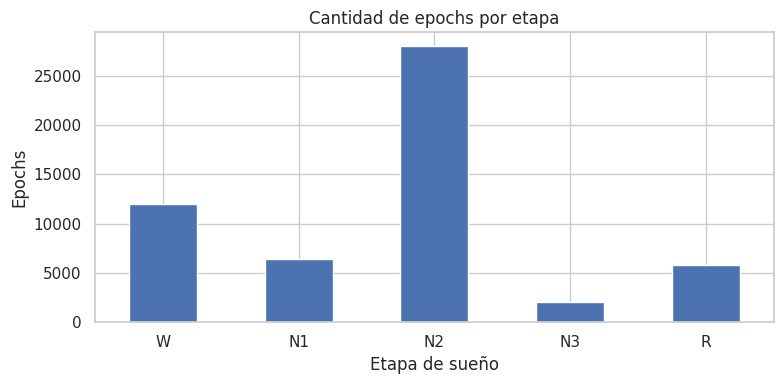

COBERTURA DE LAS CARACTERÍSTICAS POR ETAPA


,caracteristica,Sleep_Stage,epochs_con_valor,epochs_totales,pacientes,muestras_faltantes_pct
0,HR_median,W,12047,12047,73,0.0
1,HR_median,N1,6389,6389,73,0.0
2,HR_median,N2,28020,28020,73,0.0
3,HR_median,N3,2059,2059,35,0.0
4,HR_median,R,5852,5852,61,0.0
5,TEMP_median,W,12047,12047,73,0.0
6,TEMP_median,N1,6389,6389,73,0.0
7,TEMP_median,N2,28020,28020,73,0.0
8,TEMP_median,N3,2059,2059,35,0.0
9,TEMP_median,R,5852,5852,61,0.0


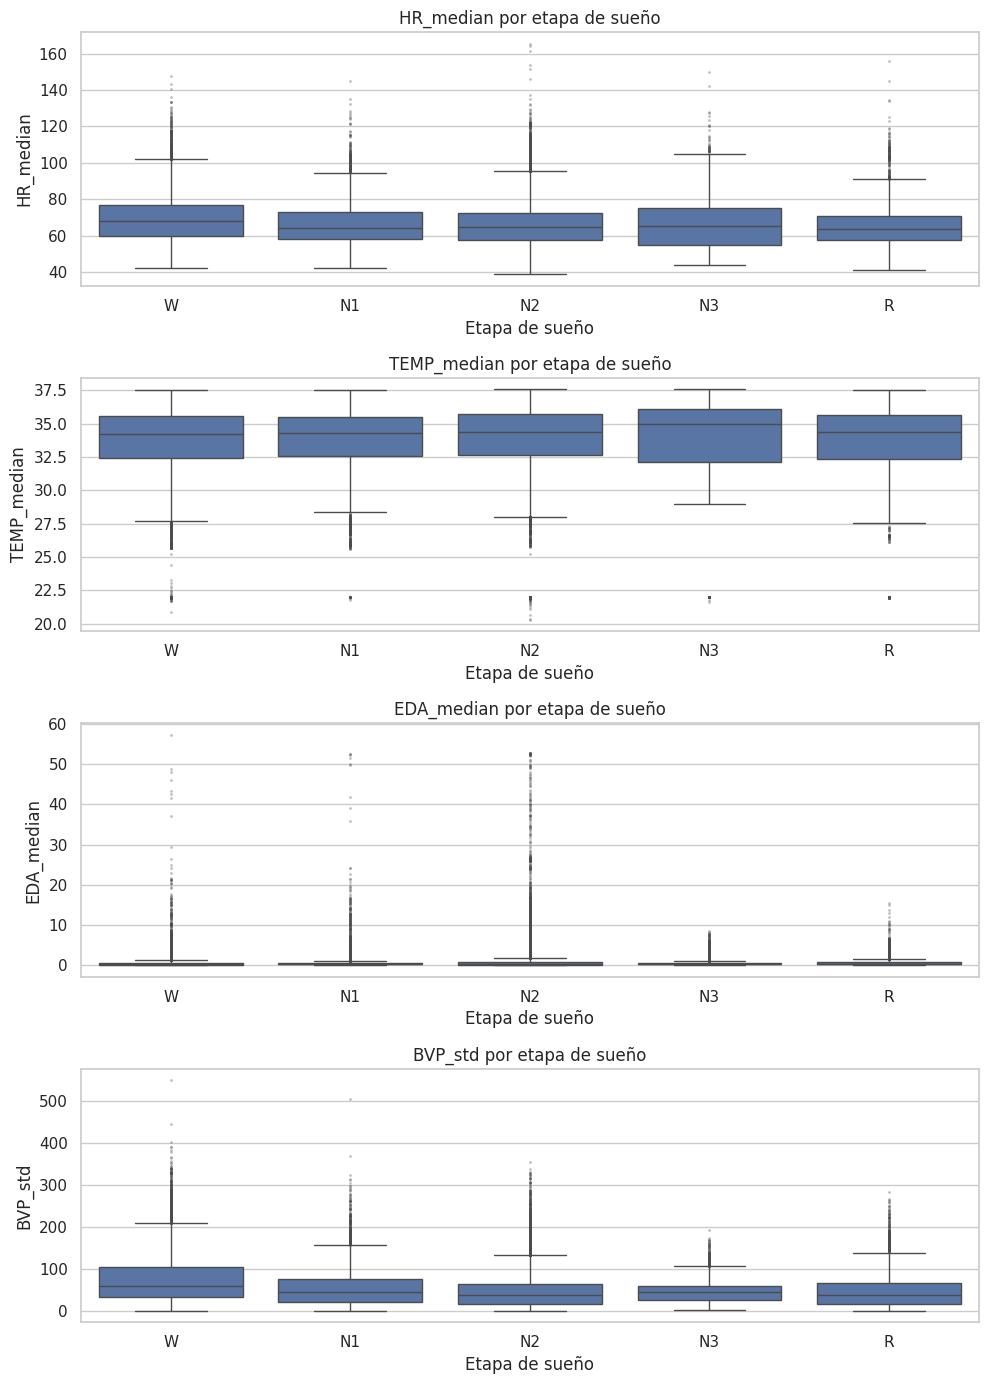

Cada observación es un epoch. Las cajas resumen datos agrupados de todos los pacientes; no representan al paciente típico. Los puntos fuera de los bigotes son candidatos estadísticos; no se eliminaron del dataset. Revisar patrones dudosos por paciente.


In [55]:
# 3.3. Comparación global por etapa de sueño
orden_etapas = ["W", "N1", "N2", "N3", "R"]

if "df_epochs_all" not in globals() or df_epochs_all.empty:
    raise ValueError("Falta df_epochs_all. Ejecutar primero la sección 3.1.")

columnas_requeridas = {
    "patient_id", "epoch", "Sleep_Stage", "porcentaje_pureza"
}
faltantes = columnas_requeridas.difference(df_epochs_all.columns)
if faltantes:
    raise ValueError(f"Faltan columnas: {sorted(faltantes)}")

if df_epochs_all.duplicated(["patient_id", "epoch"]).any():
    raise ValueError("Hay claves patient_id/epoch duplicadas.")

if not df_epochs_all["Sleep_Stage"].isin(orden_etapas).all():
    raise ValueError("Hay etiquetas de sueño faltantes o inválidas.")

if not df_epochs_all["porcentaje_pureza"].eq(1.0).all():
    raise ValueError("Hay epochs no puros. Revisarlos antes de comparar.")

conteos_etapa = df_epochs_all["Sleep_Stage"].value_counts().reindex(
    orden_etapas, fill_value=0
)
pacientes_etapa = (
    df_epochs_all.groupby("Sleep_Stage")["patient_id"]
    .nunique()
    .reindex(orden_etapas, fill_value=0)
)
resumen_etapas = pd.DataFrame({
    "epochs": conteos_etapa,
    "porcentaje_epochs": 100 * conteos_etapa / len(df_epochs_all),
    "pacientes": pacientes_etapa,
})
resumen_etapas.index.name = "Sleep_Stage"

print("COBERTURA GLOBAL POR ETAPA")
display(resumen_etapas.round(2))

ax = conteos_etapa.plot.bar(figsize=(8, 4), rot=0)
ax.set_title("Cantidad de epochs por etapa")
ax.set_xlabel("Etapa de sueño")
ax.set_ylabel("Epochs")
plt.tight_layout()
plt.show()

caracteristicas_propuestas = [
    "HR_median", "TEMP_median", "EDA_median", "BVP_std"
]
caracteristicas = [
    col for col in caracteristicas_propuestas if col in df_epochs_all.columns
]
no_disponibles = sorted(set(caracteristicas_propuestas) - set(caracteristicas))
if no_disponibles:
    print("Características no disponibles en esta versión:", no_disponibles)
if not caracteristicas:
    raise ValueError("No hay características disponibles para graficar.")

resumen_cobertura = []
for caracteristica in caracteristicas:
    valores_validos = (
        df_epochs_all.groupby("Sleep_Stage")[caracteristica]
        .count()
        .reindex(orden_etapas, fill_value=0)
    )
    señal = caracteristica.rsplit("_", 1)[0]
    columna_faltantes = f"{señal}_missing_frac"

    for etapa in orden_etapas:
        registro = {
            "caracteristica": caracteristica,
            "Sleep_Stage": etapa,
            "epochs_con_valor": int(valores_validos[etapa]),
            "epochs_totales": int(conteos_etapa[etapa]),
            "pacientes": int(pacientes_etapa[etapa]),
        }
        if columna_faltantes in df_epochs_all.columns:
            fraccion = df_epochs_all.loc[
                df_epochs_all["Sleep_Stage"].eq(etapa),
                columna_faltantes,
            ].mean()
            registro["muestras_faltantes_pct"] = 100 * fraccion
        resumen_cobertura.append(registro)

print("COBERTURA DE LAS CARACTERÍSTICAS POR ETAPA")
display(pd.DataFrame(resumen_cobertura).round(2))

fig, axes = plt.subplots(
    len(caracteristicas), 1,
    figsize=(10, 3.5 * len(caracteristicas)),
    squeeze=False,
)
for fila, caracteristica in enumerate(caracteristicas):
    ax = axes[fila, 0]
    sns.boxplot(
        data=df_epochs_all,
        x="Sleep_Stage",
        y=caracteristica,
        order=orden_etapas,
        showfliers=True,
        flierprops={"marker": ".", "markersize": 2, "alpha": 0.35},
        ax=ax,
    )
    ax.set_title(f"{caracteristica} por etapa de sueño")
    ax.set_xlabel("Etapa de sueño")
    ax.set_ylabel(caracteristica)

plt.tight_layout()
plt.show()

print(
    "Cada observación es un epoch. Las cajas resumen datos agrupados "
    "de todos los pacientes; no representan al paciente típico. "
    "Los puntos fuera de los bigotes son candidatos estadísticos; "
    "no se eliminaron del dataset. Revisar patrones dudosos por paciente."
)

## 3.3.1. Revisión exploratoria de valores atípicos

Se marcan valores alejados del rango intercuartílico **global** (1,5 × IQR) en características de wearable y PSG. Para HR, TEMP y EDA se priorizan medianas por epoch; para BVP, dispersión por epoch. Es una regla descriptiva, no un límite fisiológico ni una limpieza. Los límites y extremos se muestran con ocho cifras significativas para que las señales PSG pequeñas no parezcan cero por redondeo.

El resumen por variable informa cuántos epochs se marcan. La vista por paciente permite detectar si los casos se concentran en algunas personas; los tramos consecutivos muestran persistencia temporal. Los cinco casos principales **de cada variable** evitan que una señal con IQR diminuto, como EDA, monopolice la inspección. La distancia en IQR sirve para ordenar casos dentro de una variable, no para comparar gravedad entre señales.

**Los puntos de las cajas de 3.3 y esta tabla no tienen exactamente el mismo criterio:** cada caja calcula sus cuartiles dentro de una etapa, mientras que aquí el IQR se calcula con todos los epochs de la variable. Una diferencia real entre etapas puede quedar marcada por uno de los criterios y no por el otro. Ninguno demuestra error de medición.

La lista de casos conserva la fracción de muestras faltantes y los valores de epochs vecinos contiguos del mismo paciente. Se revisan características agregadas por epoch; los picos breves de la señal cruda requieren una inspección adicional. No se modifica df_epochs_all; cualquier recorte, exclusión o imputación requiere evidencia y una decisión posterior documentada en el ADR 0005.


In [56]:
# 3.3.1. Candidatos atípicos: marcas descriptivas, sin cambiar el dataset
variables_revision = [
    "HR_median", "HR_std", "TEMP_median", "EDA_median", "EDA_std",
    "BVP_std", "ACC_X_std", "ACC_Y_std", "ACC_Z_std",
] + [f"{senal}_std" for senal in psg_cols]
variables_revision = list(dict.fromkeys(
    col for col in variables_revision if col in df_epochs_all.columns
))
if not variables_revision:
    raise ValueError("No hay características disponibles para revisar atípicos.")

base_revision = df_epochs_all.sort_values(["patient_id", "epoch"])
resumen_atipicos = []
resumen_atipicos_etapa = []
resumen_atipicos_paciente = []
casos_atipicos = []

for variable in variables_revision:
    valores = pd.to_numeric(base_revision[variable], errors="coerce")
    validos = valores.notna() & np.isfinite(valores)
    fila = {
        "variable": variable,
        "epochs_validos": int(validos.sum()),
        "epochs_sin_valor_finito": int((~validos).sum()),
    }
    if validos.sum() < 4:
        fila.update({"criterio": "insuficientes datos", "epochs_marcados": 0})
        resumen_atipicos.append(fila)
        continue

    q1, q3 = valores.loc[validos].quantile([0.25, 0.75])
    iqr = q3 - q1
    if not np.isfinite(iqr) or iqr == 0:
        fila.update({"criterio": "IQR nulo", "epochs_marcados": 0})
        resumen_atipicos.append(fila)
        continue

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    marcados = validos & (
        (valores < limite_inferior) | (valores > limite_superior)
    )
    fila.update({
        "criterio": "1,5 × IQR global",
        "minimo": valores.loc[validos].min(),
        "p01": valores.loc[validos].quantile(0.01),
        "mediana": valores.loc[validos].median(),
        "p99": valores.loc[validos].quantile(0.99),
        "maximo": valores.loc[validos].max(),
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "epochs_marcados": int(marcados.sum()),
        "porcentaje_validos": 100 * marcados.sum() / validos.sum(),
        "pacientes_marcados": base_revision.loc[marcados, "patient_id"].nunique(),
    })
    resumen_atipicos.append(fila)

    por_paciente = (
        base_revision[["patient_id"]]
        .assign(epoch_valido=validos.astype(int), epoch_marcado=marcados.astype(int))
        .groupby("patient_id", sort=True)
        .sum()
    )
    por_paciente["variable"] = variable
    por_paciente["porcentaje_marcados"] = (
        100 * por_paciente["epoch_marcado"]
        / por_paciente["epoch_valido"].replace(0, np.nan)
    )
    resumen_atipicos_paciente.append(por_paciente.reset_index())

    for etapa in ["W", "N1", "N2", "N3", "R"]:
        en_etapa = base_revision["Sleep_Stage"].eq(etapa)
        n_validos = int((validos & en_etapa).sum())
        n_marcados = int((marcados & en_etapa).sum())
        resumen_atipicos_etapa.append({
            "variable": variable, "Sleep_Stage": etapa,
            "epochs_validos": n_validos,
            "epochs_marcados": n_marcados,
            "porcentaje_validos": 100 * n_marcados / n_validos if n_validos else np.nan,
        })

    if not marcados.any():
        continue
    casos = base_revision.loc[
        marcados, ["patient_id", "epoch", "Sleep_Stage"]
    ].copy()
    casos["variable"] = variable
    casos["valor"] = valores.loc[marcados]
    casos["limite_inferior"] = limite_inferior
    casos["limite_superior"] = limite_superior
    casos["distancia_iqr"] = np.maximum(
        limite_inferior - casos["valor"],
        casos["valor"] - limite_superior,
    ) / iqr

    faltantes_col = variable.rsplit("_", 1)[0] + "_missing_frac"
    if faltantes_col in base_revision.columns:
        casos["fraccion_muestras_faltantes"] = base_revision.loc[
            marcados, faltantes_col
        ]

    epochs = base_revision["epoch"]
    grupos = base_revision["patient_id"]
    anterior = valores.groupby(grupos).shift(1).where(
        epochs.sub(epochs.groupby(grupos).shift(1)).eq(1)
    )
    siguiente = valores.groupby(grupos).shift(-1).where(
        epochs.groupby(grupos).shift(-1).sub(epochs).eq(1)
    )
    casos["valor_epoch_anterior"] = anterior.loc[marcados]
    casos["valor_epoch_siguiente"] = siguiente.loc[marcados]
    casos_atipicos.append(casos)

resumen_atipicos = pd.DataFrame(resumen_atipicos)
resumen_atipicos_etapa = pd.DataFrame(resumen_atipicos_etapa)
resumen_atipicos_paciente = (
    pd.concat(resumen_atipicos_paciente, ignore_index=True)
    if resumen_atipicos_paciente else pd.DataFrame()
)
candidatos_atipicos = (
    pd.concat(casos_atipicos, ignore_index=True)
    if casos_atipicos else pd.DataFrame()
)

if candidatos_atipicos.empty:
    tramos_atipicos = pd.DataFrame()
else:
    ordenados = candidatos_atipicos.sort_values(
        ["variable", "patient_id", "epoch"]
    ).copy()
    claves = [ordenados["variable"], ordenados["patient_id"]]
    nuevo_tramo = ordenados.groupby(
        ["variable", "patient_id"]
    )["epoch"].diff().ne(1)
    ordenados["tramo_id"] = nuevo_tramo.groupby(claves).cumsum()
    tramos_atipicos = (
        ordenados.groupby(["variable", "patient_id", "tramo_id"], sort=False)
        .agg(
            epoch_inicial=("epoch", "min"),
            epoch_final=("epoch", "max"),
            epochs_marcados=("epoch", "size"),
            distancia_iqr_max=("distancia_iqr", "max"),
        )
        .reset_index()
        .drop(columns="tramo_id")
    )
    tramos_atipicos["duracion_minutos"] = tramos_atipicos["epochs_marcados"] * 0.5

# Ocho cifras significativas: no confundir valores pequeños con cero.
with pd.option_context("display.float_format", lambda x: f"{x:.8g}"):
    print("RESUMEN DE CANDIDATOS POR VARIABLE (IQR global)")
    display(resumen_atipicos.sort_values("epochs_marcados", ascending=False))

    print("CANDIDATOS POR ETAPA (porcentaje sobre epochs válidos de esa etapa)")
    if resumen_atipicos_etapa.empty:
        display("Sin variables con criterio IQR aplicable")
    else:
        display(resumen_atipicos_etapa.loc[
            resumen_atipicos_etapa["epochs_marcados"].gt(0)
        ].sort_values("porcentaje_validos", ascending=False).head(30))

    print("PACIENTES MÁS AFECTADOS POR VARIABLE (tres por variable)")
    if resumen_atipicos_paciente.empty:
        display("Sin variables con criterio IQR aplicable")
    else:
        principales_paciente = (
            resumen_atipicos_paciente.loc[
                resumen_atipicos_paciente["epoch_marcado"].gt(0)
            ]
            .sort_values(
                ["variable", "epoch_marcado", "porcentaje_marcados"],
                ascending=[True, False, False],
            )
            .groupby("variable", sort=False)
            .head(3)
        )
        display(principales_paciente if not principales_paciente.empty
                else "Sin candidatos")

    print("TRAMOS CONSECUTIVOS MÁS LARGOS (tres por variable)")
    if tramos_atipicos.empty:
        display("Sin tramos marcados")
    else:
        principales_tramos = (
            tramos_atipicos.sort_values(
                ["variable", "epochs_marcados", "distancia_iqr_max"],
                ascending=[True, False, False],
            )
            .groupby("variable", sort=False)
            .head(3)
        )
        display(principales_tramos)

    print("CINCO CASOS MÁS ALEJADOS POR VARIABLE; NO ELIMINADOS")
    if candidatos_atipicos.empty:
        display("Sin candidatos")
    else:
        principales_casos = (
            candidatos_atipicos.sort_values(
                ["variable", "distancia_iqr"],
                ascending=[True, False],
            )
            .groupby("variable", sort=False)
            .head(5)
        )
        display(principales_casos)

print(
    "Las tablas completas están en resumen_atipicos_paciente, "
    "tramos_atipicos y candidatos_atipicos. Ningún dato fue modificado."
)


RESUMEN DE CANDIDATOS POR VARIABLE (IQR global)


,variable,epochs_validos,epochs_sin_valor_finito,criterio,minimo,p01,mediana,p99,maximo,limite_inferior,limite_superior,epochs_marcados,porcentaje_validos,pacientes_marcados
4,EDA_std,54367,0,"1,5 × IQR global",0,0.00078681646,0.001665473,0.37249475,16.266735,-0.0051226778,0.01160969,9499,17.471996,73
6,ACC_X_std,54367,0,"1,5 × IQR global",0,0,0.36727273,28.283555,56.15176,-0.40405311,1.045787,8437,15.518605,73
21,SNORE_std,54367,0,"1,5 × IQR global",0,2.7694028e-07,3.2648197e-06,0.00029320354,0.00093228329,-2.3081604e-05,4.1365365e-05,8223,15.124984,60
3,EDA_median,54367,0,"1,5 × IQR global",0,0.0038419999,0.328228,10.444301,57.267944,-0.63330249,1.5098935,8208,15.097394,32
20,RAT_std,54367,0,"1,5 × IQR global",0,3.4242516e-07,2.1110482e-06,0.00015976988,0.0005700367,-6.9155146e-06,1.4181644e-05,8073,14.849081,73
8,ACC_Z_std,54367,0,"1,5 × IQR global",0,0,0.36315766,24.799875,54.213184,-0.29355592,0.9480698,7959,14.639395,73
19,LAT_std,54367,0,"1,5 × IQR global",0,4.2192861e-07,2.0270602e-06,0.00013674474,0.0006394565,-8.0638717e-06,1.6023686e-05,6698,12.319974,73
7,ACC_Y_std,54367,0,"1,5 × IQR global",0,0,0.29232219,22.587764,55.904839,-0.46020705,1.0279907,6409,11.788401,73
11,O2-M1_std,54367,0,"1,5 × IQR global",0,2.3156387e-06,9.4185425e-06,0.00017015993,0.00078199379,-4.0307633e-06,2.500861e-05,5627,10.350029,73
16,E1_std,54367,0,"1,5 × IQR global",0,4.1044111e-06,1.1178524e-05,0.00016693852,0.0013624575,-6.5771465e-06,3.1548188e-05,5109,9.3972447,73


CANDIDATOS POR ETAPA (porcentaje sobre epochs válidos de esa etapa)


,variable,Sleep_Stage,epochs_validos,epochs_marcados,porcentaje_validos
30,ACC_X_std,W,12047,4992,41.437702
40,ACC_Z_std,W,12047,4885,40.549514
35,ACC_Y_std,W,12047,4326,35.909355
100,RAT_std,W,12047,3599,29.874658
53,F4-M1_std,N3,2059,590,28.654687
20,EDA_std,W,12047,3287,27.284801
95,LAT_std,W,12047,3284,27.259899
68,T3 - CZ_std,N3,2059,535,25.983487
48,C4-M1_std,N3,2059,510,24.769305
73,CZ - T4_std,N3,2059,498,24.186498


PACIENTES MÁS AFECTADOS POR VARIABLE (tres por variable)


...

TRAMOS CONSECUTIVOS MÁS LARGOS (tres por variable)


,variable,patient_id,epoch_inicial,epoch_final,epochs_marcados,distancia_iqr_max,duracion_minutos
854,ABDOMEN_std,84,373,686,314,3.8149524,157
876,ABDOMEN_std,86,0,204,205,5.3371086,102.5
851,ABDOMEN_std,84,142,339,198,5.2263875,99
3854,ACC_X_std,59,286,390,105,56.080704,52.5
3270,ACC_X_std,47,220,297,78,120.37787,39
...,...,...,...,...,...,...,...
45525,TEMP_median,21,402,725,324,0.66772175,162
45518,TEMP_median,16,158,368,211,0.68670893,105.5
45537,THORAX_std,2,16,213,198,2.675163,99
46263,THORAX_std,42,182,357,176,3.700114,88


CINCO CASOS MÁS ALEJADOS POR VARIABLE; NO ELIMINADOS


,patient_id,epoch,Sleep_Stage,variable,valor,limite_inferior,limite_superior,distancia_iqr,fraccion_muestras_faltantes,valor_epoch_anterior,valor_epoch_siguiente
129475,98,270,W,ABDOMEN_std,0.0019122823,-0.00023270278,0.00057300469,6.648952,0,0.00010812728,0.00078210648
129434,98,226,N2,ABDOMEN_std,0.0019039599,-0.00023270278,0.00057300469,6.607635,0,0.0012509644,0.001626158
129447,98,239,N1,ABDOMEN_std,0.0018603088,-0.00023270278,0.00057300469,6.3909254,0,0.0016077565,0.0018202974
129448,98,240,W,ABDOMEN_std,0.0018202974,-0.00023270278,0.00057300469,6.192286,0,0.0018603088,0.0017219362
129464,98,256,N2,ABDOMEN_std,0.0018181343,-0.00023270278,0.00057300469,6.1815467,0,0.0013942909,0.0017369717
...,...,...,...,...,...,...,...,...,...,...,...
123005,3,757,W,THORAX_std,0.0021357713,-0.00030682351,0.00062921491,6.4380107,0,0.00205792,0.001638525
122999,3,562,N2,THORAX_std,0.0020949799,-0.00030682351,0.00062921491,6.2636957,0,0.0014788103,0.0017769999
123004,3,756,W,THORAX_std,0.00205792,-0.00030682351,0.00062921491,6.1053267,0,0.0019937134,0.0021357713
123003,3,755,W,THORAX_std,0.0019937134,-0.00030682351,0.00062921491,5.8309507,0,0.00087305706,0.00205792


Las tablas completas están en resumen_atipicos_paciente, tramos_atipicos y candidatos_atipicos. Ningún dato fue modificado.


### 3.3.2. Distribuciones de predictores prioritarios

La primera vista usa **una fila por epoch de 30 segundos**: medianas de HR, temperatura y EDA; desviaciones estándar de BVP, aceleración y un canal PSG. Una mediana resume el nivel central y resiste picos aislados; una desviación estándar resume variabilidad, no el valor instantáneo. El histograma muestra la distribución entre epochs y la caja por etapa muestra solapamientos. La tabla informa cobertura por etapa. Se ocultan los puntos extremos en esta vista para que las cajas sean legibles; 3.3 y 3.3.1 permiten inspeccionarlos.

La segunda vista, agregada abajo, muestra **filas crudas del CSV a 100 Hz de un solo paciente** ya cargado en 1.2: cajas de HR, TEMP, EDA, BVP y ACC_X, cuantiles calculados con todas sus muestras válidas y una ventana temporal alrededor de su máximo EDA. Los sensores pueden tener frecuencias nativas distintas y valores repetidos en el CSV sincronizado. Para dibujar las cajas se limita la cantidad de puntos por etapa, no para calcular los cuantiles ni para transformar el dataset. Una muestra cruda no equivale a un epoch independiente: las muestras cercanas están autocorrelacionadas y comparten la misma etiqueta de 30 segundos. Esta vista permite revisar amplitud, picos y ruido, pero **no representa por sí sola a los 73 pacientes** ni sustituye una auditoría por paciente. Confirmar unidades y escalas de los sensores antes de fijar umbrales fisiológicos.

Una distribución sesgada no exige recorte ni normalidad. `Sleep_Stage` es categórica y su desbalance se conserva en el ETL. La posible ponderación de clases, el escalado y los algoritmos se dejan para la sección 4, después de acordar el escenario de uso.

COBERTURA POR VARIABLE Y ETAPA


,variable,Sleep_Stage,epochs_con_valor,epochs_totales,cobertura_pct,pacientes_con_valor
0,HR_median,W,12047,12047,100.0,73
1,HR_median,N1,6389,6389,100.0,73
2,HR_median,N2,28020,28020,100.0,73
3,HR_median,N3,2059,2059,100.0,35
4,HR_median,R,5852,5852,100.0,61
5,TEMP_median,W,12047,12047,100.0,73
6,TEMP_median,N1,6389,6389,100.0,73
7,TEMP_median,N2,28020,28020,100.0,73
8,TEMP_median,N3,2059,2059,100.0,35
9,TEMP_median,R,5852,5852,100.0,61


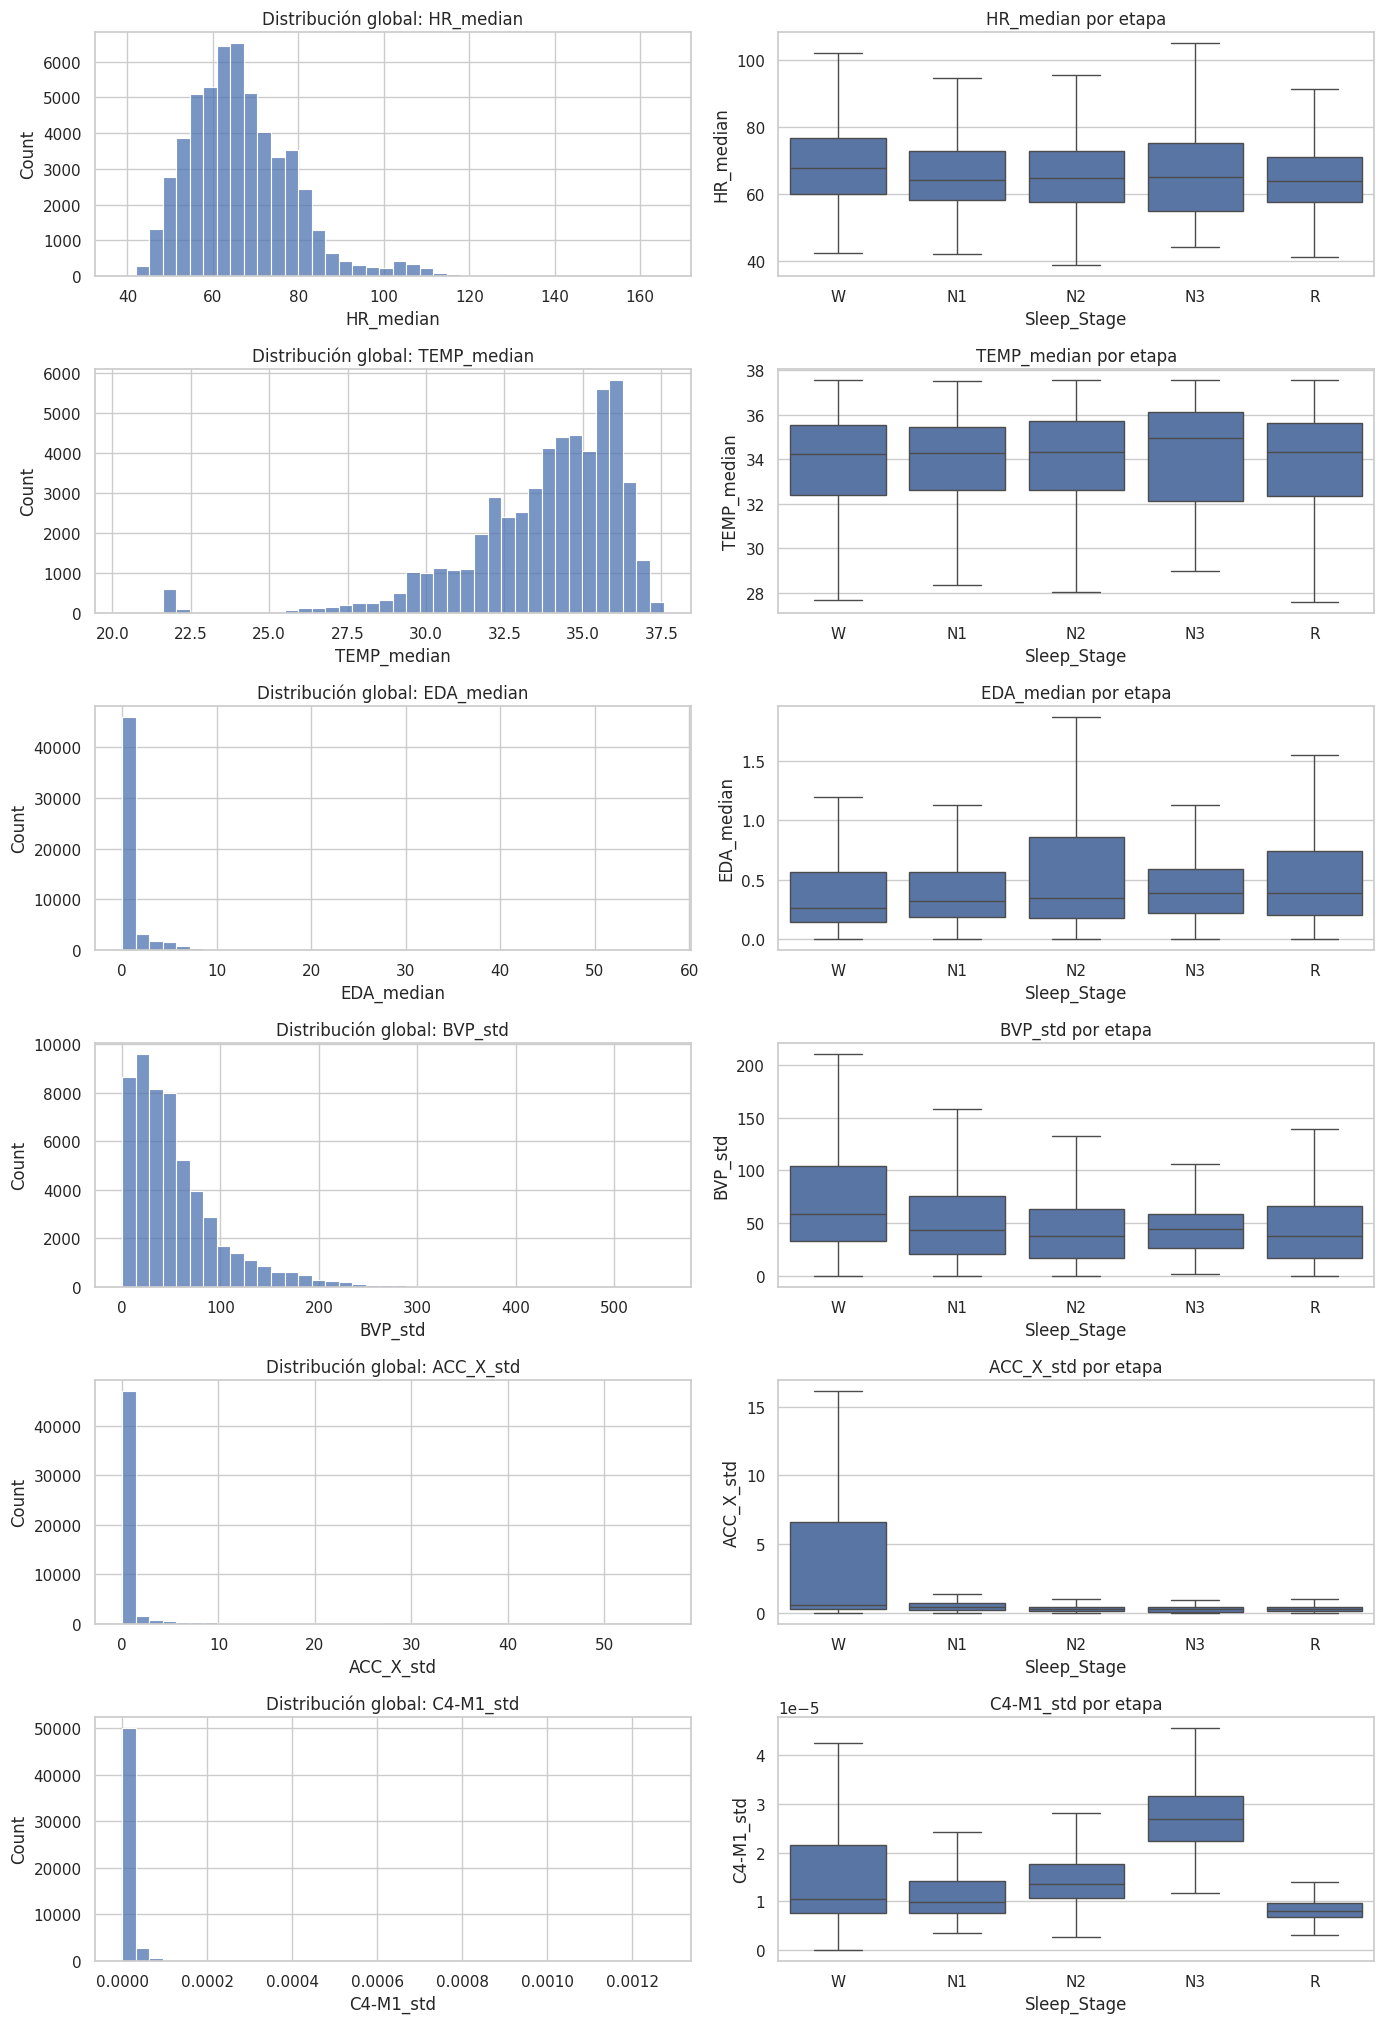

Los gráficos son descriptivos. No se transformaron predictores ni se balancearon etapas. Confirmar unidades antes de fijar umbrales.


In [57]:
# 3.3.2. Distribuciones de predictores prioritarios
candidatas_distribucion = [
    "HR_median", "TEMP_median", "EDA_median", "BVP_std",
    "ACC_X_std", "C4-M1_std", "SAO2_mean",
]
variables_distribucion = [c for c in candidatas_distribucion
                          if c in df_epochs_all.columns]
if not variables_distribucion:
    raise ValueError("No hay predictores prioritarios disponibles.")

filas_cobertura = []
for variable in variables_distribucion:
    valores = pd.to_numeric(df_epochs_all[variable], errors="coerce")
    finitos = valores.notna() & np.isfinite(valores)
    for etapa in ["W", "N1", "N2", "N3", "R"]:
        en_etapa = df_epochs_all["Sleep_Stage"].eq(etapa)
        validos_etapa = finitos & en_etapa
        total_etapa = int(en_etapa.sum())
        filas_cobertura.append({
            "variable": variable, "Sleep_Stage": etapa,
            "epochs_con_valor": int(validos_etapa.sum()),
            "epochs_totales": total_etapa,
            "cobertura_pct": 100 * validos_etapa.sum() / total_etapa
                             if total_etapa else np.nan,
            "pacientes_con_valor": df_epochs_all.loc[
                validos_etapa, "patient_id"
            ].nunique(),
        })
resumen_distribuciones = pd.DataFrame(filas_cobertura)
print("COBERTURA POR VARIABLE Y ETAPA")
display(resumen_distribuciones.round(2))

fig, axes = plt.subplots(
    len(variables_distribucion), 2,
    figsize=(14, 3.4 * len(variables_distribucion)),
    squeeze=False,
)
for fila, variable in enumerate(variables_distribucion):
    valores = pd.to_numeric(df_epochs_all[variable], errors="coerce")
    finitos = valores.notna() & np.isfinite(valores)
    datos_grafico = df_epochs_all.loc[
        finitos, ["Sleep_Stage", variable]
    ]
    if datos_grafico.empty:
        axes[fila, 0].set_title(f"{variable}: sin valores finitos")
        axes[fila, 1].set_visible(False)
        continue
    sns.histplot(data=datos_grafico, x=variable, bins=40,
                 ax=axes[fila, 0])
    axes[fila, 0].set_title(f"Distribución global: {variable}")
    sns.boxplot(data=datos_grafico, x="Sleep_Stage", y=variable,
                order=["W", "N1", "N2", "N3", "R"],
                showfliers=False, ax=axes[fila, 1])
    axes[fila, 1].set_title(f"{variable} por etapa")
plt.tight_layout()
plt.show()
print(
    "Los gráficos son descriptivos. No se transformaron predictores ni "
    "se balancearon etapas. Confirmar unidades antes de fijar umbrales."
)


#### Vista cruda de señales (control visual de un paciente)

Se reutiliza `df_sample_eda` de 1.2, sin volver a leer los archivos. Las cajas usan como máximo 1.500 muestras crudas por etapa con semilla fija para que la figura sea legible; la tabla de cuantiles y recuentos usa **todas** las muestras válidas de ese paciente. BVP y ACC_X son señales oscilatorias/con signo: comparar sus cajas crudas con `BVP_std` o `ACC_X_std` de un epoch sería mezclar magnitudes distintas. La ventana de 60 segundos alrededor del máximo EDA sirve para revisar contexto, no para declarar un artefacto automáticamente. Los gráficos no editan `df_sample_eda` ni `df_epochs_all`.


In [ ]:
# 3.3.2. Vista cruda a 100 Hz: paciente de muestra ya cargado en 1.2
if "df_sample_eda" not in globals():
    raise ValueError("Ejecutar primero 1.2 para cargar el paciente crudo de muestra.")
etapas_crudas = ["W", "N1", "N2", "N3", "R"]
senales_crudas = ["HR", "TEMP", "EDA", "BVP", "ACC_X"]
requeridas_crudas = {"Sleep_Stage", "TIMESTAMP", *senales_crudas}
faltantes_crudas = requeridas_crudas - set(df_sample_eda.columns)
if faltantes_crudas:
    raise ValueError(f"Faltan columnas crudas: {sorted(faltantes_crudas)}")

paciente_crudo = extract_patient_id(sample_file)
print(f"Vista cruda: S{paciente_crudo:03d}, un paciente, no toda la cohorte.")
filas_crudas = []
muestras_por_etapa = []
for etapa in etapas_crudas:
    bloque = df_sample_eda.loc[df_sample_eda["Sleep_Stage"].eq(etapa)]
    if bloque.empty:
        continue
    muestra = bloque.sample(n=min(1500, len(bloque)), random_state=42)
    muestras_por_etapa.append(muestra.loc[:, ["Sleep_Stage", *senales_crudas]])
    for senal in senales_crudas:
        valores = pd.to_numeric(bloque[senal], errors="coerce")
        valores = valores[np.isfinite(valores)]
        if valores.empty:
            continue
        filas_crudas.append({
            "paciente": paciente_crudo, "etapa": etapa, "senal": senal,
            "muestras_finitas": len(valores), "minimo": valores.min(),
            "p01": valores.quantile(0.01), "mediana": valores.median(),
            "p99": valores.quantile(0.99), "maximo": valores.max(),
        })
if not muestras_por_etapa:
    raise ValueError("El paciente crudo no contiene etapas válidas para graficar.")
resumen_crudo_paciente = pd.DataFrame(filas_crudas)
print("Cuantiles de TODAS las muestras válidas del paciente:")
display(resumen_crudo_paciente.round(4))

muestra_cruda_grafico = pd.concat(muestras_por_etapa, ignore_index=True).copy()
for senal in senales_crudas:
    muestra_cruda_grafico[senal] = pd.to_numeric(
        muestra_cruda_grafico[senal], errors="coerce"
    )
fig, axes = plt.subplots(len(senales_crudas), 1, figsize=(13, 3.2 * len(senales_crudas)))
for ax, senal in zip(axes, senales_crudas):
    sns.boxplot(data=muestra_cruda_grafico, x="Sleep_Stage", y=senal,
                order=etapas_crudas, showfliers=True, fliersize=1.5, ax=ax)
    ax.set_title(f"{senal} crudo por etapa — S{paciente_crudo:03d} (hasta 1.500 muestras/etapa)")
    ax.set_xlabel("Etapa anotada")
plt.tight_layout()
plt.show()

eda_cruda = pd.to_numeric(df_sample_eda["EDA"], errors="coerce")
tiempo_crudo = pd.to_numeric(df_sample_eda["TIMESTAMP"], errors="coerce")
if eda_cruda.notna().any() and tiempo_crudo.notna().any():
    indice_maximo_eda = eda_cruda.idxmax()
    tiempo_centro = tiempo_crudo.loc[indice_maximo_eda]
    ventana_cruda = df_sample_eda.loc[
        tiempo_crudo.between(tiempo_centro - 30, tiempo_centro + 30),
        ["TIMESTAMP", "EDA", "BVP", "ACC_X"],
    ]
    fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
    for ax, senal in zip(axes, ["EDA", "BVP", "ACC_X"]):
        ax.plot(pd.to_numeric(ventana_cruda["TIMESTAMP"], errors="coerce") - tiempo_centro,
                pd.to_numeric(ventana_cruda[senal], errors="coerce"), lw=0.8)
        ax.axvline(0, color="crimson", linestyle="--", alpha=0.7)
        ax.set_ylabel(senal)
    axes[-1].set_xlabel("Segundos respecto del máximo crudo de EDA")
    fig.suptitle(f"Contexto crudo de S{paciente_crudo:03d}; no se infiere causa del pico")
    plt.tight_layout()
    plt.show()


### 3.3.3. EDA en todos los pacientes incluidos

La sección 2.6.4 usa máximos crudos de todos los archivos auditados, pero profundiza solo en S002, S004 y S057. Aquí se usan todos los epochs conservados en el ETL: se comparan percentiles de EDA por paciente y su evolución temporal sin releer los CSV de 100 Hz. Esto excluye pacientes y epochs rechazados por el ETL; S097 no aparece.

La distancia entre la mediana y el percentil 95 señala episodios elevados dentro del paciente; valores altos en ambos sugieren un nivel basal alto. El mapa temporal muestra si el aumento es localizado o sostenido. La escala log(1 + EDA) se usa solo para visualizar y no transforma el dataset. Un resumen de 30 segundos puede ocultar picos más breves: contrastar S004 y S057 con las curvas crudas de 2.6.4 antes de decidir una limpieza.


Archivos fuente: 74 | Pacientes incluidos en ETL: 73
Epochs sin EDA finita: 0 | Con EDA mediana negativa (revisar): 0
EDA POR PACIENTE: TODOS LOS INCLUIDOS


,patient_id,epochs_con_eda,mediana,p95,p99,maximo_epoch,epochs_totales,cobertura_pct,estado_revision
0,46,716,0.004,0.005,0.005,0.024000,716,100.0,Exploratorio
1,55,769,0.050,0.575,1.190,1.905000,769,100.0,Exploratorio
2,50,696,0.074,0.925,4.296,6.392000,696,100.0,Exploratorio
3,51,754,0.086,0.109,0.145,0.195000,754,100.0,Exploratorio
4,96,762,0.088,0.410,0.559,0.632000,762,100.0,Exploratorio
5,17,770,0.102,0.167,0.181,0.241000,770,100.0,Exploratorio
6,18,815,0.108,0.140,0.151,0.172000,815,100.0,Exploratorio
7,23,806,0.115,0.255,0.825,0.994000,806,100.0,Exploratorio
8,66,640,0.126,0.333,0.680,1.020000,640,100.0,Exploratorio
9,2,652,0.140,0.888,1.342,1.420000,652,100.0,Exploratorio


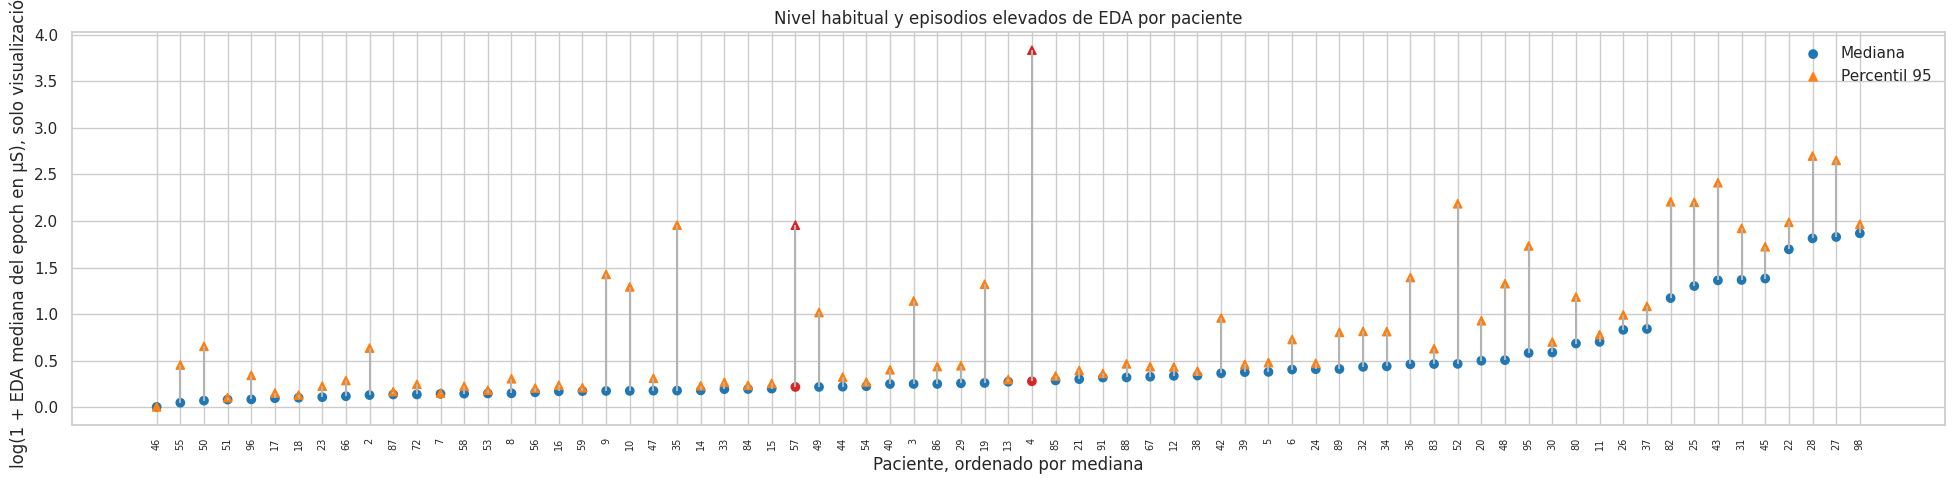

Epochs con EDA pero tiempo no graficable: 0


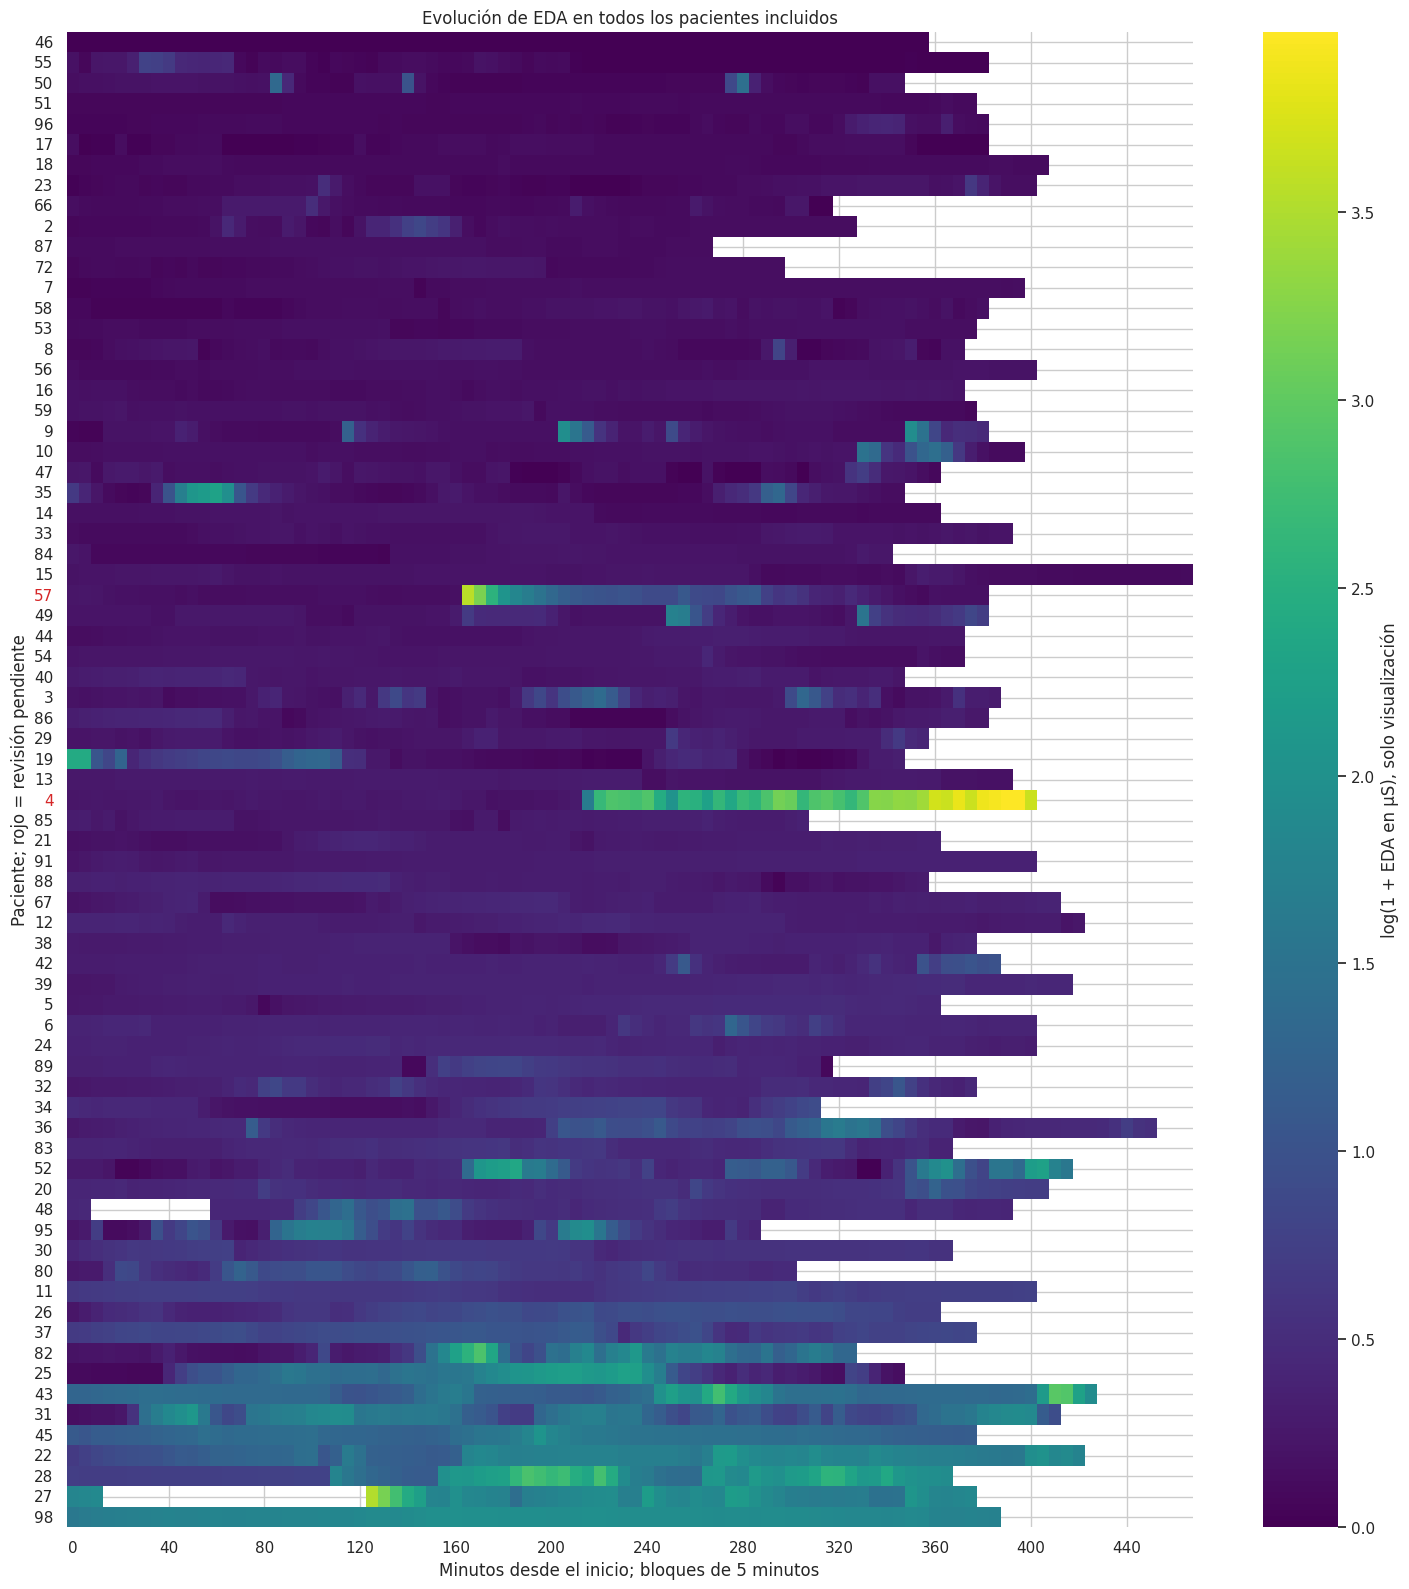

Gráficos descriptivos: no se recortó ni transformó el dataset.


In [58]:
# 3.3.3. Resumen EDA de todos los pacientes incluidos en el ETL
requeridas_eda = ["patient_id", "EDA_median", "tiempo_relativo_segundos"]
if not set(requeridas_eda).issubset(df_epochs_all.columns):
    raise ValueError("Faltan columnas para el análisis global de EDA.")
eda_total = df_epochs_all[requeridas_eda].copy()
for columna in ["EDA_median", "tiempo_relativo_segundos"]:
    eda_total[columna] = pd.to_numeric(eda_total[columna], errors="coerce")
finita = np.isfinite(eda_total["EDA_median"])
negativa = finita & eda_total["EDA_median"].lt(0)
print("Archivos fuente:", len(data_files),"| Pacientes incluidos en ETL:", eda_total["patient_id"].nunique())
print("Epochs sin EDA finita:", int((~finita).sum()),
      "| Con EDA mediana negativa (revisar):", int(negativa.sum()))
eda_valida = eda_total.loc[finita & ~negativa].copy()
if eda_valida.empty:
    raise ValueError("No hay EDA no negativa y finita para graficar.")
resumen_eda_paciente = eda_valida.groupby("patient_id")["EDA_median"].agg(
    epochs_con_eda="size", mediana="median",
    p95=lambda s: s.quantile(0.95), p99=lambda s: s.quantile(0.99),
    maximo_epoch="max",
).reset_index()
resumen_eda_paciente["epochs_totales"] = resumen_eda_paciente["patient_id"].map(
    eda_total.groupby("patient_id").size()
)
resumen_eda_paciente["cobertura_pct"] = (
    100 * resumen_eda_paciente["epochs_con_eda"]
    / resumen_eda_paciente["epochs_totales"]
)
resumen_eda_paciente["estado_revision"] = np.where(
    resumen_eda_paciente["patient_id"].isin([4, 57]),
    "Pendiente de revisión", "Exploratorio",
)
resumen_eda_paciente = resumen_eda_paciente.sort_values("mediana").reset_index(drop=True)
print("EDA POR PACIENTE: TODOS LOS INCLUIDOS")
with pd.option_context("display.max_rows", None):
    display(resumen_eda_paciente.round(3))

x = np.arange(len(resumen_eda_paciente))
marcados = resumen_eda_paciente["patient_id"].isin([4, 57])
fig, ax = plt.subplots(figsize=(max(12, 0.27 * len(x)), 5))
ax.vlines(x, np.log1p(resumen_eda_paciente["mediana"]),
          np.log1p(resumen_eda_paciente["p95"]), color="0.7")
ax.scatter(x, np.log1p(resumen_eda_paciente["mediana"]),
           c=np.where(marcados, "tab:red", "tab:blue"), label="Mediana")
ax.scatter(x, np.log1p(resumen_eda_paciente["p95"]), marker="^",
           c=np.where(marcados, "tab:red", "tab:orange"), label="Percentil 95")
ax.set_xticks(x)
ax.set_xticklabels(resumen_eda_paciente["patient_id"].astype(str), rotation=90, fontsize=7)
ax.set(xlabel="Paciente, ordenado por mediana",
       ylabel="log(1 + EDA mediana del epoch en µS), solo visualización",
       title="Nivel habitual y episodios elevados de EDA por paciente")
ax.legend()
plt.tight_layout()
plt.show()

tiempo_valido = (np.isfinite(eda_valida["tiempo_relativo_segundos"])
                 & eda_valida["tiempo_relativo_segundos"].ge(0))
print("Epochs con EDA pero tiempo no graficable:", int((~tiempo_valido).sum()))
eda_temporal = eda_valida.loc[tiempo_valido].copy()
if not eda_temporal.empty:
    eda_temporal["bloque_5min"] = (
        eda_temporal["tiempo_relativo_segundos"] // 300
    ).astype(int)
    mapa_eda = eda_temporal.groupby(["patient_id", "bloque_5min"])["EDA_median"].median().unstack()
    mapa_eda = mapa_eda.reindex(resumen_eda_paciente["patient_id"])
    fig, ax = plt.subplots(figsize=(15, max(6, 0.22 * len(mapa_eda))))
    sns.heatmap(np.log1p(mapa_eda), ax=ax, cmap="viridis",
                cbar_kws={"label": "log(1 + EDA en µS), solo visualización"})
    paso = max(1, int(np.ceil(len(mapa_eda.columns) / 12)))
    indices = np.arange(0, len(mapa_eda.columns), paso)
    ax.set_xticks(indices + 0.5)
    ax.set_xticklabels((mapa_eda.columns[indices] * 5).astype(int), rotation=0)
    for etiqueta in ax.get_yticklabels():
        if etiqueta.get_text() in {"4", "57"}:
            etiqueta.set_color("tab:red")
    ax.set(xlabel="Minutos desde el inicio; bloques de 5 minutos",
           ylabel="Paciente; rojo = revisión pendiente",
           title="Evolución de EDA en todos los pacientes incluidos")
    plt.tight_layout()
    plt.show()
print("Gráficos descriptivos: no se recortó ni transformó el dataset.")


## 3.4. Asociación entre señales y etapas

Los dos primeros mapas usan Spearman para revisar relaciones **entre predictores**; no miden relación con `Sleep_Stage`. Se eligen resúmenes con interpretación física y se excluyen identificadores, tiempo, anotaciones de apnea y numeraciones artificiales de la etapa. Para HR, EDA y TEMP se usan las medianas por epoch, en coherencia con la sección 3.3; sus medias también existen, pero aquí no se mezclan ambas versiones. Las columnas esperadas de esas tres señales se comprueban explícitamente; otras columnas ausentes se omiten sin inventar valores. Un par con |r| > 0,85 merece revisión de cobertura y redundancia, pero no se elimina automáticamente.

El tercer mapa compara cada etapa frente al resto mediante AUC de rangos. Se usa aquí como descripción univariada de la muestra, no como evaluación de un modelo ni criterio definitivo de selección. La comparación puede estar dominada por pacientes con más epochs; su estabilidad se comprobará después por paciente y fuera de muestra.

**Reejecutar 3.4 tras este cambio:** las salidas guardadas anteriormente pueden corresponder a `*_mean` y no deben interpretarse como resultados de `*_median`.


Cobertura de características incluidas en los mapas


,epochs_con_valor
BVP_std,54367
HR_median,54367
HR_std,54367
EDA_median,54367
EDA_std,54367
TEMP_median,54367
ACC_X_std,54367
ACC_Y_std,54367
ACC_Z_std,54367
C4-M1_std,54367


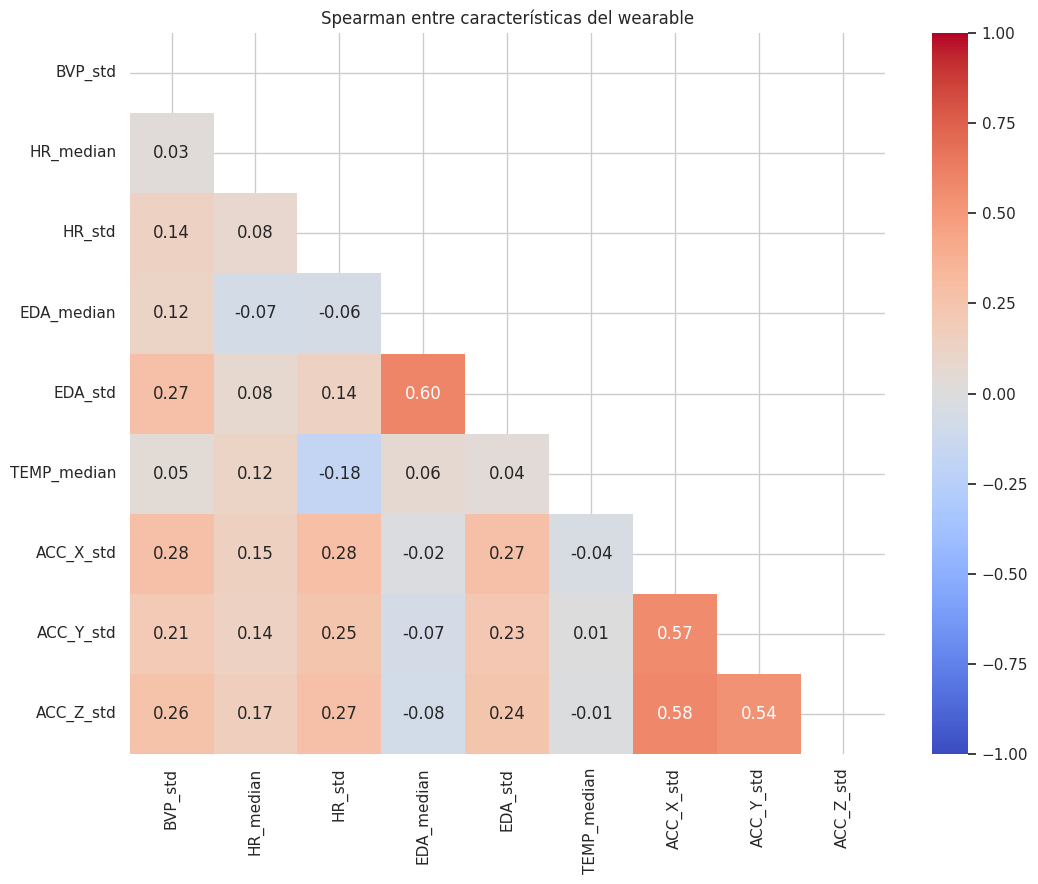

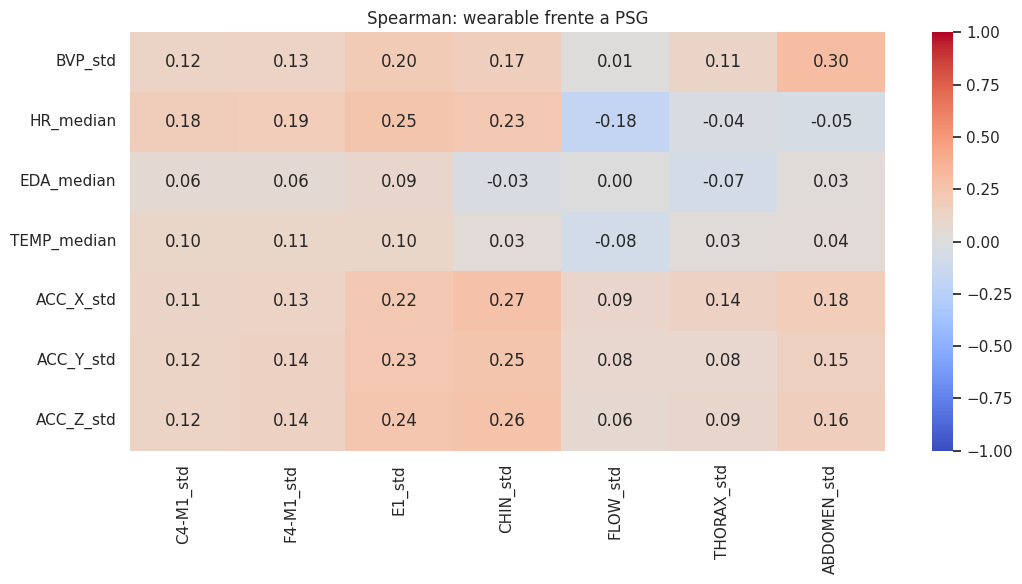

Pares con |Spearman| > 0,85: 6; ninguno se elimina


,variable_1,variable_2,spearman,magnitud
0,C4-M1_std,F4-M1_std,0.934897,0.934897
1,T3 - CZ_std,CZ - T4_std,0.923503,0.923503
2,E1_std,E2_std,0.894712,0.894712
3,C4-M1_std,T3 - CZ_std,0.872791,0.872791
4,C4-M1_std,CZ - T4_std,0.869670,0.869670
5,C4-M1_std,O2-M1_std,0.868792,0.868792


In [59]:
# 3.4.1. Asociaciones entre predictores, sin variable objetivo
if "df_epochs_all" not in globals() or df_epochs_all.empty:
    raise ValueError("Falta df_epochs_all. Ejecutar primero la sección 3.1.")

columnas_centrales = ["HR_median", "EDA_median", "TEMP_median"]
faltantes_centrales = [c for c in columnas_centrales if c not in df_epochs_all.columns]
if faltantes_centrales:
    raise ValueError(f"Faltan columnas esperadas del ETL: {faltantes_centrales}")

wearable_mapa = [c for c in [
    "BVP_std", "HR_median", "HR_std", "EDA_median", "EDA_std",
    "TEMP_median", "ACC_X_std", "ACC_Y_std", "ACC_Z_std",
] if c in df_epochs_all.columns]
psg_mapa = [f"{senal}_std" for senal in psg_cols
            if f"{senal}_std" in df_epochs_all.columns]
caracteristicas_asociacion = wearable_mapa + psg_mapa
if len(caracteristicas_asociacion) < 2:
    raise ValueError("Faltan características para calcular asociaciones.")

print("Cobertura de características incluidas en los mapas")
display(df_epochs_all[caracteristicas_asociacion].notna().sum()
        .rename("epochs_con_valor").to_frame())

if len(wearable_mapa) > 1:
    corr_wearable = df_epochs_all[wearable_mapa].corr(
        method="spearman", min_periods=30
    )
    plt.figure(figsize=(11, 9))
    sns.heatmap(corr_wearable, mask=np.triu(np.ones_like(
        corr_wearable, dtype=bool)), annot=True, fmt=".2f",
        cmap="coolwarm", vmin=-1, vmax=1)
    plt.title("Spearman entre características del wearable")
    plt.tight_layout()
    plt.show()

wearable_cruce = [c for c in [
    "BVP_std", "HR_median", "EDA_median", "TEMP_median",
    "ACC_X_std", "ACC_Y_std", "ACC_Z_std",
] if c in wearable_mapa]
psg_cruce = [c for c in [
    "C4-M1_std", "F4-M1_std", "E1_std", "CHIN_std",
    "FLOW_std", "THORAX_std", "ABDOMEN_std",
] if c in psg_mapa]
if wearable_cruce and psg_cruce:
    corr_cruce = df_epochs_all[wearable_cruce + psg_cruce].corr(
        method="spearman", min_periods=30
    ).loc[wearable_cruce, psg_cruce]
    plt.figure(figsize=(11, 6))
    sns.heatmap(corr_cruce, annot=True, fmt=".2f",
                cmap="coolwarm", vmin=-1, vmax=1)
    plt.title("Spearman: wearable frente a PSG")
    plt.tight_layout()
    plt.show()

corr_predictores = df_epochs_all[caracteristicas_asociacion].corr(
    method="spearman", min_periods=30
)
triangulo = corr_predictores.where(np.triu(np.ones(
    corr_predictores.shape, dtype=bool), k=1))
pares_revisar = (
    triangulo.stack().rename("spearman").reset_index()
    .rename(columns={"level_0": "variable_1", "level_1": "variable_2"})
)
pares_revisar = pares_revisar.loc[
    pares_revisar["spearman"].abs().gt(0.85)
].copy()
pares_revisar["magnitud"] = pares_revisar["spearman"].abs()
pares_revisar = pares_revisar.sort_values(
    "magnitud", ascending=False
).reset_index(drop=True)
print(f"Pares con |Spearman| > 0,85: {len(pares_revisar)}; ninguno se elimina")
display(pares_revisar.head(30))


### 3.4.2. Asociación descriptiva con cada etapa

Para cada característica se calcula una AUC de rangos de una etapa frente a las demás, usando únicamente epochs con valor finito. El mapa presenta `2 × AUC − 1`: **0** indica ausencia de separación por rangos; valores positivos indican valores mayores en esa etapa y negativos, menores. Las celdas sin ambas clases quedan vacías. La tabla adjunta informa cobertura, epochs y pacientes por etapa. Este análisis no presupone un orden entre W, N1, N2, N3 y R y no autoriza retirar columnas por sí solo.


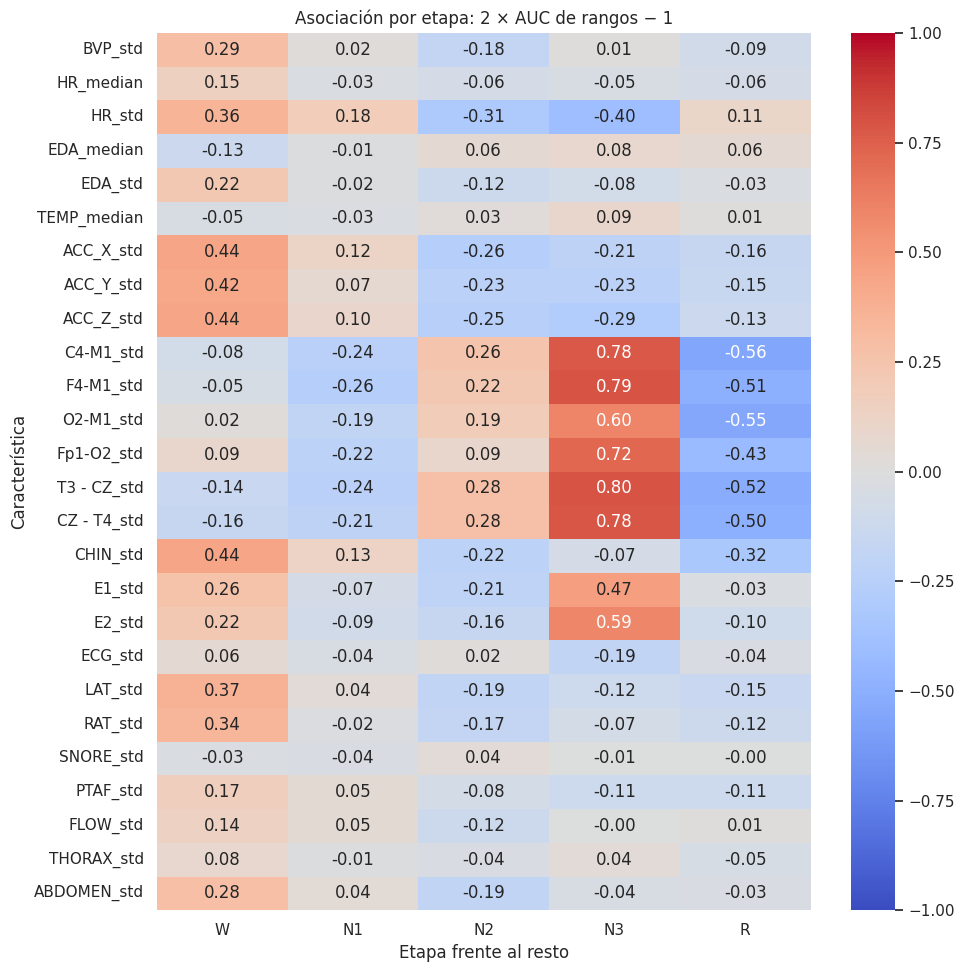

Detalle de cobertura y tamaños por etapa


,variable,Sleep_Stage,auc_rangos,direccion,epochs_etapa,epochs_resto,cobertura_pct,pacientes_etapa
0,BVP_std,W,0.647,0.293,12047,42320,100.0,73
1,BVP_std,N1,0.509,0.018,6389,47978,100.0,73
2,BVP_std,N2,0.412,-0.177,28020,26347,100.0,73
3,BVP_std,N3,0.505,0.009,2059,52308,100.0,35
4,BVP_std,R,0.455,-0.090,5852,48515,100.0,61
...,...,...,...,...,...,...,...,...
125,ABDOMEN_std,W,0.642,0.284,12047,42320,100.0,73
126,ABDOMEN_std,N1,0.520,0.039,6389,47978,100.0,73
127,ABDOMEN_std,N2,0.403,-0.193,28020,26347,100.0,73
128,ABDOMEN_std,N3,0.479,-0.042,2059,52308,100.0,35


0: sin separación univariada; positivo: valores mayores en la etapa; negativo: valores menores. Revisar cobertura y consistencia entre pacientes. Estas AUC no son rendimiento predictivo fuera de muestra.


In [ ]:
# 3.4. Asociación por etapa: AUC de rangos uno contra el resto
orden_etapas = ["W", "N1", "N2", "N3", "R"]
if not df_epochs_all["Sleep_Stage"].isin(orden_etapas).all():
    raise ValueError("Hay etapas inválidas o faltantes.")

filas_auc = []
for variable in caracteristicas_asociacion:
    valores = pd.to_numeric(df_epochs_all[variable], errors="coerce")
    validos = valores.notna() & np.isfinite(valores)
    rangos = valores.loc[validos].rank(method="average")
    etapas_validas = df_epochs_all.loc[validos, "Sleep_Stage"]
    for etapa in orden_etapas:
        positivos = etapas_validas.eq(etapa)
        n_pos = int(positivos.sum())
        n_neg = int((~positivos).sum())
        auc = (
            (rangos.loc[positivos].sum() - n_pos * (n_pos + 1) / 2)
            / (n_pos * n_neg)
            if n_pos and n_neg else np.nan
        )
        filas_auc.append({
            "variable": variable, "Sleep_Stage": etapa,
            "auc_rangos": auc,
            "direccion": 2 * auc - 1 if pd.notna(auc) else np.nan,
            "epochs_etapa": n_pos, "epochs_resto": n_neg,
            "cobertura_pct": 100 * validos.mean(),
            "pacientes_etapa": df_epochs_all.loc[
                validos & df_epochs_all["Sleep_Stage"].eq(etapa), "patient_id"
            ].nunique(),
        })

resumen_auc_etapa = pd.DataFrame(filas_auc)
matriz_direccion = resumen_auc_etapa.pivot(
    index="variable", columns="Sleep_Stage", values="direccion"
).reindex(index=caracteristicas_asociacion, columns=orden_etapas)
if matriz_direccion.notna().any().any():
    plt.figure(figsize=(10, max(7, 0.38 * len(matriz_direccion))))
    sns.heatmap(matriz_direccion, annot=True, fmt=".2f",
                cmap="coolwarm", center=0, vmin=-1, vmax=1)
    plt.title("Asociación por etapa: 2 × AUC de rangos − 1")
    plt.xlabel("Etapa frente al resto")
    plt.ylabel("Característica")
    plt.tight_layout()
    plt.show()
else:
    print("No hay etapas con ambos grupos para calcular AUC de rangos.")

print("Detalle de cobertura y tamaños por etapa")
display(resumen_auc_etapa.round(3))
print(
    "0: sin separación univariada; positivo: valores mayores en la etapa; "
    "negativo: valores menores. Revisar cobertura y consistencia entre pacientes. "
    "Estas AUC no son rendimiento predictivo fuera de muestra."
)


**Interpretación del análisis de correlación:**

Las conclusiones se redactarán a partir de los mapas regenerados con el ETL actual. No se conservan coeficientes de versiones anteriores ni se interpreta REM como un nivel numérico de profundidad.

La relación descriptiva con cada etapa se muestra en el mapa de AUC de rangos y en las distribuciones globales de la sección 3.3. La utilidad predictiva deberá evaluarse después con pacientes separados.

### 3.4.3. Relación descriptiva entre tiempo y etapa del sueño

Se usa `tiempo_relativo_segundos`, calculado desde el inicio del CSV original, **no** desde el inicio del sueño. Se analizan todos los pacientes y epochs disponibles en `df_epochs_all`; el alcance y las exclusiones de esta vista se informan en la salida. No se releen señales crudas, no se modifica el ETL ni se incorpora el tiempo a `X`.

Se comparan tiempos por etapa, proporciones en bloques de 30 minutos y AUC de rangos de cada etapa frente al resto. AUC > 0,5 indica aparición relativamente más tardía; < 0,5, más temprana. **AUC = 0,5 no descarta un patrón cíclico o no monótono**. No se numeran las etapas para calcular una correlación de Spearman, porque son categorías.

El cálculo global pondera más a pacientes con más epochs. Por eso se añade el análisis dentro de cada paciente y un promedio de proporciones que da igual peso a cada paciente observado en el bloque. Para AUC por paciente se exigen al menos cinco epochs en la etapa y cinco en el resto; es un criterio exploratorio, no clínico. Etapas ausentes o con pocos epochs quedan como no evaluables, nunca como AUC cero. Los huecos temporales y bloques sin observaciones no se rellenan.

Estas son asociaciones descriptivas de los datos observados, **no rendimiento de un clasificador, causalidad ni evidencia de generalización**. La dependencia temporal entre epochs impide tratarlos como observaciones independientes para una prueba de significación convencional.


In [ ]:
# 3.4.3. Tiempo frente a etapa: análisis global y dentro de pacientes
BLOQUE_TIEMPO_MINUTOS = 30
MIN_EPOCHS_TIEMPO_POR_GRUPO = 5
orden_etapas_tiempo = ["W", "N1", "N2", "N3", "R"]


def auc_tiempo_rangos(valores, positivos, min_epochs=1):
    """Probabilidad de mayor tiempo en la etapa, contando empates como 0,5."""
    valores = pd.Series(np.asarray(valores, dtype=float))
    positivos = pd.Series(np.asarray(positivos, dtype=bool))
    if len(valores) != len(positivos) or not np.isfinite(valores).all():
        raise ValueError("AUC temporal: longitudes distintas o tiempos no finitos.")
    n_pos, n_neg = int(positivos.sum()), int((~positivos).sum())
    if n_pos < min_epochs or n_neg < min_epochs:
        return np.nan
    rangos = valores.rank(method="average")
    return float(
        (rangos.loc[positivos].sum() - n_pos * (n_pos + 1) / 2)
        / (n_pos * n_neg)
    )


def analizar_tiempo_etapas(datos, bloque_minutos=30, min_epochs=5):
    """Construir vistas descriptivas sin modificar datos ni comprimir huecos."""
    columnas = ["patient_id", "epoch", "Sleep_Stage", "tiempo_relativo_segundos"]
    if datos.empty or not set(columnas).issubset(datos.columns):
        raise ValueError("Falta un dataset de epochs no vacío con tiempo relativo.")
    if not np.isfinite(bloque_minutos) or bloque_minutos <= 0 or min_epochs < 1:
        raise ValueError("El bloque y el mínimo de epochs deben ser positivos.")
    if datos[["patient_id", "epoch"]].isna().any().any():
        raise ValueError("Hay identidades paciente/epoch faltantes.")
    if datos.duplicated(["patient_id", "epoch"]).any():
        raise ValueError("Hay identidades paciente/epoch repetidas.")

    etapas = ["W", "N1", "N2", "N3", "R"]
    temporal = datos[columnas].copy()
    temporal["tiempo_relativo_segundos"] = pd.to_numeric(
        temporal["tiempo_relativo_segundos"], errors="coerce"
    )
    etapa_valida = temporal["Sleep_Stage"].isin(etapas)
    tiempo_valido = (
        np.isfinite(temporal["tiempo_relativo_segundos"])
        & temporal["tiempo_relativo_segundos"].ge(0)
    )
    cobertura = {
        "epochs_dataset": len(datos),
        "pacientes_dataset": datos["patient_id"].nunique(),
        "epochs_etapa_invalida": int((~etapa_valida).sum()),
        # Exclusiones disjuntas: se cuenta el tiempo inválido solo con etapa válida.
        "epochs_tiempo_invalido": int((etapa_valida & ~tiempo_valido).sum()),
    }
    temporal = temporal.loc[etapa_valida & tiempo_valido].copy()
    if temporal.empty:
        raise ValueError("No hay epochs con etapa válida y tiempo finito no negativo.")
    if temporal.duplicated(["patient_id", "tiempo_relativo_segundos"]).any():
        raise ValueError("Un mismo instante se repite dentro de un paciente.")
    temporal["tiempo_minutos"] = temporal["tiempo_relativo_segundos"] / 60
    cobertura.update({
        "epochs_analizados": len(temporal),
        "pacientes_analizados": temporal["patient_id"].nunique(),
        "cobertura_epochs_pct": 100 * len(temporal) / len(datos),
    })

    filas_globales, filas_paciente = [], []
    for etapa in etapas:
        positivos = temporal["Sleep_Stage"].eq(etapa)
        tiempos_etapa = temporal.loc[positivos, "tiempo_minutos"]
        auc = auc_tiempo_rangos(temporal["tiempo_minutos"], positivos)
        filas_globales.append({
            "Sleep_Stage": etapa,
            "epochs_etapa": int(positivos.sum()),
            "epochs_resto": int((~positivos).sum()),
            "pacientes_con_etapa": temporal.loc[positivos, "patient_id"].nunique(),
            "p25_minutos": tiempos_etapa.quantile(0.25),
            "mediana_minutos": tiempos_etapa.median(),
            "p75_minutos": tiempos_etapa.quantile(0.75),
            "auc_global": auc,
            "direccion_global": 2 * auc - 1,
        })
    for paciente, grupo in temporal.groupby("patient_id", sort=True):
        for etapa in etapas:
            positivos = grupo["Sleep_Stage"].eq(etapa)
            n_pos, n_neg = int(positivos.sum()), int((~positivos).sum())
            auc = auc_tiempo_rangos(grupo["tiempo_minutos"], positivos, min_epochs)
            filas_paciente.append({
                "patient_id": paciente, "Sleep_Stage": etapa,
                "epochs_etapa": n_pos, "epochs_resto": n_neg,
                "auc_rangos": auc, "direccion": 2 * auc - 1,
                "estado": "evaluable" if pd.notna(auc) else "pocos epochs o etapa ausente",
            })
    globales = pd.DataFrame(filas_globales)
    por_paciente = pd.DataFrame(filas_paciente)
    filas_estabilidad = []
    for etapa in etapas:
        aucs = por_paciente.loc[
            por_paciente["Sleep_Stage"].eq(etapa), "auc_rangos"
        ].dropna()
        filas_estabilidad.append({
            "Sleep_Stage": etapa, "pacientes_evaluables": len(aucs),
            "auc_paciente_p25": aucs.quantile(0.25),
            "auc_paciente_mediana": aucs.median(),
            "auc_paciente_p75": aucs.quantile(0.75),
            "pacientes_auc_mayor_05_pct": 100 * aucs.gt(0.5).mean() if len(aucs) else np.nan,
        })
    resumen = globales.merge(pd.DataFrame(filas_estabilidad), on="Sleep_Stage")

    # Intervalos [inicio, fin), referidos al CSV; epoch no se usa como reloj.
    temporal["bloque_temporal"] = (
        temporal["tiempo_relativo_segundos"] // (bloque_minutos * 60)
    ).astype(int)
    indice_bloques = pd.RangeIndex(
        int(temporal["bloque_temporal"].max()) + 1, name="bloque_temporal"
    )
    conteos = (
        temporal.groupby(["bloque_temporal", "Sleep_Stage"], observed=True)
        .size().unstack(fill_value=0)
        .reindex(index=indice_bloques, columns=etapas, fill_value=0)
    )
    proporciones_globales = (
        100 * conteos.div(conteos.sum(axis=1).replace(0, np.nan), axis=0)
    )
    conteos_paciente = (
        temporal.groupby(["bloque_temporal", "patient_id", "Sleep_Stage"], observed=True)
        .size().unstack(fill_value=0).reindex(columns=etapas, fill_value=0)
    )
    # Las etapas ausentes valen 0 solo donde ese paciente sí tiene observaciones.
    porcentajes_paciente = 100 * conteos_paciente.div(
        conteos_paciente.sum(axis=1), axis=0
    )
    proporciones_pacientes = (
        porcentajes_paciente.groupby(level="bloque_temporal").mean()
        .reindex(indice_bloques)
    )
    cobertura_bloques = pd.DataFrame({
        "inicio_minutos": indice_bloques * bloque_minutos,
        "fin_minutos": (indice_bloques + 1) * bloque_minutos,
        "epochs": conteos.sum(axis=1),
        "pacientes": temporal.groupby("bloque_temporal")["patient_id"]
            .nunique().reindex(indice_bloques, fill_value=0),
    })
    return {
        "datos": temporal, "cobertura": cobertura, "resumen": resumen,
        "por_paciente": por_paciente, "proporciones_globales": proporciones_globales,
        "proporciones_pacientes": proporciones_pacientes,
        "cobertura_bloques": cobertura_bloques,
    }


if "df_epochs_all" not in globals():
    raise ValueError("Ejecutar primero 3.1 o cargar su caché validada.")
huella_base_tiempo = pd.util.hash_pandas_object(df_epochs_all, index=True).copy()
resultado_tiempo = analizar_tiempo_etapas(
    df_epochs_all, BLOQUE_TIEMPO_MINUTOS, MIN_EPOCHS_TIEMPO_POR_GRUPO
)
resumen_tiempo_etapa = resultado_tiempo["resumen"]
auc_tiempo_por_paciente = resultado_tiempo["por_paciente"]
matriz_auc_tiempo = auc_tiempo_por_paciente.pivot(
    index="patient_id", columns="Sleep_Stage", values="auc_rangos"
).reindex(columns=orden_etapas_tiempo)
print("ALCANCE REAL: todos los epochs y pacientes evaluables del ETL cargado.")
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(pd.DataFrame([resultado_tiempo["cobertura"]]).round(2))
    print("TIEMPO DESDE EL INICIO DEL CSV POR ETAPA; no desde el inicio del sueño")
    display(resumen_tiempo_etapa.round(3))
    print("AUC DENTRO DE CADA PACIENTE; NaN = no evaluable con el mínimo requerido")
    display(matriz_auc_tiempo.round(3))
    print("COBERTURA POR BLOQUE: revisar pacientes y epochs antes de comparar extremos")
    display(resultado_tiempo["cobertura_bloques"])


ALCANCE REAL: todos los epochs y pacientes evaluables del ETL cargado.
TIEMPO DESDE EL INICIO DEL CSV POR ETAPA; no desde el inicio del sueño
AUC DENTRO DE CADA PACIENTE; NaN = no evaluable con el mínimo requerido
COBERTURA POR BLOQUE: revisar pacientes y epochs antes de comparar extremos


,epochs_dataset,pacientes_dataset,epochs_etapa_invalida,epochs_tiempo_invalido,epochs_analizados,pacientes_analizados,cobertura_epochs_pct
0,13165,18,0,0,13165,18,100.0


,Sleep_Stage,epochs_etapa,epochs_resto,pacientes_con_etapa,p25_minutos,mediana_minutos,p75_minutos,auc_global,direccion_global,pacientes_evaluables,auc_paciente_p25,auc_paciente_mediana,auc_paciente_p75,pacientes_auc_mayor_05_pct
0,W,4267,8898,18,126.183,205.617,281.792,0.567,0.134,18,0.496,0.633,0.678,72.222
1,N1,1589,11576,18,78.000,175.183,272.183,0.471,-0.059,18,0.407,0.458,0.519,38.889
2,N2,5744,7421,18,70.413,163.500,265.504,0.436,-0.128,18,0.344,0.406,0.461,22.222
3,N3,438,12727,7,71.425,92.750,141.850,0.310,-0.380,5,0.228,0.260,0.278,0.000
4,R,1127,12038,14,144.008,247.000,303.467,0.633,0.265,14,0.506,0.673,0.773,71.429


Sleep_Stage,W,N1,N2,N3,R
patient_id,,,,,
2,0.660,0.695,0.184,NaN,0.782
3,0.651,0.421,0.513,0.260,0.687
4,0.310,0.368,0.737,NaN,NaN
5,0.399,0.511,0.458,0.278,0.660
6,0.823,0.522,0.421,0.228,NaN
7,0.646,0.678,0.366,0.197,0.480
8,0.612,0.551,0.462,0.313,0.625
9,0.683,0.680,0.337,NaN,0.388
10,0.474,0.472,0.378,NaN,0.884


,inicio_minutos,fin_minutos,epochs,pacientes
bloque_temporal,,,,
0,0,30,1080,18
1,30,60,1080,18
2,60,90,1080,18
3,90,120,1080,18
4,120,150,1080,18
5,150,180,1080,18
6,180,210,1080,18
7,210,240,1080,18
8,240,270,1075,18


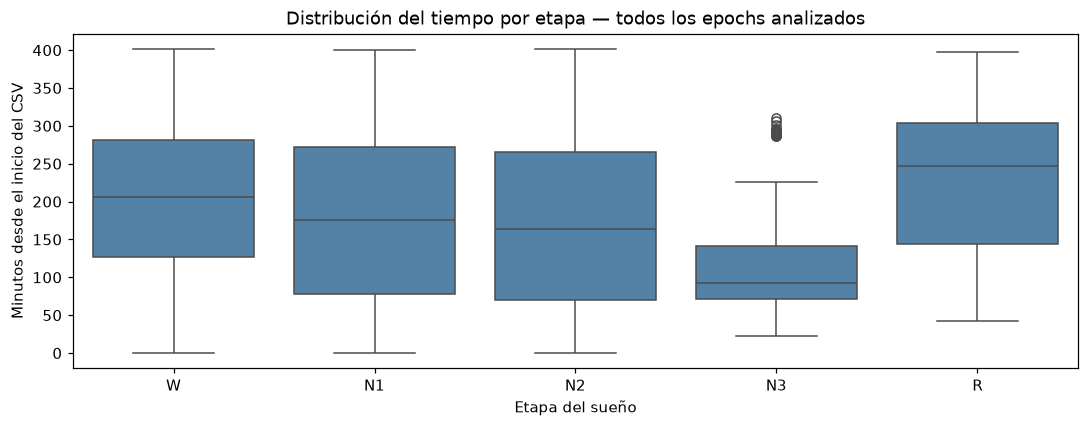

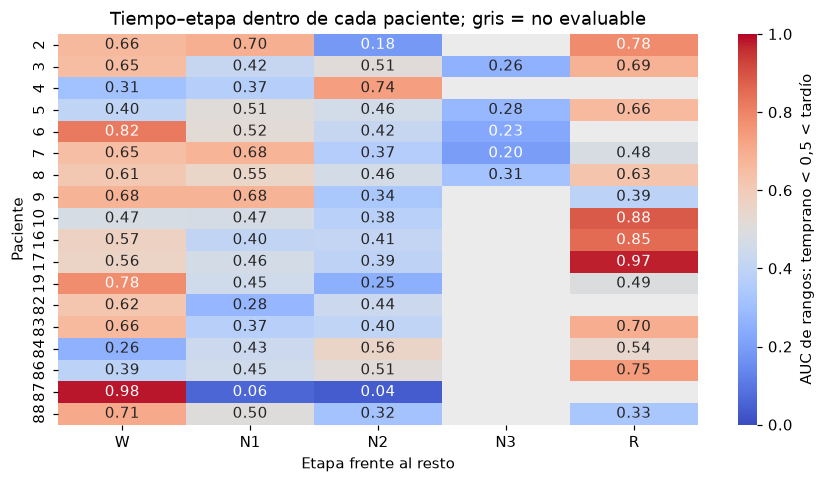

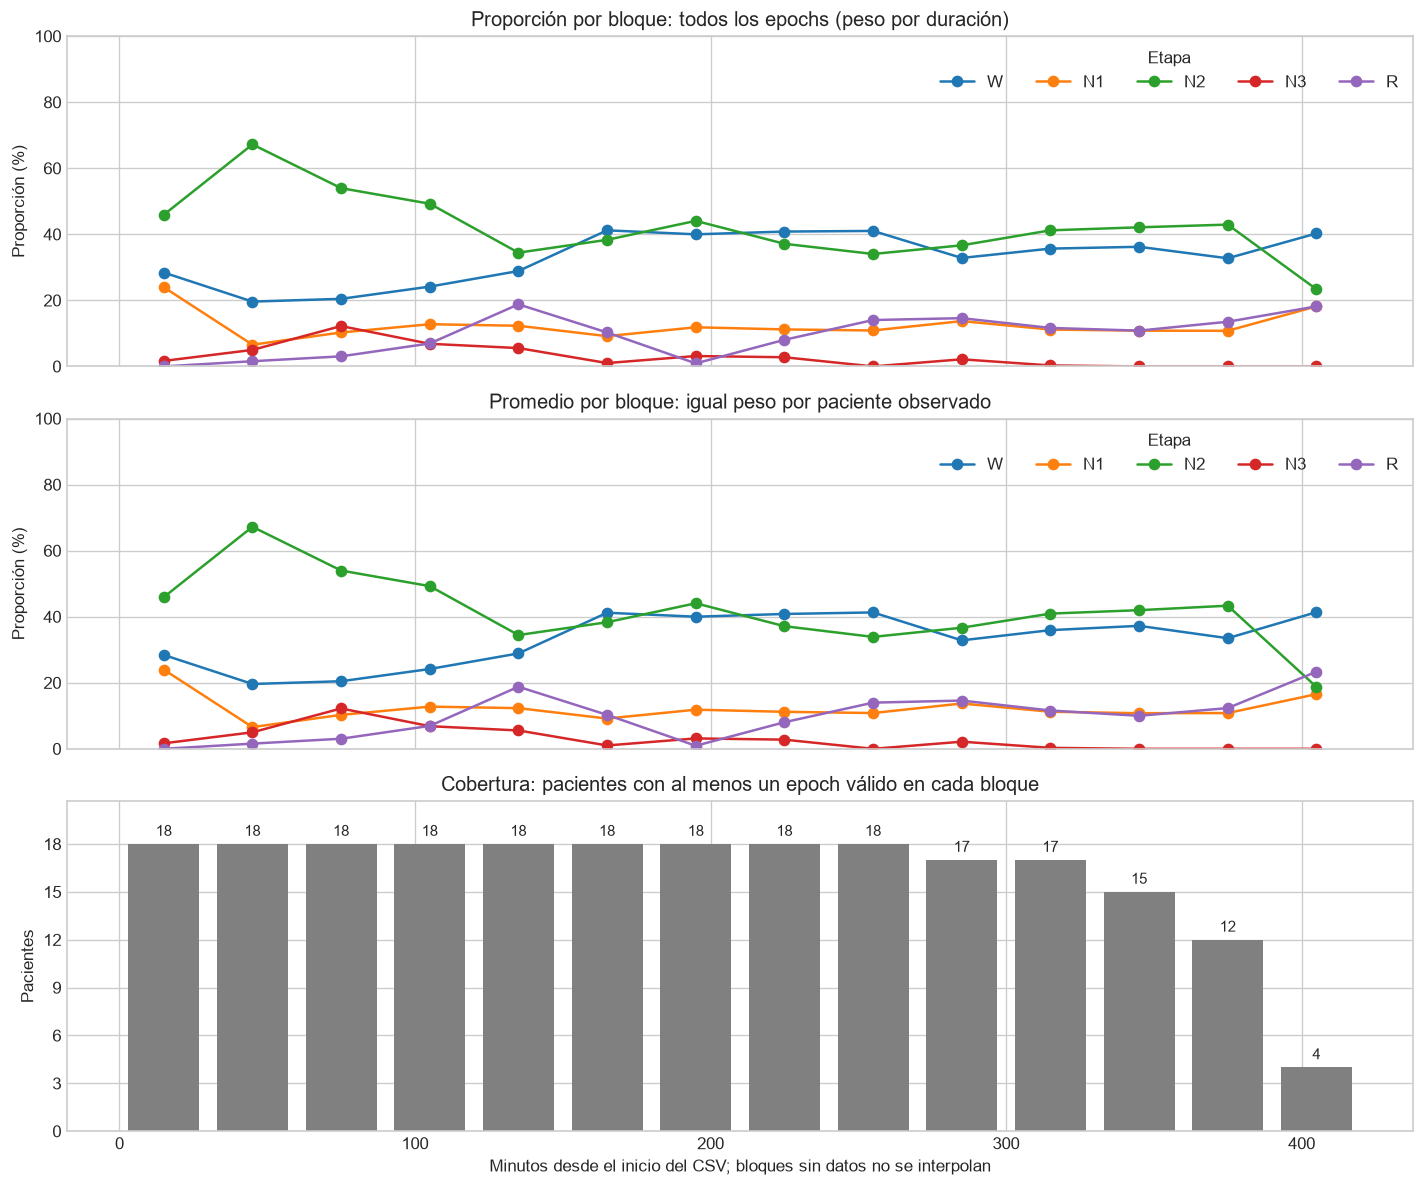

In [ ]:
# 3.4.3. Gráficos temporales; sin entrenar modelos ni transformar predictores
paleta_tiempo = dict(zip(orden_etapas_tiempo, sns.color_palette("tab10", 5)))
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(
    data=resultado_tiempo["datos"], x="Sleep_Stage", y="tiempo_minutos",
    order=orden_etapas_tiempo, color="steelblue", showfliers=True, ax=ax
)
ax.set_title("Distribución del tiempo por etapa — todos los epochs analizados")
ax.set_xlabel("Etapa del sueño")
ax.set_ylabel("Minutos desde el inicio del CSV")
fig.tight_layout()
plt.show()

if matriz_auc_tiempo.notna().any().any():
    fig, ax = plt.subplots(figsize=(8, max(4, 0.25 * len(matriz_auc_tiempo))))
    ax.set_facecolor("0.92")
    sns.heatmap(
        matriz_auc_tiempo, annot=len(matriz_auc_tiempo) <= 100, fmt=".2f",
        cmap="coolwarm", center=0.5, vmin=0, vmax=1, ax=ax,
        cbar_kws={"label": "AUC de rangos: temprano < 0,5 < tardío"}
    )
    ax.set_title("Tiempo–etapa dentro de cada paciente; gris = no evaluable")
    ax.set_xlabel("Etapa frente al resto")
    ax.set_ylabel("Paciente")
    fig.tight_layout()
    plt.show()
else:
    print("Ningún paciente tiene suficientes epochs en ambos grupos para la AUC.")

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
cobertura_bloques_tiempo = resultado_tiempo["cobertura_bloques"]
centros_minutos = (
    cobertura_bloques_tiempo["inicio_minutos"]
    + cobertura_bloques_tiempo["fin_minutos"]
) / 2
for ax, clave, titulo in [
    (axes[0], "proporciones_globales", "Proporción por bloque: todos los epochs (peso por duración)"),
    (axes[1], "proporciones_pacientes", "Promedio por bloque: igual peso por paciente observado"),
]:
    for etapa in orden_etapas_tiempo:
        ax.plot(centros_minutos, resultado_tiempo[clave][etapa],
                marker="o", color=paleta_tiempo[etapa], label=etapa)
    ax.set_title(titulo)
    ax.set_ylabel("Proporción (%)")
    ax.set_ylim(0, 100)
    ax.legend(ncol=5, title="Etapa", loc="upper right")
barras_cobertura = axes[2].bar(
    centros_minutos, cobertura_bloques_tiempo["pacientes"],
    width=BLOQUE_TIEMPO_MINUTOS * 0.8, color="0.5"
)
# Conteos discretos: marcas enteras, adaptadas a la cohorte, y etiquetas por barra.
max_pacientes_bloque = int(cobertura_bloques_tiempo["pacientes"].max())
paso_pacientes = max(1, int(np.ceil(max_pacientes_bloque / 6)))
marcas_pacientes = np.arange(0, max_pacientes_bloque + 1, paso_pacientes)
if marcas_pacientes[-1] != max_pacientes_bloque:
    marcas_pacientes = np.append(marcas_pacientes, max_pacientes_bloque)
axes[2].set_yticks(marcas_pacientes)
axes[2].set_ylim(0, max(1, max_pacientes_bloque * 1.15))
axes[2].bar_label(
    barras_cobertura,
    labels=[str(int(n)) for n in cobertura_bloques_tiempo["pacientes"]],
    padding=3, fontsize=9,
)
axes[2].set_title("Cobertura: pacientes con al menos un epoch válido en cada bloque")
axes[2].set_ylabel("Pacientes")
axes[2].set_xlabel("Minutos desde el inicio del CSV; bloques sin datos no se interpolan")
fig.tight_layout()
plt.show()


In [ ]:
# 3.4.3. Controles de la prueba temporal, registrados dentro del notebook
pruebas_tiempo = []


def comprobar_tiempo(nombre, condicion):
    pruebas_tiempo.append({"control": nombre, "correcto": bool(condicion)})
    if not condicion:
        raise AssertionError(f"Prueba temporal fallida: {nombre}")


comprobar_tiempo("Etapa tardía: AUC = 1",
                np.isclose(auc_tiempo_rangos([0, 1, 2, 3], [False, False, True, True]), 1))
comprobar_tiempo("Etapa temprana: AUC = 0",
                np.isclose(auc_tiempo_rangos([0, 1, 2, 3], [True, True, False, False]), 0))
comprobar_tiempo("Empates: AUC = 0,5",
                np.isclose(auc_tiempo_rangos([1, 1, 1, 1], [True, True, False, False]), 0.5))
comprobar_tiempo("Etapa ausente: AUC faltante, no cero",
                pd.isna(auc_tiempo_rangos([0, 1], [False, False])))
comprobar_tiempo("Pocos epochs: paciente no evaluable",
                pd.isna(auc_tiempo_rangos([0, 1], [True, False], min_epochs=5)))

ejemplo_hueco = pd.DataFrame({
    "patient_id": [1, 1], "epoch": [0, 1], "Sleep_Stage": ["W", "R"],
    "tiempo_relativo_segundos": [0, 3600],
})
copia_ejemplo_hueco = ejemplo_hueco.copy(deep=True)
resultado_hueco = analizar_tiempo_etapas(ejemplo_hueco)
pd.testing.assert_frame_equal(ejemplo_hueco, copia_ejemplo_hueco)
comprobar_tiempo("El tiempo real conserva huecos aunque epoch sea consecutivo",
                resultado_hueco["datos"]["bloque_temporal"].tolist() == [0, 2])
comprobar_tiempo("Bloque sin epochs: proporciones faltantes, no ceros",
                resultado_hueco["proporciones_globales"].loc[1].isna().all()
                and resultado_hueco["cobertura_bloques"].loc[1, "pacientes"] == 0)
comprobar_tiempo("Una etapa no observada queda no evaluable",
                resultado_hueco["por_paciente"].query("Sleep_Stage == 'N3'")["auc_rangos"].isna().all())

ejemplo_pesos = pd.DataFrame({
    "patient_id": [1] * 9 + [2], "epoch": list(range(9)) + [0],
    "Sleep_Stage": ["W"] * 9 + ["R"], "tiempo_relativo_segundos": list(range(9)) + [0],
})
resultado_pesos = analizar_tiempo_etapas(ejemplo_pesos)
comprobar_tiempo("Peso global y peso igual por paciente se distinguen",
                np.isclose(resultado_pesos["proporciones_globales"].loc[0, "W"], 90)
                and np.isclose(resultado_pesos["proporciones_pacientes"].loc[0, "W"], 50))
ejemplo_invalidos = pd.DataFrame({
    "patient_id": [1] * 5, "epoch": list(range(5)),
    "Sleep_Stage": ["W", "R", "W", "W", "Missing"],
    "tiempo_relativo_segundos": [0, 30, -1, np.inf, 60],
})
resultado_invalidos = analizar_tiempo_etapas(ejemplo_invalidos)
comprobar_tiempo("Tiempos inválidos y etiquetas inválidas se cuentan sin alterar el ETL",
                resultado_invalidos["cobertura"]["epochs_tiempo_invalido"] == 2
                and resultado_invalidos["cobertura"]["epochs_etapa_invalida"] == 1
                and resultado_invalidos["cobertura"]["epochs_analizados"] == 2)

for clave in ["proporciones_globales", "proporciones_pacientes"]:
    proporciones = resultado_tiempo[clave]
    observados = resultado_tiempo["cobertura_bloques"]["epochs"].gt(0)
    comprobar_tiempo(f"{clave}: cada bloque observado suma 100 %",
                    np.allclose(proporciones.loc[observados].sum(axis=1), 100))
comprobar_tiempo("Recuentos por etapa concilian con epochs analizados",
                resumen_tiempo_etapa["epochs_etapa"].sum()
                == resultado_tiempo["cobertura"]["epochs_analizados"])
comprobar_tiempo("Ninguna AUC evaluable sale de [0, 1]",
                auc_tiempo_por_paciente["auc_rangos"].dropna().between(0, 1).all())
comprobar_tiempo("La prueba conserva íntegro el dataset base",
                huella_base_tiempo.equals(pd.util.hash_pandas_object(df_epochs_all, index=True)))
display(pd.DataFrame(pruebas_tiempo))
print("Controles aprobados:", len(pruebas_tiempo), "| No se entrenaron algoritmos.")


Controles aprobados: 15 | No se entrenaron algoritmos.


,control,correcto
0,Etapa tardía: AUC = 1,True
1,Etapa temprana: AUC = 0,True
2,"Empates: AUC = 0,5",True
3,"Etapa ausente: AUC faltante, no cero",True
4,Pocos epochs: paciente no evaluable,True
5,El tiempo real conserva huecos aunque epoch sea consecutivo,True
6,"Bloque sin epochs: proporciones faltantes, no ceros",True
7,Una etapa no observada queda no evaluable,True
8,Peso global y peso igual por paciente se distinguen,True
9,Tiempos inválidos y etiquetas inválidas se cuentan sin alterar el ETL,True


#### Cómo interpretar la prueba y qué queda pendiente

- **Cajas de tiempo:** muestran cuándo aparecen los epochs de cada etapa en los registros disponibles, no cuánto dura esa etapa ni que una persona deba pasar por ellas en ese orden.
- **AUC global frente a AUC por paciente:** si sus patrones difieren, revisar la composición de pacientes, la duración y los huecos del ETL. El mapa permite comprobar heterogeneidad; una celda gris significa falta de una comparación evaluable.
- **Proporciones por bloque:** leerlas junto con la cobertura. Hacia el final pueden quedar menos pacientes; los bloques parciales, registros cortos y segmentos descartados limitan la comparación. Dar igual peso a pacientes no balancea clases ni modifica el dataset.
- **Decisión pendiente:** mantener `tiempo_relativo_segundos` para trazabilidad. Más adelante comparar, con los mismos pacientes de validación, A: señales sin tiempo; B: tiempo solo; C: señales + tiempo. No agregar ahora `epoch` como segundo reloj ni aceptar el tiempo en `X` solo por una AUC descriptiva.

Los controles verifican la construcción y la interpretación del cálculo, no la utilidad predictiva. Esta sección no produce un dataset distinto, no imputa huecos, no normaliza el tiempo por duración total de la noche y no realiza pruebas de significación con epochs supuestamente independientes.


## 3.5. Revisión de características y propuestas experimentales

La tabla siguiente reúne cobertura, variación, asociación descriptiva por etapa y marcas de revisión para las características del dataset base. Las medias y medianas de señales oscilatorias se **marcan para examinar**, no se eliminan. Después se resume si algunas diferencias por etapa mantienen su dirección entre pacientes, sin generar un gráfico por persona. Ninguno de estos criterios sustituye la comparación futura de modelos con partición por paciente. Las propuestas de ingeniería de características permanecen desactivadas y, si se habilitan más adelante, trabajarán sobre una copia.


### 3.5.1. Ficha de variables y consistencia entre pacientes

Cada fila de la primera tabla representa una característica existente. «Pendiente» significa que todavía no se decidió incluirla o excluirla del modelo. La marca de señal oscilatoria advierte que una media cercana a cero puede ser poco informativa sobre amplitud, pero no demuestra que la señal deba quitarse.

La segunda tabla compara, para cada paciente con al menos cinco epochs válidos en ambos grupos, la mediana de una etapa contra la mediana del resto. Para HR, TEMP y EDA utiliza las características `*_median` por epoch, igual que 3.4; luego resume la mediana de las diferencias entre pacientes. Informa cuántos pacientes permiten esa comparación y en qué proporción la diferencia tiene signo positivo. El umbral de cinco epochs es exploratorio para evitar interpretar una mediana de uno o dos epochs; no es un criterio clínico. No se asigna cero a pacientes sin esa etapa. La magnitud de diferencias entre señales con distintas unidades no es comparable. **Reejecutar esta celda:** las salidas guardadas pueden corresponder a `*_mean`.


In [ ]:
# 3.5.1. Ficha descriptiva de características y estabilidad entre pacientes
if "resumen_auc_etapa" not in globals():
    raise ValueError("Ejecutar primero el mapa de asociación de la sección 3.4.")

columnas_revision = [c for c in df_epochs_all.columns
                     if c.endswith(("_mean", "_std", "_median"))]
filas_revision = []
for variable in columnas_revision:
    valores = pd.to_numeric(df_epochs_all[variable], errors="coerce")
    validos = valores.notna() & np.isfinite(valores)
    senal, estadistico = variable.rsplit("_", 1)
    marca = (
        "revisar resumen oscilatorio"
        if estadistico in ("mean", "median")
        and senal in set(psg_cols + ["BVP"])
        else "sin marca específica"
    )
    asociaciones = resumen_auc_etapa.loc[
        resumen_auc_etapa["variable"].eq(variable)
        & resumen_auc_etapa["direccion"].notna()
    ]
    mayor = (
        asociaciones.loc[asociaciones["direccion"].abs().idxmax()]
        if not asociaciones.empty else None
    )
    filas_revision.append({
        "variable": variable,
        "marca_revision": marca,
        "cobertura_pct": 100 * validos.mean(),
        "pacientes_con_valor": df_epochs_all.loc[validos, "patient_id"].nunique(),
        "valores_distintos": valores.loc[validos].nunique(),
        "iqr": valores.loc[validos].quantile(0.75)
               - valores.loc[validos].quantile(0.25) if validos.any() else np.nan,
        "etapa_mayor_asociacion": mayor["Sleep_Stage"] if mayor is not None else None,
        "direccion_mayor": mayor["direccion"] if mayor is not None else np.nan,
        "decision_modelo": "pendiente",
    })
revision_caracteristicas = pd.DataFrame(filas_revision)
print("FICHA DE CARACTERÍSTICAS; NO SE ELIMINÓ NINGUNA")
with pd.option_context("display.max_rows", 100):
    display(revision_caracteristicas.round(3))

variables_estabilidad = [c for c in [
    "HR_median", "TEMP_median", "EDA_median", "BVP_std",
    "ACC_X_std", "C4-M1_std", "E1_std", "FLOW_std",
] if c in df_epochs_all.columns]
min_epochs_comparacion = 5
filas_estabilidad = []
for variable in variables_estabilidad:
    datos = df_epochs_all[["patient_id", "Sleep_Stage", variable]].copy()
    datos[variable] = pd.to_numeric(datos[variable], errors="coerce")
    datos = datos.loc[np.isfinite(datos[variable])]
    for etapa in ["W", "N1", "N2", "N3", "R"]:
        en_etapa = datos["Sleep_Stage"].eq(etapa)
        dentro = datos.loc[en_etapa].groupby("patient_id")[variable].agg(
            mediana_etapa="median", epochs_etapa="size"
        )
        fuera = datos.loc[~en_etapa].groupby("patient_id")[variable].agg(
            mediana_resto="median", epochs_resto="size"
        )
        pares = dentro.join(fuera, how="inner")
        pares = pares.loc[
            pares["epochs_etapa"].ge(min_epochs_comparacion)
            & pares["epochs_resto"].ge(min_epochs_comparacion)
        ]
        diferencias = pares["mediana_etapa"] - pares["mediana_resto"]
        filas_estabilidad.append({
            "variable": variable, "Sleep_Stage": etapa,
            "pacientes_evaluables": len(pares),
            "mediana_diferencia": diferencias.median() if len(pares) else np.nan,
            "pacientes_diferencia_positiva_pct":
                100 * diferencias.gt(0).mean() if len(pares) else np.nan,
        })
resumen_estabilidad = pd.DataFrame(filas_estabilidad)
print("DIRECCIÓN DE DIFERENCIAS ENTRE PACIENTES; DESCRIPTIVA")
display(resumen_estabilidad.round(2))


FICHA DE CARACTERÍSTICAS; NO SE ELIMINÓ NINGUNA


,variable,marca_revision,cobertura_pct,pacientes_con_valor,valores_distintos,iqr,etapa_mayor_asociacion,direccion_mayor,decision_modelo
0,BVP_mean,revisar resumen oscilatorio,100.0,73,54352,0.375,None,NaN,pendiente
1,BVP_std,sin marca específica,100.0,73,54249,52.857,W,0.293,pendiente
2,BVP_median,revisar resumen oscilatorio,100.0,73,50376,6.358,None,NaN,pendiente
3,HR_mean,sin marca específica,100.0,73,54140,15.715,None,NaN,pendiente
4,HR_std,sin marca específica,100.0,73,54242,0.551,N3,-0.405,pendiente
5,HR_median,sin marca específica,100.0,73,4897,15.730,W,0.154,pendiente
6,EDA_mean,sin marca específica,100.0,73,54153,0.537,None,NaN,pendiente
7,EDA_std,sin marca específica,100.0,73,54108,0.004,W,0.220,pendiente
8,EDA_median,sin marca específica,100.0,73,18565,0.536,W,-0.131,pendiente
9,TEMP_mean,sin marca específica,100.0,73,50916,3.140,None,NaN,pendiente


DIRECCIÓN DE DIFERENCIAS ENTRE PACIENTES; DESCRIPTIVA


,variable,Sleep_Stage,pacientes_evaluables,mediana_diferencia,pacientes_diferencia_positiva_pct
0,HR_median,W,73,2.43,84.93
1,HR_median,N1,73,-0.22,46.58
2,HR_median,N2,73,-1.42,21.92
3,HR_median,N3,26,2.46,61.54
4,HR_median,R,61,0.04,50.82
5,TEMP_median,W,73,-0.08,42.47
6,TEMP_median,N1,73,-0.06,36.99
7,TEMP_median,N2,73,-0.02,43.84
8,TEMP_median,N3,26,0.22,73.08
9,TEMP_median,R,61,0.01,50.82


### 3.5.2. Variantes reversibles de características

Se definen **alternativas de representación, no correcciones del dataset**. `df_epochs_all` y `dataset_epochs_v1.csv` no cambian. `patient_id` y `epoch` se conservan para trazabilidad y, más adelante, separación por paciente, pero no son predictores de la copia candidata; `Sleep_Stage` es la etiqueta.

La referencia usa medianas por epoch de HR, TEMP y EDA, dispersión de HR/EDA/BVP/ACC y desviaciones estándar PSG. Se define una variante por familia y una candidata combinada: `log1p` de variables no negativas con cola, máximo bilateral de ojos o piernas, norma de las tres desviaciones ACC y retiro alternativo de un canal EEG de pares muy correlacionados. El máximo conserva actividad unilateral; la norma ACC **no** equivale a la desviación estándar de la magnitud del acelerómetro crudo. No hay clipping, binning ni eliminación de epochs atípicos. Correlación alta **solo motiva una comparación futura**; ningún canal se descarta por esa cifra.

Las variantes PSG + wearable y wearable solo son hipótesis para debatir el escenario de uso. En esta sección aún **no se entrena ningún algoritmo** ni se elige automáticamente la variante ganadora. La sección 4 establece qué comparaciones predictivas faltan.

In [ ]:
# 3.5.2. Definiciones de conjuntos de predictores; sin editar el dataset base
wearable_base = [
    "HR_median", "HR_std", "TEMP_median", "EDA_median", "EDA_std",
    "BVP_std", "ACC_X_std", "ACC_Y_std", "ACC_Z_std",
]
psg_std_base = [
    "C4-M1_std", "F4-M1_std", "O2-M1_std", "Fp1-O2_std",
    "T3 - CZ_std", "CZ - T4_std", "CHIN_std", "E1_std", "E2_std",
    "ECG_std", "LAT_std", "RAT_std", "SNORE_std", "PTAF_std",
    "FLOW_std", "THORAX_std", "ABDOMEN_std",
]
faltantes_base = set(wearable_base + psg_std_base + ["Sleep_Stage", "patient_id"]) - set(df_epochs_all.columns)
if faltantes_base:
    raise ValueError(f"Faltan columnas para las comparaciones: {sorted(faltantes_base)}")

variantes_transformacion = [
    ("PSG + wearable", "original"),
    ("PSG + wearable", "log1p_colas"),
    ("PSG + wearable", "ojos_maximo"),
    ("PSG + wearable", "piernas_maximo"),
    ("PSG + wearable", "acc_norma"),
    ("PSG + wearable", "sin_F4-M1_std"),
    ("PSG + wearable", "sin_C4-M1_std"),
    ("PSG + wearable", "sin_CZ - T4_std"),
    ("PSG + wearable", "sin_T3 - CZ_std"),
    ("PSG + wearable", "combinada_candidata"),
    ("wearable solo", "original"),
    ("wearable solo", "log1p_colas"),
    ("wearable solo", "acc_norma"),
    ("wearable solo", "combinada_candidata"),
]

def construir_predictores(escenario, variante, datos):
    # Construye una copia temporal para una comparación; no altera datos.
    columnas = wearable_base + (psg_std_base if escenario == "PSG + wearable" else [])
    if escenario not in {"PSG + wearable", "wearable solo"}:
        raise ValueError(f"Escenario desconocido: {escenario}")
    x = datos.loc[:, columnas].apply(pd.to_numeric, errors="coerce").copy()
    if not np.isfinite(x.to_numpy(dtype=float)).all():
        raise ValueError("Hay predictores no finitos; revisar calidad antes de comparar.")
    if variante == "log1p_colas":
        colas = ["BVP_std", "EDA_median", "ACC_X_std", "ACC_Y_std", "ACC_Z_std"]
        if x[colas].lt(0).any().any():
            raise ValueError("log1p requiere variables no negativas en esta prueba.")
        x.loc[:, colas] = np.log1p(x[colas])
    elif variante == "ojos_maximo":
        x["EOG_max_std"] = x[["E1_std", "E2_std"]].max(axis=1)
        x = x.drop(columns=["E1_std", "E2_std"])
    elif variante == "piernas_maximo":
        x["LEG_max_std"] = x[["LAT_std", "RAT_std"]].max(axis=1)
        x = x.drop(columns=["LAT_std", "RAT_std"])
    elif variante == "acc_norma":
        ejes = ["ACC_X_std", "ACC_Y_std", "ACC_Z_std"]
        x["ACC_axes_std_norm"] = np.sqrt(x[ejes].pow(2).sum(axis=1))
        x = x.drop(columns=ejes)
    elif variante == "combinada_candidata":
        if escenario == "PSG + wearable":
            x["EOG_max_std"] = x[["E1_std", "E2_std"]].max(axis=1)
            x["LEG_max_std"] = x[["LAT_std", "RAT_std"]].max(axis=1)
            x = x.drop(columns=["E1_std", "E2_std", "LAT_std", "RAT_std"])
        ejes = ["ACC_X_std", "ACC_Y_std", "ACC_Z_std"]
        x["ACC_axes_std_norm"] = np.sqrt(x[ejes].pow(2).sum(axis=1))
        x = x.drop(columns=ejes)
        por_log = ["BVP_std", "EDA_median", "ACC_axes_std_norm"]
        if x[por_log].lt(0).any().any():
            raise ValueError("La candidata combinada exige entradas no negativas.")
        for columna in por_log:
            x[f"{columna}_log1p"] = np.log1p(x[columna])
        x = x.drop(columns=por_log)
    elif variante.startswith("sin_"):
        columna = variante.removeprefix("sin_")
        if columna not in x:
            raise ValueError(f"No se puede retirar {columna} del escenario {escenario}.")
        x = x.drop(columns=[columna])
    elif variante != "original":
        raise ValueError(f"Variante desconocida: {variante}")
    return x

ficha_variantes = pd.DataFrame([
    {"escenario": escenario, "variante": variante,
     "n_predictores": construir_predictores(escenario, variante, df_epochs_all.head(2)).shape[1]}
    for escenario, variante in variantes_transformacion
])
print("Variantes definidas; ninguna columna fue borrada del dataset base.")
display(ficha_variantes)

### 3.5.3. Control descriptivo de variantes (sin algoritmos)

Esta sección comprueba que las 14 variantes definidas en 3.5.2 conserven exactamente los mismos epochs, el índice y valores finitos; documenta qué columnas se incorporan o salen de cada `X` respecto de su referencia original. **No se usa regresión logística ni otro algoritmo, no hay particiones ni métricas predictivas.** Que una variante pase estos controles solo significa que puede construirse con los datos disponibles; **no prueba** que mejore la clasificación de W, N1, N2, N3 o R.

En 3.9 se materializa una copia candidata para inspección, con cuantiles antes/después y controles adicionales. La decisión de conservar una reducción —en especial ojos, piernas, ACC o un canal EEG— queda pendiente de una comparación por pacientes no vistos, descrita en la sección 4. `log1p` comprime colas, pero no corrige ruido ni justifica recortar outliers.

In [ ]:
# 3.5.3. Controles descriptivos de variantes; no se entrena ningún modelo
etapas_esperadas = {"W", "N1", "N2", "N3", "R"}
if not df_epochs_all["Sleep_Stage"].astype(str).isin(etapas_esperadas).all():
    raise ValueError("Hay etiquetas distintas de W, N1, N2, N3 y R.")

referencias_originales = {
    escenario: construir_predictores(escenario, "original", df_epochs_all)
    for escenario in ["PSG + wearable", "wearable solo"]
}
filas_variantes = []
for escenario, variante in variantes_transformacion:
    x_variante = construir_predictores(escenario, variante, df_epochs_all)
    referencia = referencias_originales[escenario]
    mismo_indice = x_variante.index.equals(df_epochs_all.index)
    mismos_epochs = len(x_variante) == len(df_epochs_all)
    finitos = np.isfinite(x_variante.to_numpy(dtype=float)).all()
    if not (mismo_indice and mismos_epochs and finitos):
        raise AssertionError(f"La variante {escenario}/{variante} no pasó los controles.")
    filas_variantes.append({
        "escenario": escenario, "variante": variante,
        "epochs": len(x_variante), "predictores": x_variante.shape[1],
        "columnas_agregadas": ", ".join(sorted(set(x_variante) - set(referencia))) or "—",
        "columnas_fuera_de_X": ", ".join(sorted(set(referencia) - set(x_variante))) or "—",
        "indice_y_finitud": "OK",
    })
resumen_variantes_descriptivas = pd.DataFrame(filas_variantes)
print("Variantes construibles con los mismos epochs; ninguna fue evaluada predictivamente:")
with pd.option_context("display.max_colwidth", None, "display.max_rows", None):
    display(resumen_variantes_descriptivas)
print("Las columnas retiradas de X siguen en df_epochs_all. No se elige variante por estos controles.")

## 3.6. Variación de etapas entre pacientes

Esta sección resume todos los pacientes en la tabla completa, una tabla breve de cuantiles **entre pacientes** y gráficos globales; no genera un hipnograma por persona. Cada proporción usa los epochs conservados de ese paciente. La duración válida cuenta epochs conservados, mientras que el tramo observado entre el primero y el último también incluye posibles huecos. Una etapa ausente significa «no observada en los epochs conservados», no incapacidad fisiológica de alcanzarla. Los cuantiles por paciente no son proporciones globales ponderadas por cantidad de epochs.

La latencia REM se mide desde el **primer epoch de sueño observado** (N1, N2, N3 o R) hasta el primer epoch REM. Si REM no aparece, la latencia queda faltante y se informa «no observado»; no se reemplaza por cero. Las transiciones se cuentan solo entre etiquetas de epochs consecutivos. Un salto por epochs descartados se registra aparte y no se interpreta como transición directa. Proporciones, latencias y transiciones usan `Sleep_Stage` y son únicamente auditoría descriptiva: no pueden entrar como predictores del modelo de esa misma etiqueta. Ningún paciente se excluye por REM temprano, ausencia de REM o ausencia de N3.


PACIENTES RESUMIDOS: 73
SIN REM OBSERVADO: 12
SIN N3 OBSERVADO: 38
RESUMEN POR PACIENTE; SIN EXCLUSIONES


,patient_id,epochs_validos,duracion_valida_min,tramo_observado_min,saltos_entre_epochs,transiciones_contiguas,etapas_ausentes,estado_rem,latencia_rem_desde_primer_sueno_min,epochs_W,pct_W,epochs_N1,pct_N1,epochs_N2,pct_N2,epochs_N3,pct_N3,epochs_R,pct_R,HR_missing_frac_promedio,BVP_missing_frac_promedio,C4-M1_missing_frac_promedio,filas_fragmento_inicial,filas_fragmento_final,epochs_descartados_por_pureza,continuidad_temporal
0,2,652,326.0,326.0,0,188,N3,observado,159.5,174,26.687117,64,9.815951,334,51.226994,0,0.000000,80,12.269939,0.0,0.0,0.0,2400.0,0.0,0.0,verificada en segmentos recuperados
1,3,773,386.5,386.5,0,72,ninguna,observado,96.0,58,7.503234,32,4.139715,428,55.368693,136,17.593790,119,15.394567,0.0,0.0,0.0,2400.0,0.0,0.0,verificada en segmentos recuperados
2,4,804,402.0,402.0,0,274,R,no observado,NaN,216,26.865672,163,20.273632,424,52.736318,1,0.124378,0,0.000000,0.0,0.0,0.0,1100.0,0.0,0.0,verificada en segmentos recuperados
3,5,730,365.0,365.0,0,121,ninguna,observado,98.0,90,12.328767,39,5.342466,480,65.753425,5,0.684932,116,15.890411,0.0,0.0,0.0,1300.0,0.0,0.0,verificada en segmentos recuperados
4,6,801,400.5,400.5,0,191,R,no observado,NaN,210,26.217228,123,15.355805,290,36.204744,178,22.222222,0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,verificada en segmentos recuperados
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,89,634,317.0,317.0,0,121,N3,observado,273.5,125,19.716088,112,17.665615,339,53.470032,0,0.000000,58,9.148265,0.0,0.0,0.0,0.0,0.0,0.0,verificada en segmentos recuperados
69,91,810,405.0,405.0,0,147,ninguna,observado,195.0,59,7.283951,125,15.432099,344,42.469136,157,19.382716,125,15.432099,0.0,0.0,0.0,2900.0,0.0,0.0,verificada en segmentos recuperados
70,95,580,290.0,290.0,0,98,R,no observado,NaN,246,42.413793,39,6.724138,293,50.517241,2,0.344828,0,0.000000,0.0,0.0,0.0,1900.0,0.0,0.0,verificada en segmentos recuperados
71,96,762,381.0,381.0,0,71,R,no observado,NaN,538,70.603675,24,3.149606,141,18.503937,59,7.742782,0,0.000000,0.0,0.0,0.0,2500.0,0.0,0.0,verificada en segmentos recuperados


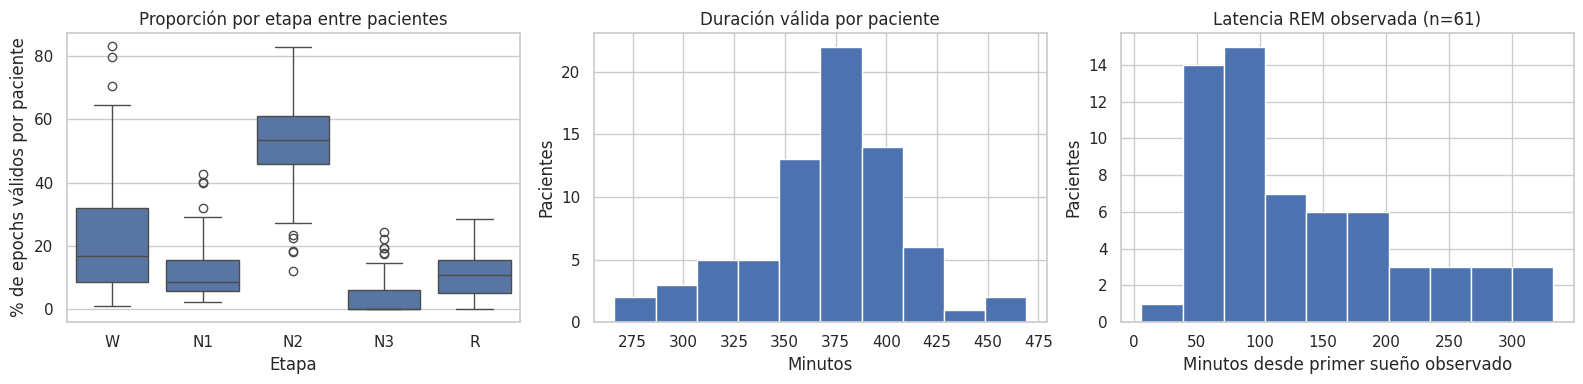

Los gráficos muestran variación descriptiva, no calidad del sueño ni un criterio de exclusión de pacientes.


In [ ]:
# 3.6. Resumen descriptivo de etapas por paciente
orden_etapas = ["W", "N1", "N2", "N3", "R"]
if "df_epochs_all" not in globals() or df_epochs_all.empty:
    raise ValueError("Falta el dataset consolidado de epochs.")
if df_epochs_all.duplicated(["patient_id", "epoch"]).any():
    raise ValueError("Hay claves paciente/epoch duplicadas.")
if not df_epochs_all["Sleep_Stage"].isin(orden_etapas).all():
    raise ValueError("Hay etapas faltantes o inválidas.")

resumen_filas = []
for patient_id, grupo in df_epochs_all.groupby("patient_id", sort=True):
    grupo = grupo.sort_values("epoch")
    conteos = grupo["Sleep_Stage"].value_counts().reindex(
        orden_etapas, fill_value=0
    )
    primer_sueno = grupo.loc[
        grupo["Sleep_Stage"].ne("W"), "epoch"
    ].min()
    primer_rem = grupo.loc[
        grupo["Sleep_Stage"].eq("R"), "epoch"
    ].min()
    latencia_rem = (
        (primer_rem - primer_sueno) * 0.5
        if pd.notna(primer_sueno) and pd.notna(primer_rem) else np.nan
    )
    diferencias_epoch = grupo["epoch"].diff()
    transiciones = int((
        diferencias_epoch.eq(1)
        & grupo["Sleep_Stage"].ne(grupo["Sleep_Stage"].shift())
    ).sum())
    fila = {
        "patient_id": patient_id,
        "epochs_validos": len(grupo),
        "duracion_valida_min": len(grupo) * 0.5,
        "tramo_observado_min":
            (grupo["epoch"].max() - grupo["epoch"].min() + 1) * 0.5,
        "saltos_entre_epochs": int(diferencias_epoch.gt(1).sum()),
        "transiciones_contiguas": transiciones,
        "etapas_ausentes": ", ".join(conteos.index[conteos.eq(0)]) or "ninguna",
        "estado_rem": "observado" if pd.notna(primer_rem) else "no observado",
        "latencia_rem_desde_primer_sueno_min": latencia_rem,
    }
    for etapa in orden_etapas:
        fila[f"epochs_{etapa}"] = int(conteos[etapa])
        fila[f"pct_{etapa}"] = 100 * conteos[etapa] / len(grupo)
    for calidad in ["HR_missing_frac", "BVP_missing_frac", "C4-M1_missing_frac"]:
        if calidad in grupo.columns:
            fila[f"{calidad}_promedio"] = grupo[calidad].mean()
    resumen_filas.append(fila)

resumen_pacientes = pd.DataFrame(resumen_filas).sort_values(
    "patient_id"
).reset_index(drop=True)
if "auditoria_epochs" in globals():
    columnas_auditoria = [c for c in [
        "patient_id", "filas_fragmento_inicial", "filas_fragmento_final",
        "epochs_descartados_por_pureza", "continuidad_temporal",
    ] if c in auditoria_epochs.columns]
    if "patient_id" in columnas_auditoria:
        resumen_pacientes = resumen_pacientes.merge(
            auditoria_epochs[columnas_auditoria], on="patient_id",
            how="left", validate="one_to_one",
        )

print("PACIENTES RESUMIDOS:", len(resumen_pacientes))
print("SIN REM OBSERVADO:", resumen_pacientes["epochs_R"].eq(0).sum())
print("SIN N3 OBSERVADO:", resumen_pacientes["epochs_N3"].eq(0).sum())
metricas_resumen_36 = {
    "Epochs válidos por paciente": "epochs_validos",
    "Duración válida (min)": "duracion_valida_min",
    "Tramo observado (min)": "tramo_observado_min",
    "Saltos entre epochs": "saltos_entre_epochs",
    "Transiciones contiguas": "transiciones_contiguas",
    "Latencia REM observada (min)": "latencia_rem_desde_primer_sueno_min",
    **{f"Proporción {e} (%)": f"pct_{e}" for e in orden_etapas},
}
filas_resumen_36 = []
for indicador, columna in metricas_resumen_36.items():
    valores = pd.to_numeric(resumen_pacientes[columna], errors="coerce").dropna()
    filas_resumen_36.append({
        "indicador": indicador, "pacientes_con_dato": len(valores),
        "mínimo": valores.min(), "p25": valores.quantile(0.25),
        "mediana": valores.median(), "p75": valores.quantile(0.75),
        "máximo": valores.max(),
    })
resumen_global_36 = pd.DataFrame(filas_resumen_36)
print("RESUMEN ENTRE PACIENTES (cuantiles de la tabla completa)")
display(resumen_global_36.round(2))
print("DETALLE DE TODOS LOS PACIENTES; SIN EXCLUSIONES NI FILAS OCULTAS")
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(resumen_pacientes)

proporciones = resumen_pacientes.melt(
    id_vars="patient_id", value_vars=[f"pct_{e}" for e in orden_etapas],
    var_name="etapa", value_name="porcentaje_epochs",
)
proporciones["etapa"] = proporciones["etapa"].str.removeprefix("pct_")
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=proporciones, x="etapa", y="porcentaje_epochs",
            order=orden_etapas, ax=axes[0], showfliers=True)
axes[0].set_title("Proporción por etapa entre pacientes")
axes[0].set_xlabel("Etapa")
axes[0].set_ylabel("% de epochs válidos por paciente")
axes[1].hist(resumen_pacientes["duracion_valida_min"].dropna())
axes[1].set_title("Duración válida por paciente")
axes[1].set_xlabel("Minutos")
axes[1].set_ylabel("Pacientes")
latencias_rem = resumen_pacientes[
    "latencia_rem_desde_primer_sueno_min"
].dropna()
if not latencias_rem.empty:
    axes[2].hist(latencias_rem)
axes[2].set_title(f"Latencia REM observada (n={len(latencias_rem)})")
axes[2].set_xlabel("Minutos desde primer sueño observado")
axes[2].set_ylabel("Pacientes")
plt.tight_layout()
plt.show()
print(
    "Los gráficos muestran variación descriptiva, no calidad del sueño "
    "ni un criterio de exclusión de pacientes."
)


#### Lectura de los gráficos y conclusión

El primero es un **boxplot**, no un gráfico de barras: compara la mediana, dispersión y casos extremos de la **proporción por paciente**. N2 tiende a ocupar la mayor parte de los epochs conservados, W varía mucho y N3 se concentra cerca de cero en numerosos registros. El segundo es un histograma de duración **válida**, no necesariamente de toda la noche: ayuda a detectar registros cortos o recortados que pueden ofrecer menos oportunidades de observar N3 o R. El tercero muestra la dispersión de la latencia REM solo entre quienes tienen R observado; los pacientes sin R no tienen latencia cero.

En la ejecución completa guardada, **38 de 73 pacientes no tienen N3 observado y 12 de 73 no tienen R observado**; la latencia REM se calcula para 61. Esto revela desbalance **entre pacientes**, además del desbalance global de epochs. No demuestra una alteración clínica ni justifica excluir pacientes: antes habría que revisar duración retenida, huecos de alineación y calidad de anotaciones. La tabla breve permite cuantificar estas diferencias al volver a ejecutar 3.6 con la cohorte elegida.

## 3.7. Controles de rangos sin alterar el dataset

Se revisan reglas lógicas que no dependen de límites clínicos: desviaciones estándar no negativas, recuentos de muestras válidas entre 0 y 3000, fracciones de faltantes y pureza entre 0 y 1, y coherencia entre recuento y fracción de faltantes. El reporte indica epochs y pacientes afectados y conserva casos para inspección. **No corrige ni excluye filas**; una violación requiere volver al CSV fuente y justificar la causa antes de decidir tratamiento.

Por separado se describen ceros, cobertura, cuantiles y extremos observados de HR, TEMP, EDA, IBI y SAO2 cuando estén presentes. Estos números no son umbrales de recorte. En particular, no se comprueba `SAO2_mean` contra [0, 1] mientras no se confirme si la fuente usa fracción, porcentaje u otra escala. Tampoco se aplican máximos universales a BVP, aceleración o PSG. Las medias oscilatorias próximas a cero no son errores lógicos.


In [ ]:
# 3.7. Controles lógicos de rangos, sin recorte
if "df_epochs_all" not in globals() or df_epochs_all.empty:
    raise ValueError("Falta el dataset de epochs.")

reglas_rango = []
for col in df_epochs_all.columns:
    if col.endswith("_std"):
        reglas_rango.append((col, "desviación estándar negativa",
                             lambda v: v.lt(0)))
    elif col.endswith("_n_valid"):
        reglas_rango.append((col, "recuento fuera de [0, 3000] o no entero",
                             lambda v: v.lt(0) | v.gt(3000) | v.ne(v.round())))
    elif col.endswith("_missing_frac") or col == "porcentaje_pureza":
        reglas_rango.append((col, "fracción fuera de [0, 1]",
                             lambda v: v.lt(0) | v.gt(1)))

filas_controles = []
casos_controles = []
for variable, regla, criterio in reglas_rango:
    valores = pd.to_numeric(df_epochs_all[variable], errors="coerce")
    definidos = valores.notna()
    infraccion = definidos & (~np.isfinite(valores) | criterio(valores))
    filas_controles.append({
        "variable": variable, "regla": regla,
        "epochs_afectados": int(infraccion.sum()),
        "pacientes_afectados": df_epochs_all.loc[
            infraccion, "patient_id"
        ].nunique(),
        "epochs_sin_valor": int((~definidos).sum()),
    })
    if infraccion.any():
        casos = df_epochs_all.loc[
            infraccion, ["patient_id", "epoch", "Sleep_Stage"]
        ].copy()
        casos["variable"] = variable
        casos["regla"] = regla
        casos["valor"] = valores.loc[infraccion]
        casos_controles.append(casos)

for senal in [c.removesuffix("_n_valid") for c in df_epochs_all.columns
              if c.endswith("_n_valid")]:
    n_valid = pd.to_numeric(df_epochs_all[f"{senal}_n_valid"], errors="coerce")
    faltantes = pd.to_numeric(
        df_epochs_all[f"{senal}_missing_frac"], errors="coerce"
    )
    comparables = np.isfinite(n_valid) & np.isfinite(faltantes)
    infraccion = comparables & (
        faltantes.sub(1 - n_valid / 3000).abs().gt(1e-4)
    )
    filas_controles.append({
        "variable": senal,
        "regla": "recuento y fracción de faltantes inconsistentes",
        "epochs_afectados": int(infraccion.sum()),
        "pacientes_afectados": df_epochs_all.loc[
            infraccion, "patient_id"
        ].nunique(),
        "epochs_sin_valor": int((~comparables).sum()),
    })
    if infraccion.any():
        casos = df_epochs_all.loc[
            infraccion, ["patient_id", "epoch", "Sleep_Stage"]
        ].copy()
        casos["variable"] = senal
        casos["regla"] = "recuento y fracción de faltantes inconsistentes"
        casos["valor"] = faltantes.loc[infraccion]
        casos_controles.append(casos)

resumen_controles_rango = pd.DataFrame(filas_controles)
casos_controles_rango = (
    pd.concat(casos_controles, ignore_index=True)
    if casos_controles else pd.DataFrame(columns=[
        "patient_id", "epoch", "Sleep_Stage", "variable", "regla", "valor"
    ])
)
print("REGLAS LÓGICAS CON VIOLACIONES")
violaciones = resumen_controles_rango.loc[
    resumen_controles_rango["epochs_afectados"].gt(0)
]
display(violaciones if not violaciones.empty else "Sin violaciones detectadas")
print("CASOS PARA RASTREAR EN EL CSV FUENTE")
display(casos_controles_rango.head(20))
resumen_controles_etapa = (
    casos_controles_rango.groupby(["variable", "regla", "Sleep_Stage"])
    .agg(epochs_afectados=("epoch", "size"),
         pacientes_afectados=("patient_id", "nunique"))
    .reset_index()
)
print("VIOLACIONES POR ETAPA")
display(resumen_controles_etapa)

filas_niveles = []
for variable in [
    "HR_mean", "IBI_mean", "TEMP_mean", "EDA_mean", "SAO2_mean",
    "BVP_std", "ACC_X_std", "C4-M1_std",
]:
    if variable not in df_epochs_all.columns:
        continue
    valores = pd.to_numeric(df_epochs_all[variable], errors="coerce")
    validos = valores.notna() & np.isfinite(valores)
    observados = valores.loc[validos]
    ceros = validos & valores.eq(0)
    filas_niveles.append({
        "variable": variable,
        "epochs_con_valor": int(validos.sum()),
        "pacientes_con_valor": df_epochs_all.loc[validos, "patient_id"].nunique(),
        "epochs_cero": int(ceros.sum()),
        "pacientes_con_ceros": df_epochs_all.loc[ceros, "patient_id"].nunique(),
        "minimo": observados.min(),
        "p01": observados.quantile(0.01),
        "mediana": observados.median(),
        "p99": observados.quantile(0.99),
        "maximo": observados.max(),
    })
resumen_niveles = pd.DataFrame(filas_niveles)
print("VALORES OBSERVADOS: DESCRIPCIÓN, NO TOPES")
display(resumen_niveles.round(3))
print("SAO2: escala pendiente de confirmación; no se aplica rango físico.")


REGLAS LÓGICAS CON VIOLACIONES


'Sin violaciones detectadas'

CASOS PARA RASTREAR EN EL CSV FUENTE


,patient_id,epoch,Sleep_Stage,variable,regla,valor


VIOLACIONES POR ETAPA


,variable,regla,Sleep_Stage,epochs_afectados,pacientes_afectados


VALORES OBSERVADOS: DESCRIPCIÓN, NO TOPES


,variable,epochs_con_valor,pacientes_con_valor,epochs_cero,pacientes_con_ceros,minimo,p01,mediana,p99,maximo
0,HR_mean,54367,73,0,0,39.135,46.058,65.132,108.045,164.963
1,TEMP_mean,54367,73,0,0,20.129,22.026,34.327,36.935,37.574
2,EDA_mean,54367,73,135,5,0.000,0.004,0.329,10.477,56.401
3,BVP_std,54367,73,71,68,0.000,1.510,42.452,228.172,550.316
4,ACC_X_std,54367,73,4718,73,0.000,0.000,0.367,28.284,56.152
5,C4-M1_std,54367,73,1,1,0.000,0.000,0.000,0.000,0.001


SAO2: escala pendiente de confirmación; no se aplica rango físico.


### 3.8. Estado de la entrega ETL y pruebas de transformación

La ejecución histórica guardada de 3.1–3.2 auditó **74 archivos** e incluyó **73 pacientes** (71 completos y S027/S048 parciales), con **54.367 epochs**; S097 quedó excluido por señales PSG constantes. S089, S095 y S096 aportaron una etiqueta `Missing` aislada imputada cada uno, con marca de auditoría. Los CSV crudos y `df_epochs_all` no se modifican. Para reproducir o ampliar estos resultados, utilizar el dataset, las auditorías y el manifiesto de la misma ejecución; las secciones 3.1–3.2 y 3.9.3 informan el alcance real de los archivos procesados.

3.7 no detectó violaciones de sus reglas lógicas en las salidas guardadas; ello no certifica calidad instrumental. En 3.3.3, S027/S048 tienen EDA mediana finita en todos sus epochs **conservados**; los bloques blancos del mapa corresponden a tiempo sin epochs retenidos, no prueban ausencia de EDA cruda. Siguen pendientes el cruce exacto con intervalos excluidos y la revisión cruda de S048, EDA elevada S004/S057/S027 y TEMP baja.

3.3.2 incluye ahora una vista cruda del paciente cargado en 1.2, identificada como control visual **individual**. 3.5.2 define variantes reversibles y 3.5.3 solo controla su construcción, columnas, epochs y finitud: **esta versión no ejecuta regresión logística ni ningún otro algoritmo**. La versión anterior de 3.5.3 sí contenía entrenamiento, pero no hay salida guardada que confirme si se ejecutó en otra sesión. 3.9 materializa y controla una copia candidata: `log1p` de colas no negativas, máximo bilateral EOG/piernas y norma de desviaciones ACC. Los EEG correlacionados permanecen en la candidata. **Ninguna columna se elimina del dataset ETL base por correlación.** Tampoco se aplican clipping, binning, imputación de señales, balanceo ni recorte global de outliers. Pasar los controles de 3.9 permite exportar una copia técnica, no demuestra que sus predictores sean superiores.

El siguiente paso es acordar el escenario PSG + wearable o wearable solo y ejecutar después comparaciones predictivas con partición por paciente, algoritmos de referencia y métricas por etapa, según la sección 4. Véase el [plan único](docs/plan-ejecucion-transformacion.md) para condiciones y pendientes.

### 3.9. Transformación candidata, columnas excluidas de `X` y controles

La copia `df_modelado_candidato` **aplica** una representación concreta sin tocar `df_epochs_all`: conserva `patient_id`, `epoch`, `tiempo_relativo_segundos` y `Sleep_Stage` para trazabilidad, pero esos metadatos **no son predictores** de esta propuesta. Usa medianas de HR/TEMP, desviaciones de señales y tres transformaciones `log1p`: BVP, EDA mediana y norma de dispersión ACC. Resume E1/E2 y LAT/RAT con el máximo bilateral para no ocultar actividad de un solo lado. Las columnas originales sustituidas salen **solo de `X` candidato**; siguen en el dataset base. Los canales EEG correlacionados permanecen: sus eventuales ablaciones son un paso de modelado futuro, no una decisión de esta sección.

Es una reducción y cambio de escala **candidatos**, no una corrección de valores erróneos ni una selección validada. No se imputan señales, no se hace binning, no se recortan extremos y no se altera `Sleep_Stage`. No se escala con estadísticas globales: si un algoritmo requiere escalado, se ajustará solo con los pacientes de entrenamiento en la sección 4. El archivo `dataset_modelado_candidato.csv` se exporta únicamente si pasan los controles de la celda siguiente; pasar controles estructurales **no implica** que la transformación mejore un modelo.

**Distribuciones y clases:** `log1p` comprime la cola derecha de variables no negativas, conservando el orden y los ceros; no demuestra que los extremos sean ruido. La tabla antes/después muestra mediana, p99 y máximo para verificar el efecto. N2 sigue siendo la clase dominante (aprox. 51,5 %) y N3 la menor (aprox. 3,8 %) en las salidas amplias: no se equilibran los CSV ni se normaliza la etiqueta. En modelado futuro se comparará ponderación de clases calculada **solo en entrenamiento**, con F1/recuperación de N3/R y falsos positivos; validación y prueba mantendrán proporciones reales. Un recorte de extremos o imputación exige antes identificar un defecto concreto de sensor/tramo y medir su impacto por paciente y etapa.
**Identidad de filas:** cada fila representa un epoch, identificado por `(patient_id, epoch)`. Un paciente aparece tantas veces como epochs conservados tenga. Por ejemplo, `(2, 0)` y `(2, 1)` son observaciones diferentes; repetir `(2, 0)` sí sería un duplicado. La sección 3.9.3 muestra la auditoría de cada CSV y los recuentos por paciente. Las dos versiones del dataset contienen los mismos epochs con representaciones diferentes; no deben concatenarse verticalmente para entrenar.


In [ ]:
# 3.9.1. Aplicar una representación candidata sobre una copia
if "construir_predictores" not in globals():
    raise ValueError("Ejecutar primero la sección 3.5.2.")
validar_tabla_csv(df_epochs_all, carpeta_etl / "dataset_epochs_v1.csv")
huella_base_antes = int(pd.util.hash_pandas_object(df_epochs_all, index=True).sum())
columnas_trazabilidad = [
    "patient_id", "epoch", "tiempo_relativo_segundos", "Sleep_Stage"
]
x_modelado_candidato = construir_predictores(
    "PSG + wearable", "combinada_candidata", df_epochs_all
)
if not x_modelado_candidato.index.equals(df_epochs_all.index):
    raise ValueError("Los predictores y la trazabilidad no tienen el mismo índice.")
df_modelado_candidato = pd.concat(
    [df_epochs_all[columnas_trazabilidad].copy(), x_modelado_candidato], axis=1
)

sustituciones = {
    "E1_std": "EOG_max_std", "E2_std": "EOG_max_std",
    "LAT_std": "LEG_max_std", "RAT_std": "LEG_max_std",
    "ACC_X_std": "ACC_axes_std_norm_log1p",
    "ACC_Y_std": "ACC_axes_std_norm_log1p",
    "ACC_Z_std": "ACC_axes_std_norm_log1p",
    "BVP_std": "BVP_std_log1p", "EDA_median": "EDA_median_log1p",
}
filas_columnas = []
for columna in df_epochs_all.columns:
    if columna == "Sleep_Stage":
        estado, detalle = "objetivo, fuera de X", "etiqueta supervisada"
    elif columna in ["patient_id", "epoch", "tiempo_relativo_segundos"]:
        estado, detalle = "trazabilidad, fuera de X", "conservada en la copia"
    elif columna in x_modelado_candidato.columns:
        estado, detalle = "conservada en X", "sin cambio"
    elif columna in sustituciones:
        estado, detalle = "sustituida solo en X candidata", sustituciones[columna]
    elif columna.endswith(("_n_valid", "_missing_frac")) or columna in [
        "porcentaje_pureza", "porcentaje_pureza_original", "etiqueta_imputada", "TIMESTAMP"
    ]:
        estado, detalle = "fuera de X", "metadato de calidad/origen"
    else:
        estado, detalle = "fuera de X inicial", "alternativa de resumen; comparar después"
    filas_columnas.append({"columna_original": columna,
                           "estado_en_modelado_candidato": estado,
                           "detalle": detalle})
registro_columnas_modelado = pd.DataFrame(filas_columnas)
print("Estado de TODAS las columnas originales; ninguna se borra del ETL base:")
with pd.option_context("display.max_rows", None):
    display(registro_columnas_modelado)

acc_norma_original = np.sqrt(
    df_epochs_all[["ACC_X_std", "ACC_Y_std", "ACC_Z_std"]]
    .astype(float).pow(2).sum(axis=1)
)
pares_distribucion = [
    ("BVP_std", df_epochs_all["BVP_std"], x_modelado_candidato["BVP_std_log1p"]),
    ("EDA_median", df_epochs_all["EDA_median"], x_modelado_candidato["EDA_median_log1p"]),
    ("ACC_axes_std_norm", acc_norma_original,
     x_modelado_candidato["ACC_axes_std_norm_log1p"]),
]
filas_distribucion = []
for nombre, antes, despues in pares_distribucion:
    for version, valores in [("antes", antes), ("log1p", despues)]:
        filas_distribucion.append({
            "variable": nombre, "version": version,
            "mediana": valores.median(), "p99": valores.quantile(0.99),
            "maximo": valores.max(), "ceros": int(valores.eq(0).sum()),
        })
print("Distribuciones antes/después; las escalas no son directamente comparables:")
display(pd.DataFrame(filas_distribucion).round(4))
conteos_originales = df_epochs_all["Sleep_Stage"].value_counts()
conteos_candidatos = df_modelado_candidato["Sleep_Stage"].value_counts()
print("Clases antes/después (deben ser idénticas):")
display(pd.DataFrame({"ETL_base": conteos_originales,
                      "candidato": conteos_candidatos}).reindex(
    ["W", "N1", "N2", "N3", "R"]
))

In [ ]:
# 3.9.2. Pruebas registradas en el notebook antes de exportar el candidato
pruebas_39 = []
def comprobar_39(nombre, condicion):
    if not bool(condicion):
        raise AssertionError(f"Falló el control 3.9: {nombre}")
    pruebas_39.append({"prueba": nombre, "resultado": "OK"})

comprobar_39("Misma cantidad de epochs", len(df_modelado_candidato) == len(df_epochs_all))
comprobar_39("Claves paciente/epoch únicas",
             not df_modelado_candidato.duplicated(["patient_id", "epoch"]).any())
comprobar_39("Un único instante por paciente",
             not df_modelado_candidato.duplicated(["patient_id", "tiempo_relativo_segundos"]).any())
comprobar_39("Trazabilidad completa idéntica al ETL base",
             df_modelado_candidato[columnas_trazabilidad].equals(df_epochs_all[columnas_trazabilidad]))
comprobar_39("Clases y recuentos sin cambios",
             df_modelado_candidato["Sleep_Stage"].equals(df_epochs_all["Sleep_Stage"]))
comprobar_39("Predictores finitos",
             np.isfinite(x_modelado_candidato.to_numpy(dtype=float)).all())
comprobar_39("Objetivo e identificadores fuera de X",
             not set(columnas_trazabilidad).intersection(x_modelado_candidato.columns))
comprobar_39("Ojos: máximo bilateral",
             np.allclose(x_modelado_candidato["EOG_max_std"],
                         df_epochs_all[["E1_std", "E2_std"]].max(axis=1)))
comprobar_39("Piernas: máximo bilateral",
             np.allclose(x_modelado_candidato["LEG_max_std"],
                         df_epochs_all[["LAT_std", "RAT_std"]].max(axis=1)))
comprobar_39("ACC: norma de los tres ejes y log1p",
             np.allclose(x_modelado_candidato["ACC_axes_std_norm_log1p"],
                         np.log1p(acc_norma_original)))
comprobar_39("BVP y EDA: log1p sin recorte",
             np.allclose(x_modelado_candidato["BVP_std_log1p"],
                         np.log1p(df_epochs_all["BVP_std"]))
             and np.allclose(x_modelado_candidato["EDA_median_log1p"],
                             np.log1p(df_epochs_all["EDA_median"])))
comprobar_39("Dataset base intacto",
             int(pd.util.hash_pandas_object(df_epochs_all, index=True).sum())
             == huella_base_antes)
print("CONTROLES DE TRANSFORMACIÓN")
display(pd.DataFrame(pruebas_39))

ruta_modelado_candidato = carpeta_etl / "dataset_modelado_candidato.csv"
exportar_csv_validado(df_modelado_candidato, ruta_modelado_candidato)
print("Copia candidata guardada en:", ruta_modelado_candidato)
print("Es una copia técnica candidata; la evaluación predictiva queda pendiente para la sección 4.")

### 3.9.3. Identidad de filas, repetición de pacientes y auditoría de CSV

El dataset tiene **una fila por epoch de 30 segundos**, no una fila por persona. El ID de cada paciente aparece tantas veces como epochs conservados aporte, acompañado por un número de epoch distinto en cada fila. Esto conserva la evolución temporal de sus señales y etiquetas. Un duplicado real repite la combinación `(patient_id, epoch)`; también se controla que un mismo `tiempo_relativo_segundos` del paciente no aparezca con dos números de epoch.

Los CSV de auditoría tienen otros niveles de detalle: uno por paciente/archivo, uno por señal, uno por cambio de etapa o uno por motivo de revisión. Un máximo y un mayor cambio pueden apuntar a la misma muestra y seguir siendo dos observaciones de revisión distintas. La tabla siguiente muestra la clave y los recuentos de cada CSV validado durante esta ejecución.

Todos los CSV se escriben con `mode="w"`: reejecutar reemplaza el archivo. Si la clave está repetida, la escritura se bloquea con ejemplos para revisar su origen. No se usa `drop_duplicates("patient_id")`: eso eliminaría epochs válidos. `dataset_epochs_v1.csv` y `dataset_modelado_candidato.csv` son representaciones alternativas de los mismos epochs; se utiliza una de ellas como entrada de cada experimento.

Las pruebas siguientes quedan dentro del notebook y usan una muestra sintética y un CSV temporal para comprobar tanto la aceptación de pacientes repetidos con epochs distintos como el rechazo de duplicados reales antes de sobrescribir una salida válida.


In [ ]:
# 3.9.3. Pruebas de identidad y exportación; sin releer señales crudas
from tempfile import TemporaryDirectory

muestra_csv = pd.DataFrame({
    "patient_id": [2, 2, 4], "epoch": [0, 1, 0],
    "tiempo_relativo_segundos": [0.0, 30.0, 0.0],
    "Sleep_Stage": ["W", "N1", "W"],
})
pruebas_csv = []
validar_tabla_csv(muestra_csv, "dataset_modelado_candidato.csv")
pruebas_csv.append({"prueba": "ID repetido con epochs distintos es válido", "resultado": "OK"})


def comprobar_rechazo_csv(nombre, datos):
    try:
        validar_tabla_csv(datos, "dataset_modelado_candidato.csv")
    except ValueError:
        pruebas_csv.append({"prueba": nombre, "resultado": "OK"})
    else:
        raise AssertionError(f"No se rechazó: {nombre}")


duplicado_csv = pd.concat([muestra_csv, muestra_csv.iloc[[0]]], ignore_index=True)
comprobar_rechazo_csv("Rechazar copia exacta de un epoch", duplicado_csv)
conflicto_csv = duplicado_csv.copy()
conflicto_csv.loc[3, "Sleep_Stage"] = "N2"
comprobar_rechazo_csv("Rechazar la misma clave con datos contradictorios", conflicto_csv)
instante_csv = muestra_csv.copy()
instante_csv.loc[1, "tiempo_relativo_segundos"] = 0.0
comprobar_rechazo_csv("Rechazar el mismo instante con otro número de epoch", instante_csv)

# Dos motivos de revisión pueden señalar la misma muestra.
puntos_csv = pd.DataFrame({
    "archivo": ["S002_PSG_df.csv", "S002_PSG_df.csv"],
    "motivo": ["Máximo", "Mayor cambio entre muestras"],
    "fila_original": [100, 100],
})
validar_tabla_csv(puntos_csv, "revision_puntos_eda.csv")
pruebas_csv.append({"prueba": "Mismo archivo y muestra con motivos distintos es válido", "resultado": "OK"})

# Las auditorías pueden contener listas; no se deben factorizar filas completas.
auditoria_listas_csv = pd.DataFrame({
    "archivo": ["S002_PSG_df.csv", "S004_PSG_df.csv"],
    "columnas_faltantes": [[], ["EDA"]],
})
copia_auditoria_listas_csv = auditoria_listas_csv.copy(deep=True)
resumen_listas_csv = validar_tabla_csv(auditoria_listas_csv, "auditoria_pacientes.csv")
pd.testing.assert_frame_equal(auditoria_listas_csv, copia_auditoria_listas_csv)
if resumen_listas_csv["filas_identicas"] != 0:
    raise AssertionError("Una clave única debe impedir filas idénticas.")
pruebas_csv.append({"prueba": "Auditoría con listas y claves únicas se valida sin cambiarla", "resultado": "OK"})
try:
    validar_tabla_csv(
        pd.concat([auditoria_listas_csv, auditoria_listas_csv.iloc[[0]]], ignore_index=True),
        "auditoria_pacientes.csv",
    )
except ValueError:
    pruebas_csv.append({"prueba": "Auditoría con listas sigue rechazando claves repetidas", "resultado": "OK"})
else:
    raise AssertionError("La auditoría permitió una clave repetida.")

with TemporaryDirectory(prefix="control-csv-") as carpeta_prueba:
    ruta_prueba = Path(carpeta_prueba) / "dataset_modelado_candidato.csv"
    try:
        exportar_csv_validado(muestra_csv, ruta_prueba)
        exportar_csv_validado(muestra_csv, ruta_prueba)
        pd.testing.assert_frame_equal(pd.read_csv(ruta_prueba), muestra_csv)
        pruebas_csv.append({"prueba": "Exportar dos veces conserva una sola copia", "resultado": "OK"})
        contenido_valido = ruta_prueba.read_bytes()
        try:
            exportar_csv_validado(duplicado_csv, ruta_prueba)
        except ValueError:
            pass
        else:
            raise AssertionError("Se permitió exportar claves duplicadas.")
        if ruta_prueba.read_bytes() != contenido_valido:
            raise AssertionError("Un error de identidad sobrescribió el CSV válido.")
        pruebas_csv.append({"prueba": "Una clave repetida bloquea la escritura y preserva el CSV", "resultado": "OK"})
    finally:
        registro_csv.pop(str(ruta_prueba.resolve()), None)

print("PRUEBAS DE IDENTIDAD Y EXPORTACIÓN")
display(pd.DataFrame(pruebas_csv))
print("CSV VALIDADOS DURANTE ESTA EJECUCIÓN")
with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(pd.DataFrame(registro_csv.values()))

recuento_epochs_por_paciente = (
    df_modelado_candidato.groupby("patient_id", sort=True)
    .agg(filas=("epoch", "size"), epochs_distintos=("epoch", "nunique"),
         instantes_distintos=("tiempo_relativo_segundos", "nunique"))
    .reset_index()
)
recuento_epochs_por_paciente["duplicados_de_clave"] = (
    recuento_epochs_por_paciente["filas"] - recuento_epochs_por_paciente["epochs_distintos"]
)
recuento_epochs_por_paciente["epochs_ETL_base"] = (
    recuento_epochs_por_paciente["patient_id"].map(df_epochs_all.groupby("patient_id").size())
)
if not recuento_epochs_por_paciente["filas"].eq(recuento_epochs_por_paciente["epochs_ETL_base"]).all():
    raise AssertionError("La cantidad de epochs por paciente cambió en el candidato.")
print("UN PACIENTE PUEDE TENER MUCHAS FILAS; CADA EPOCH Y CADA INSTANTE DEBEN SER ÚNICOS")
with pd.option_context("display.max_rows", None):
    display(recuento_epochs_por_paciente)
paciente_ejemplo_csv = 2 if df_modelado_candidato["patient_id"].eq(2).any() else df_modelado_candidato["patient_id"].iloc[0]
print(f"Ejemplo de epochs diferentes del paciente {paciente_ejemplo_csv}:")
display(df_modelado_candidato.loc[
    df_modelado_candidato["patient_id"].eq(paciente_ejemplo_csv), columnas_trazabilidad
].head(5))


### 3.9.4. Resumen final de columnas del dataset transformado

La tabla siguiente describe **todas las columnas de `df_modelado_candidato`**, en el mismo orden que se exportan a `dataset_modelado_candidato.csv`. Cada fila del dataset sigue representando un epoch de 30 segundos.

- **Tipo de dato:** `int` para enteros, `float` para decimales y `object` para texto/categorías. La columna `dtype_pandas` muestra el tipo exacto observado, por ejemplo `int64`, `float32`, `float64`, `object` o `str`.
- **Rol:** distingue los predictores de la trazabilidad y del objetivo. `patient_id`, `epoch` y `tiempo_relativo_segundos` se conservan para identificar y ordenar los epochs; `Sleep_Stage` es la etiqueta a predecir.
- **Descripción:** explica el resumen o la transformación que representa cada columna. `*_std` mide dispersión dentro del epoch; `*_median` mide su nivel central. Los máximos bilaterales resumen dos canales y `*_log1p` expresa el resultado en una escala logarítmica.

Los tipos se consultan en cada ejecución, sin convertir columnas. El CSV no conserva los tipos de pandas: al recargarlo pueden cambiar su precisión numérica o la representación del texto. La norma ACC combina las desviaciones de sus tres ejes; no equivale a calcular la desviación de la magnitud de la aceleración cruda.


In [ ]:
# 3.9.4. Diccionario de las columnas efectivamente conservadas
if "df_modelado_candidato" not in globals():
    raise ValueError("Ejecutar primero la transformación candidata de la sección 3.9.1.")

descripciones_columnas_finales = {
    "patient_id": "Identificador del paciente; permite agrupar entrenamiento y validación por persona.",
    "epoch": "Número del epoch de 30 segundos dentro del paciente; junto al ID identifica la fila.",
    "tiempo_relativo_segundos": "Inicio del epoch en segundos desde el comienzo del registro; conserva los huecos temporales.",
    "Sleep_Stage": "Etapa anotada del epoch: W, N1, N2, N3 o R (REM); objetivo categórico.",
    "HR_median": "Mediana de la frecuencia cardíaca dentro del epoch, en latidos por minuto.",
    "HR_std": "Desviación estándar de la frecuencia cardíaca dentro del epoch; no es HRV de intervalos entre latidos.",
    "TEMP_median": "Mediana de la temperatura registrada por el wearable dentro del epoch, en °C.",
    "EDA_std": "Desviación estándar de la conductancia de la piel dentro del epoch; resume su variación.",
    "C4-M1_std": "Desviación estándar de la amplitud del canal EEG C4-M1 dentro del epoch.",
    "F4-M1_std": "Desviación estándar de la amplitud del canal EEG F4-M1 dentro del epoch.",
    "O2-M1_std": "Desviación estándar de la amplitud del canal EEG O2-M1 dentro del epoch.",
    "Fp1-O2_std": "Desviación estándar de la amplitud del canal EEG Fp1-O2 dentro del epoch.",
    "T3 - CZ_std": "Desviación estándar de la amplitud del canal EEG T3-CZ dentro del epoch.",
    "CZ - T4_std": "Desviación estándar de la amplitud del canal EEG CZ-T4 dentro del epoch.",
    "CHIN_std": "Desviación estándar de la señal muscular del mentón dentro del epoch.",
    "ECG_std": "Desviación estándar de la amplitud del ECG dentro del epoch; no equivale a frecuencia cardíaca.",
    "SNORE_std": "Desviación estándar de la señal de ronquido dentro del epoch.",
    "PTAF_std": "Desviación estándar de la señal respiratoria PTAF dentro del epoch.",
    "FLOW_std": "Desviación estándar de la señal de flujo respiratorio dentro del epoch.",
    "THORAX_std": "Desviación estándar de la señal de esfuerzo respiratorio torácico dentro del epoch.",
    "ABDOMEN_std": "Desviación estándar de la señal de esfuerzo respiratorio abdominal dentro del epoch.",
    "EOG_max_std": "Máximo entre E1_std y E2_std; conserva la mayor dispersión de los dos canales oculares.",
    "LEG_max_std": "Máximo entre LAT_std y RAT_std; conserva la mayor dispersión de los dos canales de piernas.",
    "BVP_std_log1p": "log(1 + BVP_std): dispersión de amplitud del pulso óptico por epoch en escala logarítmica.",
    "EDA_median_log1p": "log(1 + EDA_median): nivel mediano de conductancia por epoch en escala logarítmica.",
    "ACC_axes_std_norm_log1p": "log(1 + sqrt(ACC_X_std² + ACC_Y_std² + ACC_Z_std²)): resumen de dispersión de los tres ejes.",
}


def tipo_general_columna(dtype):
    if pd.api.types.is_bool_dtype(dtype):
        return "bool"
    if pd.api.types.is_integer_dtype(dtype):
        return "int"
    if pd.api.types.is_float_dtype(dtype):
        return "float"
    if (pd.api.types.is_object_dtype(dtype) or pd.api.types.is_string_dtype(dtype)
            or isinstance(dtype, pd.CategoricalDtype)):
        return "object"
    return str(dtype)


sin_descripcion = set(df_modelado_candidato.columns) - set(descripciones_columnas_finales)
if sin_descripcion:
    raise ValueError(f"Agregar al diccionario las columnas nuevas: {sorted(sin_descripcion)}")

filas_diccionario_final = []
for columna, dtype in df_modelado_candidato.dtypes.items():
    if columna == "Sleep_Stage":
        rol = "objetivo"
    elif columna in {"patient_id", "epoch", "tiempo_relativo_segundos"}:
        rol = "trazabilidad"
    else:
        rol = "predictor"
    filas_diccionario_final.append({
        "columna": columna,
        "tipo_de_dato": tipo_general_columna(dtype),
        "dtype_pandas": str(dtype),
        "rol": rol,
        "descripcion": descripciones_columnas_finales[columna],
    })

resumen_columnas_finales = pd.DataFrame(filas_diccionario_final)
print(
    f"Dataset candidato: {len(resumen_columnas_finales)} columnas | "
    f"{int(resumen_columnas_finales['rol'].eq('predictor').sum())} predictores | "
    f"{int(resumen_columnas_finales['rol'].eq('trazabilidad').sum())} de trazabilidad | "
    f"{int(resumen_columnas_finales['rol'].eq('objetivo').sum())} objetivo"
)
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None):
    display(resumen_columnas_finales)


Dataset candidato: 26 columnas | 22 predictores | 3 de trazabilidad | 1 objetivo


columna,tipo_de_dato,dtype_pandas,rol,descripcion
patient_id,int,int64,trazabilidad,Identificador del paciente; permite agrupar entrenamiento y validación por persona.
epoch,int,int64,trazabilidad,Número del epoch de 30 segundos dentro del paciente; junto al ID identifica la fila.
tiempo_relativo_segundos,float,float64,trazabilidad,Inicio del epoch en segundos desde el comienzo del registro; conserva los huecos temporales.
Sleep_Stage,object,str,objetivo,"Etapa anotada del epoch: W, N1, N2, N3 o R (REM); objetivo categórico."
HR_median,float,float64,predictor,"Mediana de la frecuencia cardíaca dentro del epoch, en latidos por minuto."
HR_std,float,float64,predictor,Desviación estándar de la frecuencia cardíaca dentro del epoch; no es HRV de intervalos entre latidos.
TEMP_median,float,float64,predictor,"Mediana de la temperatura registrada por el wearable dentro del epoch, en °C."
EDA_std,float,float64,predictor,Desviación estándar de la conductancia de la piel dentro del epoch; resume su variación.
C4-M1_std,float,float64,predictor,Desviación estándar de la amplitud del canal EEG C4-M1 dentro del epoch.
F4-M1_std,float,float64,predictor,Desviación estándar de la amplitud del canal EEG F4-M1 dentro del epoch.


# 4. Algoritmos y evaluación: próximos pasos (sin entrenamiento todavía)

En esta versión, las secciones anteriores **no ejecutan regresión logística ni ningún otro clasificador**. La antigua 3.5.3 sí incluía una llamada de entrenamiento; al no haber resultados guardados, no se puede confirmar desde el archivo si se ejecutó en otra sesión. El CSV de 3.9 es una copia de predictores propuesta; sus controles no miden capacidad predictiva. Antes de implementar modelos, el equipo debe decidir si la pregunta es **PSG + wearable** (posible incorporación de señales próximas a la anotación clínica) o **wearable solo** (estimación sin PSG). No comparar ambos como si tuvieran igual disponibilidad al inferir.

1. **Congelar el objetivo y los datos.** Mantener W, N1, N2, N3 y R como clases categóricas. Revisar incidencias pendientes de EDA/TEMP/S027/S048 y documentar si se conservan con marca o se corrige un tramo confirmado. No hacer clipping global ni sintetizar clases en el ETL.
2. **Definir particiones por paciente antes de elegir variables o ajustar escalas.** Reservar una prueba final con pacientes no vistos; dentro del resto, usar validación por grupos y comprobar cobertura de N3 y R (solo 35 y 61 pacientes, respectivamente, en la ejecución amplia). `patient_id` agrupa pero no entra en `X`; `epoch`, `TIMESTAMP`, pureza y marcas de calidad quedan fuera de la primera referencia. Una prueba con tiempo relativo puede hacerse aparte.
3. **Implementar referencias simples, luego modelos.** Comenzar con un clasificador trivial de clase mayoritaria para contextualizar el desbalance. Después comparar una regresión logística multiclase como referencia lineal, con escalado ajustado exclusivamente en entrenamiento, y un modelo no lineal basado en árboles como contraste. Estos son **candidatos**, no algoritmos ya ejecutados ni una elección final. Documentar hiperparámetros y mantener idénticos pacientes de validación para comparaciones justas.
4. **Probar una decisión por vez.** En ambos escenarios pertinentes, comparar señales sin tiempo, tiempo relativo solo y señales + tiempo; luego originales contra `log1p`, resumen bilateral de ojos/piernas, norma ACC y ablaciones alternativas de canales EEG correlacionados. Para cada contraste, usar los mismos pacientes y el mismo algoritmo. Solo retirar una columna de `X` si no perjudica el rendimiento fuera de paciente, especialmente N3/R; el ETL base permanece intacto.
5. **Evaluar el desbalance sin modificar validación ni prueba.** Informar matriz de confusión, F1 macro, precisión/recuperación/F1 por etapa y exactitud equilibrada; mirar falsos positivos de N3 y R además de su recuperación. Comparar luego pesos de clase calculados únicamente en entrenamiento. Si mejora N3/R a costa de demasiadas falsas alarmas, discutir el compromiso. No convertir R en un nivel «más profundo» que N3: las etapas no forman una escala ordinal simple.
6. **Cerrar decisiones y recién entonces usar la prueba final una vez.** Registrar variante, columnas, pacientes, métricas por etapa, dispersión entre particiones y decisión. El escalado, cualquier normalización aprendida o selección de variables se ajusta dentro de cada entrenamiento para evitar fuga. Solo tras fijar el enfoque se evalúa la prueba reservada y se crea una versión de dataset/modelo final claramente distinguida de `dataset_epochs_v1.csv` y `dataset_modelado_candidato.csv`.

Referencias metodológicas: [validación con grupos](https://scikit-learn.org/stable/modules/cross_validation.html), [clasificador de referencia trivial](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) y [exactitud equilibrada](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html).

# 5. Recopilación de resultados
*(Espacio reservado para métricas de evaluación, F1-Score Macro y matrices de confusión)*

# 6. Interpretación de resultados
*(Espacio reservado para análisis de importancia de variables e impacto clínico)*

# 7. Conclusiones
*(Espacio reservado para el cierre técnico del proyecto)*